### Plot ROC

Arquivo salvo como: ..\dados\resultados\sim\figuras\ECDF_F_independence.pdf


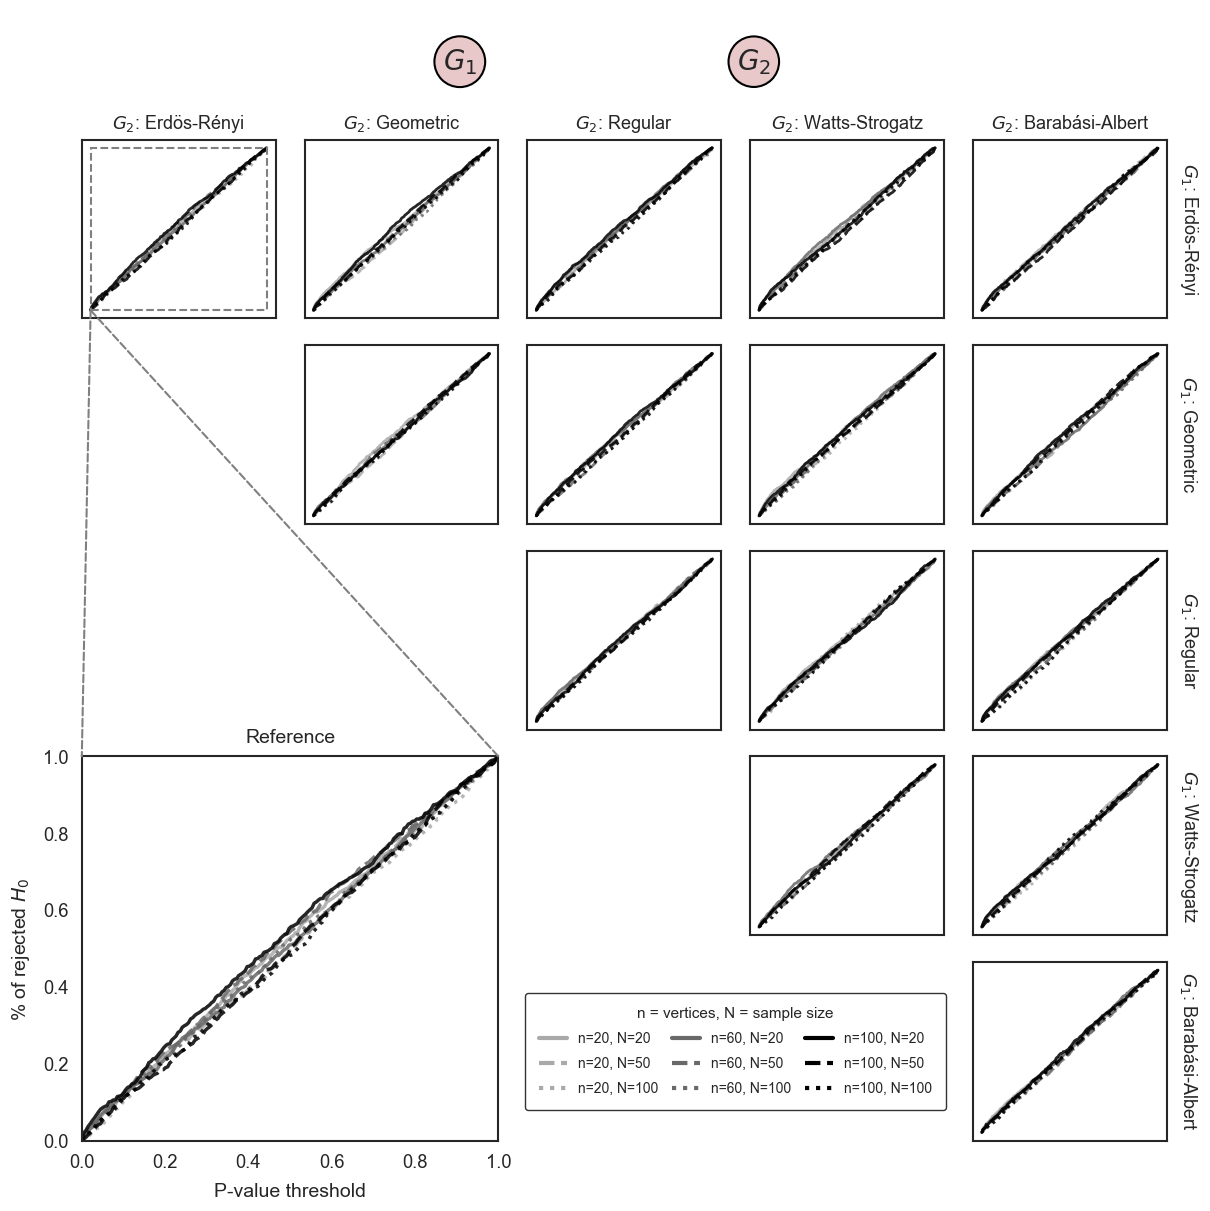

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, ConnectionPatch

# =========================================================
# Parâmetros e Configurações
# =========================================================
VERTICES = [20, 60, 100]
TAMANHOS = [20, 50, 100] # Corresponde à coluna 'R' do seu CSV
CORES_VERTICES = ['#a9a9a9', '#696969', '#000000']
LINESTYLES = ['-', '--', ':']

MODELOS_ORDEM = ['erdos_renyi', 'geometric', 'k_regular', 'watts_strogatz', 'barabasi_albert']
MODELOS_LABEL = {
    'erdos_renyi': 'Erdös-Rényi',
    'geometric': 'Geometric',
    'k_regular': 'Regular',
    'barabasi_albert': 'Barabási-Albert',
    'watts_strogatz': 'Watts-Strogatz',
}

def curva_ecdf(p_valores, x):
    """Calcula a proporção de H0 rejeitada em cada limiar de x."""
    p = pd.to_numeric(pd.Series(p_valores), errors="coerce").dropna().to_numpy()
    if len(p) == 0:
        return None
    return np.array([np.mean(p < limiar) for limiar in x])

def carregar_curvas_df(df_filtrado, mod_1, mod_2, x):
    """Filtra o DataFrame para a combinação de modelos e gera as curvas ECDF."""
    if mod_1 == mod_2:
        nome_alvo = mod_1
    else:
        nome_alvo = f"{mod_1}-{mod_2}"
        
    df_mod = df_filtrado[df_filtrado['Modelo'] == nome_alvo]
    
    # Se estiver vazio, tenta a ordem inversa por garantia
    if df_mod.empty and mod_1 != mod_2:
        df_mod = df_filtrado[df_filtrado['Modelo'] == f"{mod_2}-{mod_1}"]

    curvas = {}
    for v in VERTICES:
        for t in TAMANHOS:
            p_vals = df_mod[(df_mod['Vertices'] == v) & (df_mod['R'] == t)]['p_valor']
            if not p_vals.empty:
                curva = curva_ecdf(p_vals, x)
                if curva is not None:
                    curvas[(v, t)] = curva
                    
    return curvas

def desenhar_curvas(ax, curvas, x, linewidth=2.0):
    """Plota as linhas no eixo especificado."""
    for (v, t), curva in curvas.items():
        if v in VERTICES and t in TAMANHOS:
            cor = CORES_VERTICES[VERTICES.index(v)]
            ls = LINESTYLES[TAMANHOS.index(t)]
            ax.plot(x, curva, color=cor, linestyle=ls, linewidth=linewidth, alpha=0.85)

def plot_ecdf_matriz_csv(caminho_csv, noise="uniform", feature=r"$\lambda$", 
                         referencia=("erdos_renyi", "erdos_renyi"), 
                         zoom_xlim=(0.0, 1.0), salvar_pdf=False, path_figuras="figuras"):
    
    # 1. Carrega o CSV e aplica os filtros Globais (Ruído e Feature)
    df = pd.read_csv(caminho_csv)
    df_f = df[(df['ruido'] == noise) & (df['Feature'] == feature)].copy()
    
    if df_f.empty:
        print(f"Atenção: Nenhum dado encontrado para ruído '{noise}' e feature '{feature}'.")
        return

    sns.set_theme(style="white", font_scale=1.2)
    n = len(MODELOS_ORDEM)
    fig = plt.figure(figsize=(14, 13))
    gs = fig.add_gridspec(n, n)
    axes_matrix = {}
    curvas_cache = {}
    x = np.linspace(0, 1, 200)

    # ---------- Matriz: diagonal (modelos puros) + triângulo superior (mistos) ----------
    for i, mod_1 in enumerate(MODELOS_ORDEM):
        for j, mod_2 in enumerate(MODELOS_ORDEM):
            if j < i: # Triângulo inferior fica livre
                continue

            ax = fig.add_subplot(gs[i, j])
            axes_matrix[(i, j)] = ax

            for spine in ax.spines.values():
                spine.set_linewidth(1.5)

            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.tick_params(labelleft=False, labelbottom=False)

            # Busca as curvas no dataframe
            curvas = carregar_curvas_df(df_f, mod_1, mod_2, x)
            curvas_cache[(i, j)] = (curvas, x)

            if not curvas:
                ax.text(0.5, 0.5, "sem dados", transform=ax.transAxes,
                        ha='center', va='center', fontsize=10, color='gray')
            else:
                desenhar_curvas(ax, curvas, x)

            if i == 0:
                ax.set_title(fr"$G_2$: {MODELOS_LABEL[mod_2]}", fontsize=13, pad=8)
            if j == n - 1:
                ax.text(1.06, 0.5, fr"$G_1$: {MODELOS_LABEL[mod_1]}", rotation=270,
                        va='center', ha='left', transform=ax.transAxes, fontsize=13)

    # ---------- Painel de referência (zoom) no vão inferior esquerdo ----------
    mod_ref_1, mod_ref_2 = referencia
    i_ref, j_ref = MODELOS_ORDEM.index(mod_ref_1), MODELOS_ORDEM.index(mod_ref_2)
    if j_ref < i_ref:
        i_ref, j_ref = j_ref, i_ref

    curvas_ref, x_ref = curvas_cache.get((i_ref, j_ref), ({}, x))

    ax_ref = fig.add_subplot(gs[n - 2:n, 0:2])
    for spine in ax_ref.spines.values():
        spine.set_linewidth(1.5)

    desenhar_curvas(ax_ref, curvas_ref, x_ref, linewidth=2.5)

    # Limites do zoom: janela de pequenos p-valores
    x0, x1 = zoom_xlim
    janela = (x_ref >= x0) & (x_ref <= x1)
    
    if curvas_ref:
        y_max = max((curva[janela].max() for curva in curvas_ref.values()), default=1.0)
    else:
        y_max = 1.0
        
    y0, y1 = 0.0, min(1.0, 1.15 + 0.01)

    ax_ref.set_xlim(x0, x1)
    ax_ref.set_ylim(y0, y1)
    ax_ref.set_xlabel("P-value threshold", fontsize=14, labelpad=8)
    ax_ref.set_ylabel("% of rejected $H_0$", fontsize=14, labelpad=8)
    ax_ref.set_title("Reference", fontsize=14, pad=10)

    # ---------- Marcação da janela na célula de origem + linhas de conexão ----------
    if (i_ref, j_ref) in axes_matrix:
        ax_src = axes_matrix[(i_ref, j_ref)]
        ax_src.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                   edgecolor='gray', linestyle='--', linewidth=1.5, zorder=100))

        for xa, xb in [((x0, y0), (0, 1)), ((x0, y0), (1, 1))]:
            con = ConnectionPatch(xyA=xa, xyB=xb, coordsA="data", coordsB="axes fraction",
                                  axesA=ax_src, axesB=ax_ref, color="gray",
                                  linestyle="--", linewidth=1.5, zorder=100)
            con.set_clip_on(False)
            fig.add_artist(con)

    # ---------- Legenda única ----------
    legend_elements = [
        Line2D([0], [0], color=CORES_VERTICES[VERTICES.index(v)], lw=3,
               linestyle=LINESTYLES[TAMANHOS.index(t)], label=f"n={v}, N={t}")
        for v in VERTICES for t in TAMANHOS
    ]

    ax_legenda = fig.add_subplot(gs[n - 1, 2:4])
    ax_legenda.axis('off')
    ax_legenda.legend(
        handles=legend_elements,
        loc='center',
        ncol=3,
        frameon=True,
        edgecolor='black',
        fontsize=10,
        borderpad=1.0,
        labelspacing=0.8,
        columnspacing=1.0,
        handletextpad=0.8,
        handlelength=2.0,
        title="n = vertices, N = sample size",
        title_fontsize=11,
    )

    # =========================================================
    # Estrutura Causal (DAG) no lugar do título principal
    # =========================================================
    
    # Ajustar a margem superior para dar espaço à DAG
    fig.subplots_adjust(top=0.88, hspace=0.15, wspace=0.15)
    
    # Criar um eixo flutuante no topo central
    # Posição: [esquerda, base, largura, altura]
    ax_dag = fig.add_axes([0.35, 0.90, 0.3, 0.08])
    ax_dag.set_xlim(0, 1)
    ax_dag.set_ylim(0, 1)
    ax_dag.axis('off')  # Esconde bordas e grids

    # Estilo dos nós (caixa ao redor do texto) ajustado com a cor rosa pálido da imagem
    bbox_style = dict(boxstyle="circle,pad=0.3", fc="#E8C8C8", ec="black", lw=1.5)

    # Desenhando os nós
    ax_dag.text(0.15, 0.5, r"$G_1$", ha="center", va="center", fontsize=20, bbox=bbox_style)
    ax_dag.text(0.85, 0.5, r"$G_2$", ha="center", va="center", fontsize=20, bbox=bbox_style)

   
    # =========================================================

    if salvar_pdf:
        os.makedirs(path_figuras, exist_ok=True)
        nome_arquivo = f"ECDF_{noise}_independence.pdf"
        fig.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
        print(f"Arquivo salvo como: {os.path.join(path_figuras, nome_arquivo)}")

    plt.show()
    plt.close()

if __name__ == "__main__":
    caminho_do_csv = os.path.join("..", "dados", "resultados", "sim", "Caso_1_Independencia_real", "p_valores.csv") 
    
    plot_ecdf_matriz_csv(
        caminho_csv=caminho_do_csv,
        noise="F",       
        feature=r"$\lambda$",
        referencia=('erdos_renyi', 'erdos_renyi'),
        salvar_pdf=True,
        path_figuras=os.path.join("..", "dados", "resultados", "sim", "figuras", "rocs")
    )

Arquivo salvo como: ..\dados\resultados\sim\figuras\rocs\Cenario_2\SEM_Grafo_REAL\ECDF_gaussian_A_to_B.pdf


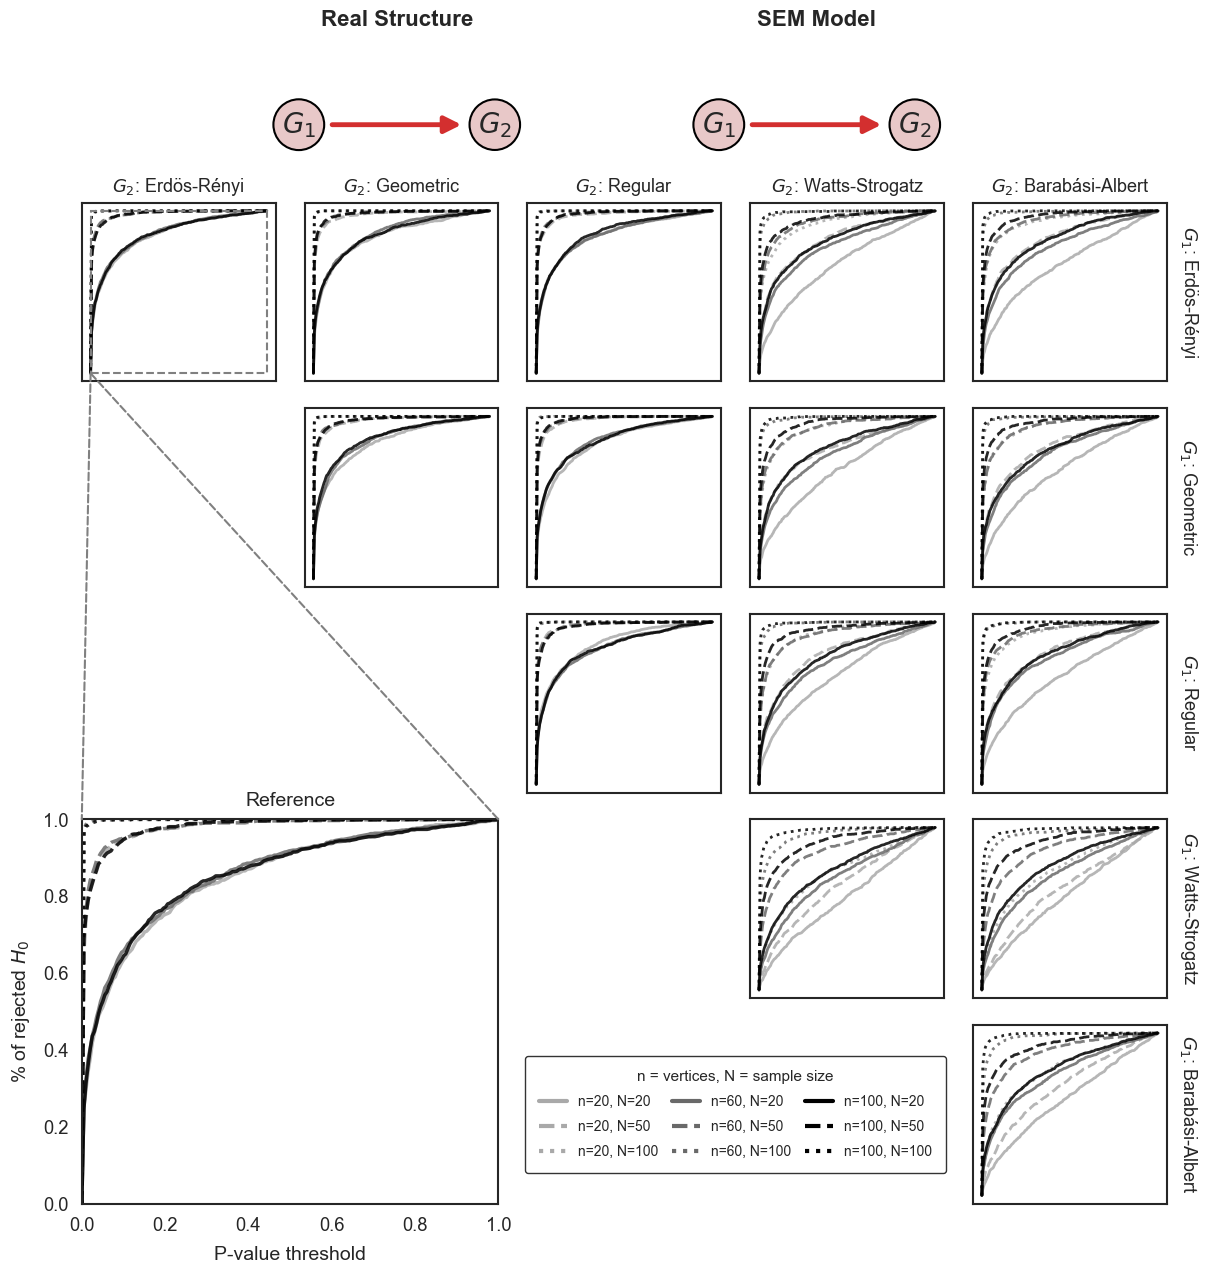

Arquivo salvo como: ..\dados\resultados\sim\figuras\rocs\Cenario_2\SEM_Grafo_REAL\ECDF_uniform_A_to_B.pdf


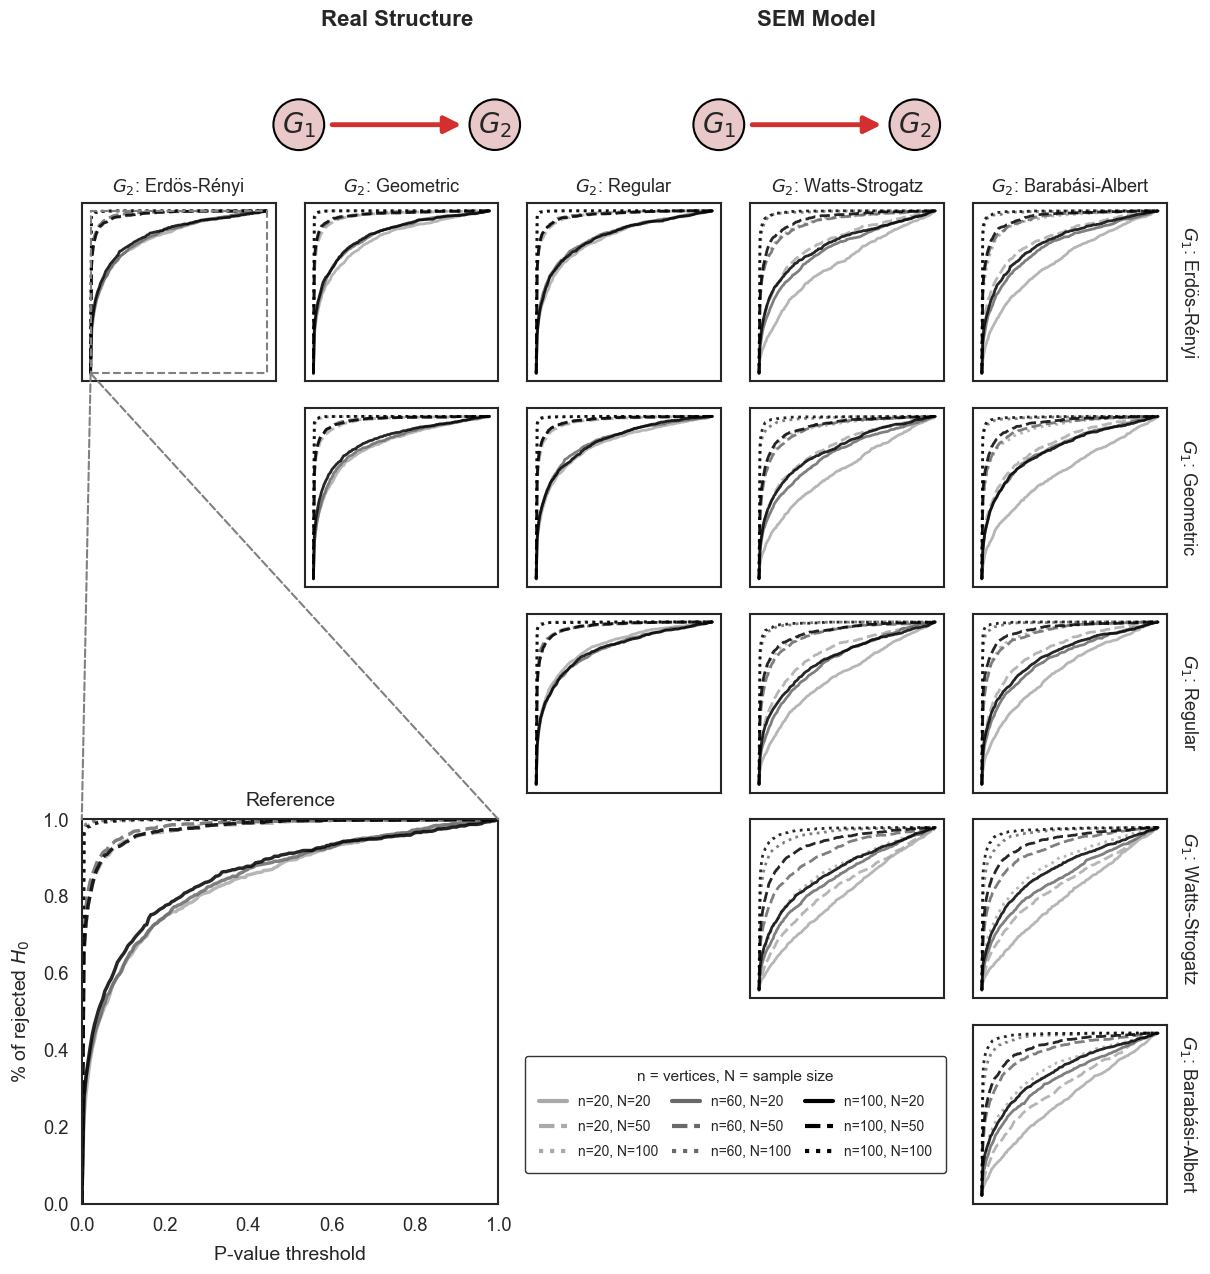

Arquivo salvo como: ..\dados\resultados\sim\figuras\rocs\Cenario_2\SEM_Grafo_REAL\ECDF_chi_square_A_to_B.pdf


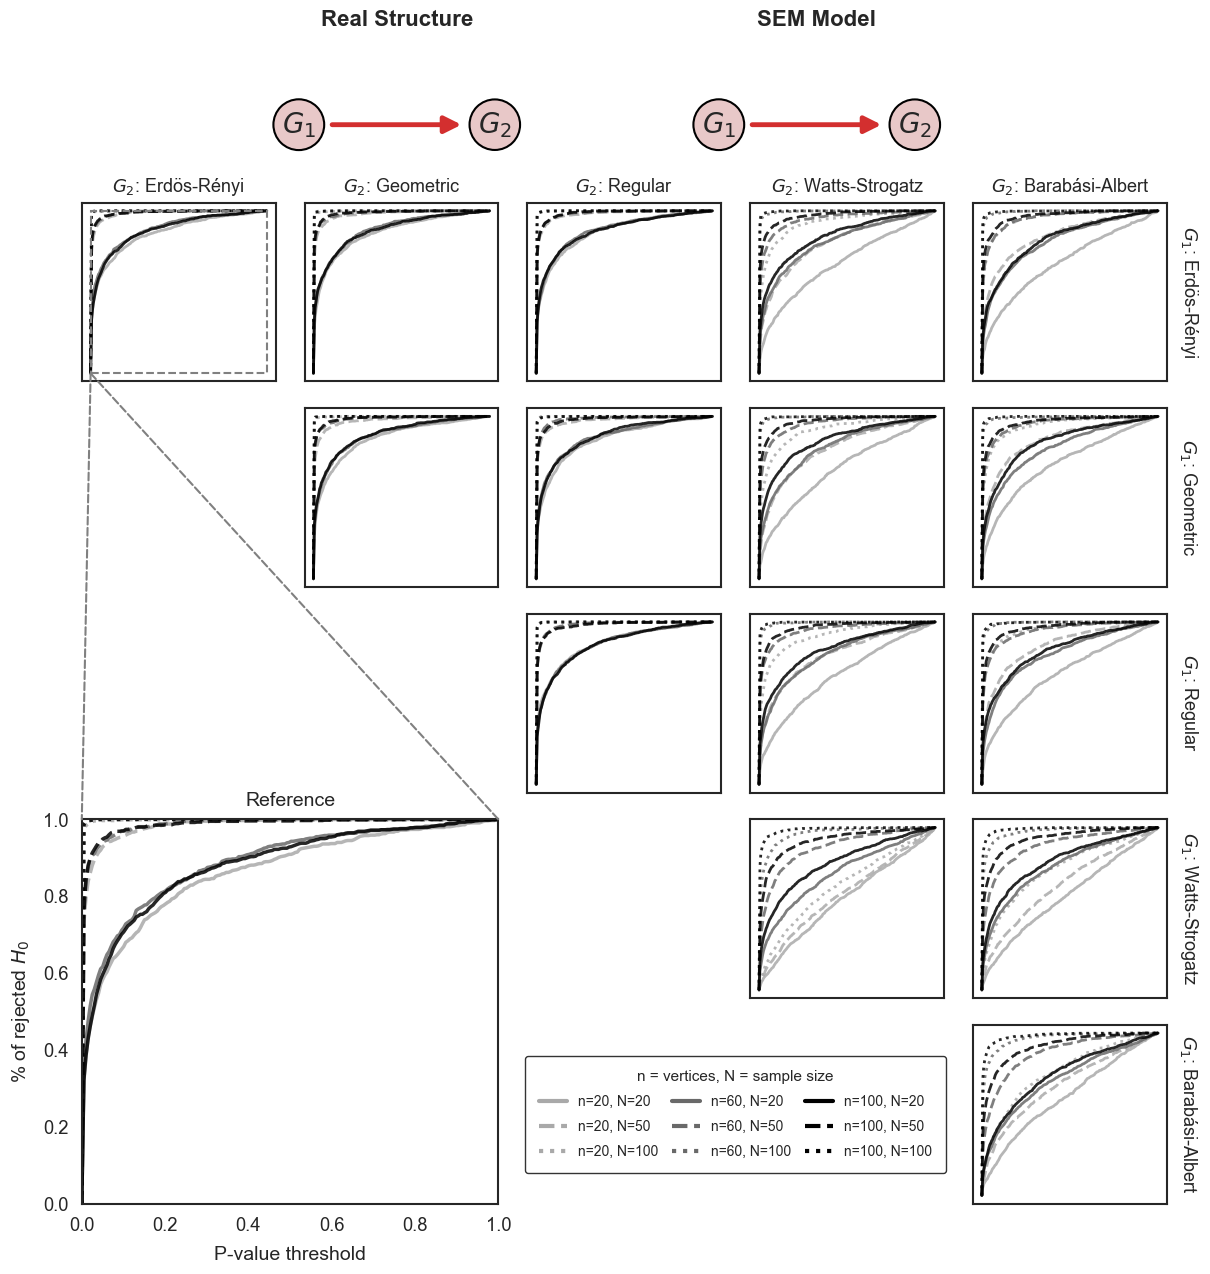

Arquivo salvo como: ..\dados\resultados\sim\figuras\rocs\Cenario_2\SEM_Grafo_REAL\ECDF_F_A_to_B.pdf


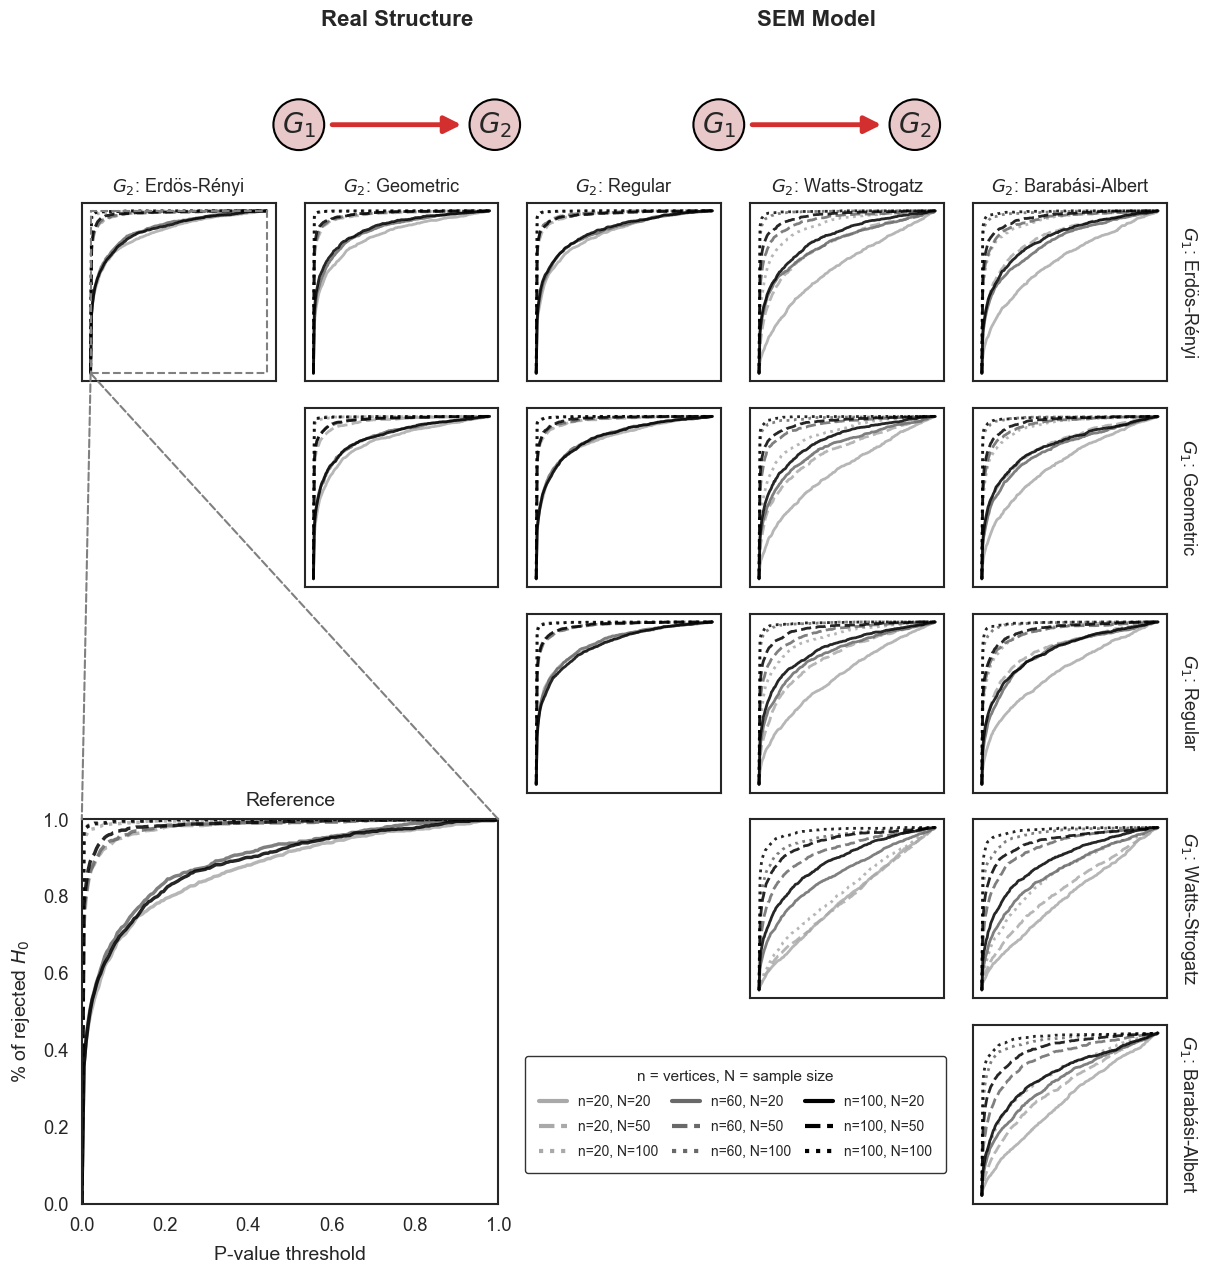

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, ConnectionPatch

# =========================================================
# Parâmetros e Configurações
# =========================================================
VERTICES = [20, 60, 100]
TAMANHOS = [20, 50, 100] # Corresponde à coluna 'R' do seu CSV
CORES_VERTICES = ['#a9a9a9', '#696969', '#000000']
LINESTYLES = ['-', '--', ':']

MODELOS_ORDEM = ['erdos_renyi', 'geometric', 'k_regular', 'watts_strogatz', 'barabasi_albert']
MODELOS_LABEL = {
    'erdos_renyi': 'Erdös-Rényi',
    'geometric': 'Geometric',
    'k_regular': 'Regular',
    'barabasi_albert': 'Barabási-Albert',
    'watts_strogatz': 'Watts-Strogatz',
}

def curva_ecdf(p_valores, x):
    """Calcula a proporção de H0 rejeitada em cada limiar de x."""
    p = pd.to_numeric(pd.Series(p_valores), errors="coerce").dropna().to_numpy()
    if len(p) == 0:
        return None
    return np.array([np.mean(p < limiar) for limiar in x])

def carregar_curvas_df(df_filtrado, mod_1, mod_2, x):
    """Filtra o DataFrame para a combinação de modelos e gera as curvas ECDF."""
    if mod_1 == mod_2:
        nome_alvo = mod_1
    else:
        nome_alvo = f"{mod_1}-{mod_2}"
        
    df_mod = df_filtrado[df_filtrado['Modelo'] == nome_alvo]
    
    # Se estiver vazio, tenta a ordem inversa por garantia
    if df_mod.empty and mod_1 != mod_2:
        df_mod = df_filtrado[df_filtrado['Modelo'] == f"{mod_2}-{mod_1}"]

    curvas = {}
    for v in VERTICES:
        for t in TAMANHOS:
            p_vals = df_mod[(df_mod['Vertices'] == v) & (df_mod['R'] == t)]['p_valor']
            if not p_vals.empty:
                curva = curva_ecdf(p_vals, x)
                if curva is not None:
                    curvas[(v, t)] = curva
                    
    return curvas

def desenhar_curvas(ax, curvas, x, linewidth=2.0):
    """Plota as linhas no eixo especificado."""
    for (v, t), curva in curvas.items():
        if v in VERTICES and t in TAMANHOS:
            cor = CORES_VERTICES[VERTICES.index(v)]
            ls = LINESTYLES[TAMANHOS.index(t)]
            ax.plot(x, curva, color=cor, linestyle=ls, linewidth=linewidth, alpha=0.85)

def desenhar_grafo(ax, arestas, nos_ordenados, aresta_destaque=None):
    """Função auxiliar para plotar a DAG dinamicamente mantendo a estética e rótulos originais."""
    
    # Mapeamento estrito para manter os labels da imagem (G1, G2...)
    mapa_labels = {'A': r"$G_1$", 'B': r"$G_2$", 'C': r"$G_3$", 'D': r"$G_4$"}
    
    # Posições ajustadas baseadas na quantidade de nós para manter a proporção
    pos = {}
    if nos_ordenados == ['A', 'B']:
        pos = {'A': (0.15, 0.5), 'B': (0.85, 0.5)}
    elif nos_ordenados == ['A', 'B', 'C']:
        pos = {'A': (0.5, 0.8), 'B': (0.15, 0.2), 'C': (0.85, 0.2)}
    elif nos_ordenados == ['A', 'B', 'C', 'D']:
        pos = {'A': (0.2, 0.8), 'B': (0.8, 0.8), 'C': (0.2, 0.2), 'D': (0.8, 0.2)}
    else:
        for i, n in enumerate(nos_ordenados):
            pos[n] = (0.15 + i * (0.7 / max(1, len(nos_ordenados) - 1)), 0.5)

    # Mantendo rigorosamente a mesma estética original
    bbox_style = dict(boxstyle="circle,pad=0.3", fc="#E8C8C8", ec="black", lw=1.5)
    
    # Desenhar os nós
    for n in nos_ordenados:
        label = mapa_labels.get(n, fr"${n}$")
        ax.text(pos[n][0], pos[n][1], label, ha="center", va="center", fontsize=20, bbox=bbox_style, zorder=3)
        
    # Desenhar as arestas
    for aresta in arestas:
        direcionado = "->" in aresta
        if direcionado:
            u, v = aresta.split("->")
        else:
            u, v = aresta.split()
        
        u = u.strip()
        v = v.strip()
        
        # Aqui ele verifica se a aresta atual é a que deve ser destacada
        eh_destaque = (aresta == aresta_destaque)
        cor = "#D32F2F" if eh_destaque else "black"
        lw = 3.5 if eh_destaque else 1.5
        z = 2 if eh_destaque else 1
        
        if direcionado:
            ax.annotate(
                "", 
                xy=pos[v], xycoords='data', 
                xytext=pos[u], textcoords='data',
                arrowprops=dict(arrowstyle="-|>", color=cor, lw=lw, mutation_scale=25, shrinkA=24, shrinkB=24), zorder=z
            )
        else:
            ax.annotate(
                "", 
                xy=pos[v], xycoords='data', 
                xytext=pos[u], textcoords='data',
                arrowprops=dict(arrowstyle="-", color=cor, lw=lw, shrinkA=24, shrinkB=24), zorder=z
            )

def plot_ecdf_matriz_csv(caminho_csv, noise="uniform", feature=r"$\lambda$", 
                         referencia=("erdos_renyi", "erdos_renyi"), 
                         zoom_xlim=(0.0, 1.0), salvar_pdf=False, path_figuras="figuras",
                         arestas_real=None, arestas_sem=None, aresta_destaque=None):
    
    # 1. Carrega o CSV e aplica os filtros Globais (Ruído e Feature)
    df = pd.read_csv(caminho_csv)
    df_f = df[(df['ruido'] == noise) & (df['Feature'] == feature)].copy()
    
    if df_f.empty:
        print(f"Atenção: Nenhum dado encontrado para ruído '{noise}' e feature '{feature}'.")
        return

    sns.set_theme(style="white", font_scale=1.2)
    n = len(MODELOS_ORDEM)
    fig = plt.figure(figsize=(14, 13))
    gs = fig.add_gridspec(n, n)
    axes_matrix = {}
    curvas_cache = {}
    x = np.linspace(0, 1, 200)

    # ---------- Matriz: diagonal (modelos puros) + triângulo superior (mistos) ----------
    for i, mod_1 in enumerate(MODELOS_ORDEM):
        for j, mod_2 in enumerate(MODELOS_ORDEM):
            if j < i: # Triângulo inferior fica livre
                continue

            ax = fig.add_subplot(gs[i, j])
            axes_matrix[(i, j)] = ax

            for spine in ax.spines.values():
                spine.set_linewidth(1.5)

            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.tick_params(labelleft=False, labelbottom=False)

            curvas = carregar_curvas_df(df_f, mod_1, mod_2, x)
            curvas_cache[(i, j)] = (curvas, x)

            if not curvas:
                ax.text(0.5, 0.5, "sem dados", transform=ax.transAxes,
                        ha='center', va='center', fontsize=10, color='gray')
            else:
                desenhar_curvas(ax, curvas, x)

            if i == 0:
                ax.set_title(fr"$G_2$: {MODELOS_LABEL[mod_2]}", fontsize=13, pad=8)
            if j == n - 1:
                ax.text(1.06, 0.5, fr"$G_1$: {MODELOS_LABEL[mod_1]}", rotation=270,
                        va='center', ha='left', transform=ax.transAxes, fontsize=13)

    # ---------- Painel de referência (zoom) no vão inferior esquerdo ----------
    mod_ref_1, mod_ref_2 = referencia
    i_ref, j_ref = MODELOS_ORDEM.index(mod_ref_1), MODELOS_ORDEM.index(mod_ref_2)
    if j_ref < i_ref:
        i_ref, j_ref = j_ref, i_ref

    curvas_ref, x_ref = curvas_cache.get((i_ref, j_ref), ({}, x))

    ax_ref = fig.add_subplot(gs[n - 2:n, 0:2])
    for spine in ax_ref.spines.values():
        spine.set_linewidth(1.5)

    desenhar_curvas(ax_ref, curvas_ref, x_ref, linewidth=2.5)

    x0, x1 = zoom_xlim
    janela = (x_ref >= x0) & (x_ref <= x1)
    
    y0, y1 = 0.0, min(1.0, 1.15 + 0.01)

    ax_ref.set_xlim(x0, x1)
    ax_ref.set_ylim(y0, y1)
    ax_ref.set_xlabel("P-value threshold", fontsize=14, labelpad=8)
    ax_ref.set_ylabel("% of rejected $H_0$", fontsize=14, labelpad=8)
    ax_ref.set_title("Reference", fontsize=14, pad=10)

    # ---------- Marcação da janela na célula de origem + linhas de conexão ----------
    if (i_ref, j_ref) in axes_matrix:
        ax_src = axes_matrix[(i_ref, j_ref)]
        ax_src.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                   edgecolor='gray', linestyle='--', linewidth=1.5, zorder=100))

        for xa, xb in [((x0, y0), (0, 1)), ((x0, y0), (1, 1))]:
            con = ConnectionPatch(xyA=xa, xyB=xb, coordsA="data", coordsB="axes fraction",
                                  axesA=ax_src, axesB=ax_ref, color="gray",
                                  linestyle="--", linewidth=1.5, zorder=100)
            con.set_clip_on(False)
            fig.add_artist(con)

    # ---------- Legenda única ----------
    legend_elements = [
        Line2D([0], [0], color=CORES_VERTICES[VERTICES.index(v)], lw=3,
               linestyle=LINESTYLES[TAMANHOS.index(t)], label=f"n={v}, N={t}")
        for v in VERTICES for t in TAMANHOS
    ]

    ax_legenda = fig.add_subplot(gs[n - 1, 2:4])
    ax_legenda.axis('off')
    ax_legenda.legend(
        handles=legend_elements,
        loc='center',
        ncol=3,
        frameon=True,
        edgecolor='black',
        fontsize=10,
        borderpad=1.0,
        labelspacing=0.8,
        columnspacing=1.0,
        handletextpad=0.8,
        handlelength=2.0,
        title="n = vertices, N = sample size",
        title_fontsize=11,
    )

    # =========================================================
    # Estruturas Causais (DAGs) dinâmicas no topo
    # =========================================================
    fig.subplots_adjust(top=0.88, hspace=0.15, wspace=0.15)
    
    # Extrair todos os nós (união de Real e SEM) para posicionamento consistente
    nos_reais = set()
    if arestas_real:
        for a in arestas_real:
            nos_reais.update([n.strip() for n in a.replace("->", " ").split()])
            
    nos_sem = set()
    if arestas_sem:
        for a in arestas_sem:
            nos_sem.update([n.strip() for n in a.replace("->", " ").split()])
            
    todos_nos = sorted(list(nos_reais | nos_sem))
    
    # Eixo 1: Estrutura Real (Passando aresta_destaque para pintar de vermelho se ela existir na real)
    ax_dag_real = fig.add_axes([0.25, 0.88, 0.2, 0.12])
    ax_dag_real.set_xlim(0, 1)
    ax_dag_real.set_ylim(0, 1)
    ax_dag_real.axis('off')
    ax_dag_real.set_title("Real Structure", fontsize=16, fontweight='bold', pad=15)
    
    if arestas_real is not None:
        desenhar_grafo(ax_dag_real, arestas_real, todos_nos, aresta_destaque=aresta_destaque)

    # Eixo 2: Modelo SEM (Com aresta testada em vermelho)
    ax_dag_sem = fig.add_axes([0.55, 0.88, 0.2, 0.12])
    ax_dag_sem.set_xlim(0, 1)
    ax_dag_sem.set_ylim(0, 1)
    ax_dag_sem.axis('off')
    ax_dag_sem.set_title("SEM Model", fontsize=16, fontweight='bold', pad=15)
    
    if arestas_sem is not None:
        desenhar_grafo(ax_dag_sem, arestas_sem, todos_nos, aresta_destaque=aresta_destaque)
    # =========================================================

    if salvar_pdf:
        os.makedirs(path_figuras, exist_ok=True)
        nome_aresta = aresta_destaque.replace("->", "_to_").replace(" ", "_") if aresta_destaque else "indep"
        nome_arquivo = f"ECDF_{noise}_{nome_aresta}.pdf"
        
        fig.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
        print(f"Arquivo salvo como: {os.path.join(path_figuras, nome_arquivo)}")

    plt.show()
    plt.close()

if __name__ == "__main__":
    modelos_sem = {
        "Cenario_1/SEM_Grafo_REAL": {"arestas": ["A->B"]},
        "Cenario_2/SEM_Grafo_REAL": {"arestas": ["A->B"]},
        "Cenario_3/SEM_Class_1_Garfo_A_REAL": {"arestas": ["A->B", "A->C"]},
        "Cenario_3/SEM_Class_1_Cadeia_B_A_C": {"arestas": ["B->A", "A->C"]},
        "Cenario_3/SEM_Class_1_Cadeia_C_A_B": {"arestas": ["C->A", "A->B"]},
        "Cenario_3/SEM_Class_2_Colisor_A": {"arestas": ["B->A", "C->A"]},
        "Cenario_3/SEM_Class_4_Colisor_B": {"arestas": ["A->B", "C->B"]},
        "Cenario_3/SEM_Class_5_Cadeia_A_C_B": {"arestas": ["A->C", "C->B"]},
        "Cenario_3/SEM_Class_6_Colisor_C": {"arestas": ["A->C", "B->C"]},
        "Cenario_3/SEM_Class_7_Triangulo_A_B-B_C-A_C": {"arestas": ["A->B", "A->C", "B->C"]},
        "Cenario_4/SEM_Grafo_REAL": {"arestas": ["A->B", "A->C", "B->C", "C->D"]}
    }

    estrutura_real = {
        "Cenario_1": {"arestas": []}, 
        "Cenario_2": {"arestas": ["A->B"]},
        "Cenario_3": {"arestas": ["A->B", "A->C"]},
        "Cenario_4": {"arestas": ["A->B", "A->C", "B->C", "C->D"]}
    }

    cenario = "Cenario_2"
    modelo_sem = "SEM_Grafo_REAL"
    noises = ["gaussian", "uniform", "chi_square", "F"]

    caso = f"{cenario}/{modelo_sem}"
    arestas_real = estrutura_real[cenario]["arestas"]
    arestas_sem = modelos_sem[caso]["arestas"]

    path_base_csv = os.path.join("..", "dados", "resultados", "sim", cenario, modelo_sem)
    path_base_figuras = os.path.join("..", "dados", "resultados", "sim", "figuras", "rocs", cenario, modelo_sem)

    for aresta_analise in arestas_sem:
        for noise in noises:
            plot_ecdf_matriz_csv(
                caminho_csv=os.path.join(path_base_csv, "p_valores.csv"),
                noise=noise,       
                feature=r"$\lambda$",
                referencia=('erdos_renyi', 'erdos_renyi'),
                salvar_pdf=True,
                path_figuras=path_base_figuras,
                arestas_real=arestas_real,
                arestas_sem=arestas_sem,
                aresta_destaque=aresta_analise
            )

### Heatmaps para as features

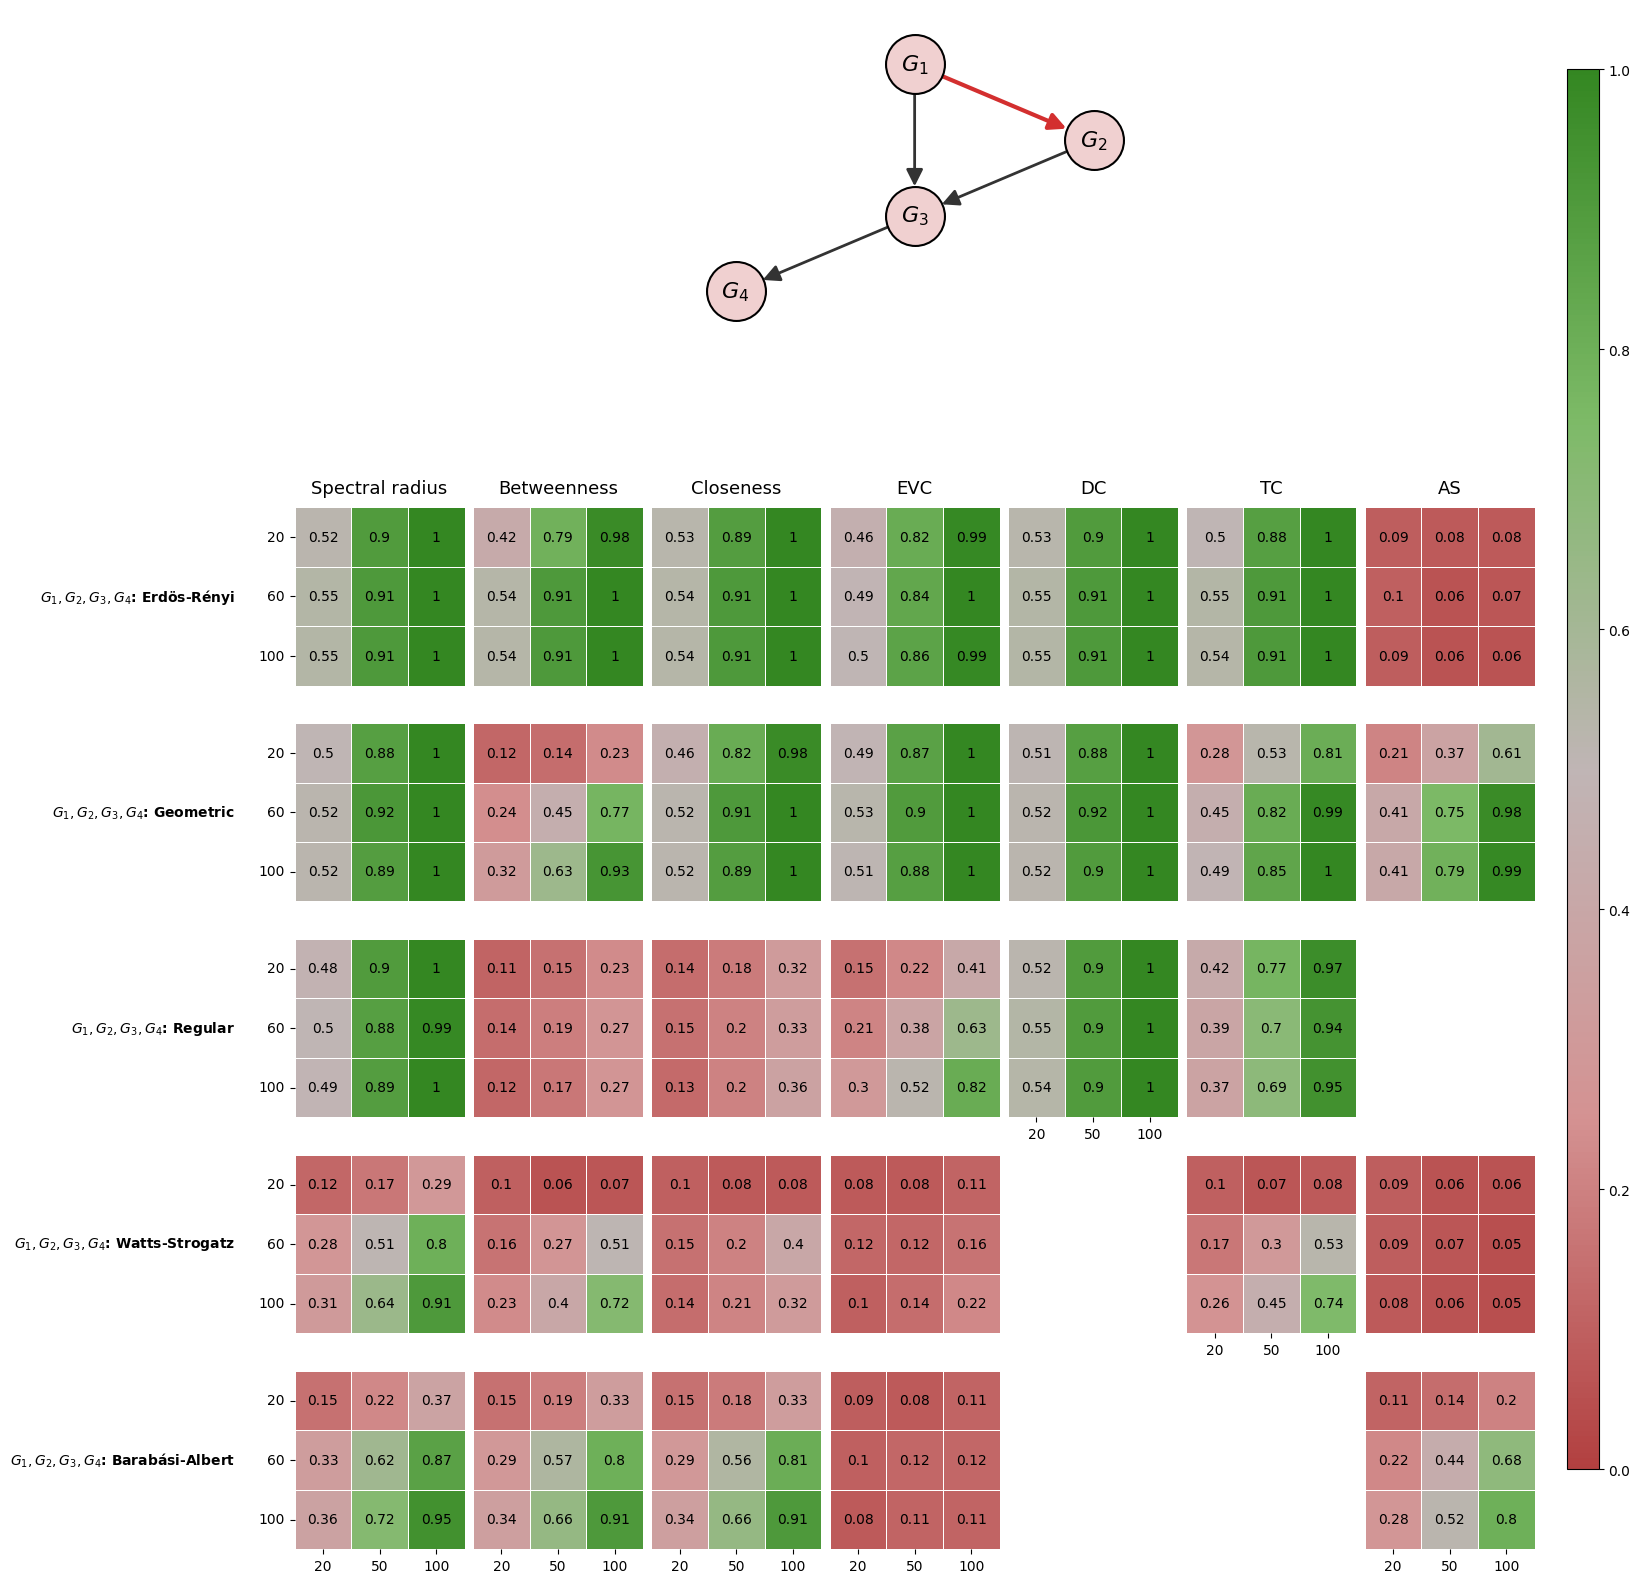

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
import os

def desenhar_estrutura(ax, estrutura, direcao_analisada):
    """
    Desenha o grafo da estrutura no eixo fornecido, destacando em vermelho 
    a aresta correspondente à direcao_analisada.
    Utiliza coordenadas fixas para garantir qualidade de publicação (estilo artigo).
    """
    G = nx.DiGraph()
    # Adiciona as arestas partindo da lista de estrutura
    for aresta in estrutura:
        if '->' in aresta:
            u, v = aresta.split('->')
            G.add_edge(u.strip(), v.strip())
        elif ' ' in aresta:
            u, v = aresta.split(' ')
            G.add_node(u.strip())
            G.add_node(v.strip())

    # --- DEFINIÇÃO MANUAL DE LAYOUT PARA QUALIDADE DE PUBLICAÇÃO ---
    nodes = sorted(list(G.nodes()))
    pos = {}
    
    if nodes == ['A', 'B']:
        # Casos 1 e 2 (Independência ou Efeito Direto)
        pos = {'A': (0, 0), 'B': (1, 0)}
        
    elif nodes == ['A', 'B', 'C']:
        # Caso 3: Verifica se é cadeia (A->B->C) ou confundidor (A->B, A->C)
        arestas_tuplas = list(G.edges())
        if ('A', 'C') in arestas_tuplas or ('C', 'A') in arestas_tuplas:
            # Confundidor (A em cima, B e C embaixo)
            pos = {'A': (1, 1), 'B': (0, 0), 'C': (2, 0)}
        else:
            # Cadeia linear
            pos = {'A': (0, 0), 'B': (1, 0), 'C': (2, 0)}
            
    elif nodes == ['A', 'B', 'C', 'D']:
        # Caso 4 (Cascata baseada na sua imagem D)
        # Z1(A), Z2(B), Z3(C), Z4(D)
        # Ajuste: D movido para a esquerda de C para não ficar espremido
        pos = {'A': (0, 2), 'B': (1, 1), 'C': (0, 0), 'D': (-1, -1)}
        
    else:
        # Fallback de segurança
        pos = nx.spring_layout(G)

    # Mapeamento de 'A', 'B', 'C', 'D' para G_1, G_2, G_3, G_4
    mapeamento_labels = {}
    for node in G.nodes():
        idx = ord(node.upper()) - ord('A') + 1 
        mapeamento_labels[node] = f"$G_{idx}$"
        
    # Configurações estéticas do nó
    node_size = 1800
    node_color = '#f0d0d0' # Retornando à cor original
    edge_color_default = '#333333'
    edge_color_highlight = '#D32F2F' # Vermelho mais elegante (Crimson/Material Red)

    # Desenhar os nós
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color, 
                           edgecolors='black', node_size=node_size, linewidths=1.5)
    
    # Desenhar os rótulos
    nx.draw_networkx_labels(G, pos, labels=mapeamento_labels, ax=ax, 
                            font_size=16, font_weight='bold')
    
    # Prepara aresta analisada
    if '->' in direcao_analisada:
        u_analisada, v_analisada = [x.strip() for x in direcao_analisada.split('->')]
    else:
        u_analisada, v_analisada = None, None
    
    # Desenhar as arestas
    for u, v in G.edges():
        is_analyzed = (u == u_analisada and v == v_analisada)
        color = edge_color_highlight if is_analyzed else edge_color_default
        
        # A aresta B->C é SEMPRE tracejada ("--")
        #estilo_linha = "--" if (u == "B" and v == "C") else "-"
        width = 3.0 if is_analyzed else 2.0
        
        # Curvatura suave se a aresta pula nós (ex: A->C em uma cadeia horizontal)
        rad = 0.0
        if pos[u][1] == pos[v][1] and abs(pos[u][0] - pos[v][0]) > 1:
            rad = -0.3
            
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], ax=ax, edge_color=color, 
            width=width, arrowsize=25, arrowstyle='-|>', # Setas preenchidas
            connectionstyle=f'arc3,rad={rad}', style="-", 
            node_size=node_size, min_source_margin=0, min_target_margin=0
        )
        
    ax.margins(0.2) 
    ax.axis('off')


def plot_power_heatmaps(caminho_csv, noise='uniform', direcao='A->B', 
                        salvar_pdf=False, path_figuras="figuras", caso=None, 
                        estrutura_completa=None):
    # Tratamento de erro simples para o caso do arquivo não existir durante o teste
    if not os.path.exists(caminho_csv):
        print(f"Atenção: Arquivo '{caminho_csv}' não encontrado. Gráfico da DAG será exibido vazio para visualização.")
        df = pd.DataFrame(columns=['ruido', 'Direcao', 'Modelo', 'Feature', 'Vértices', 'R', 'Poder_5%'])
    else:
        df = pd.read_csv(caminho_csv)
    
    df_f = df[(df['ruido'] == noise) & (df['Direcao'] == direcao)].copy()
    
    if df_f.empty:
        print(f"Atenção: Nenhum dado encontrado para ruído '{noise}' e direção '{direcao}'.")
        # Vamos renderizar a DAG mesmo sem dados do Heatmap para você testar a estética
        fig, ax_dag = plt.subplots(figsize=(6, 4))
        if estrutura_completa:
            desenhar_estrutura(ax_dag, estrutura_completa, direcao)
        plt.show()
        return

    nomes_base = {
        'erdos_renyi': 'Erdös-Rényi',
        'geometric': 'Geometric',
        'k_regular': 'Regular',
        'watts_strogatz': 'Watts-Strogatz',
        'barabasi_albert': 'Barabási-Albert'
    }

    # Formatando para incluir G_1 e G_2
    # Formatando para incluir G_1 e G_2
    def format_model_name(m, estrutura):
        if len(estrutura) == 1:
            if '-' in m:
                p1, p2 = m.split('-')
                # Removido o 'r' do rf"..." para que o \n funcione como quebra de linha
                return f"$G_1$: {nomes_base.get(p1, p1)}\n$G_2$: {nomes_base.get(p2, p2)}"
            else:
                return f"$G_1, G_2$: {nomes_base.get(m, m)}"
        elif len(estrutura) >= 2:
            # Novo: Gerar dinamicamente G_1, G_2, ..., G_n baseado no número de nós únicos
            nos = set()
            for aresta in estrutura:
                if '->' in aresta:
                    u, v = aresta.split('->')
                    nos.add(u.strip())
                    nos.add(v.strip())
                elif ' ' in aresta:
                    u, v = aresta.split(' ')
                    nos.add(u.strip())
                    nos.add(v.strip())
            
            num_nos = len(nos)
            lista_g = ", ".join([f"G_{i}" for i in range(1, num_nos + 1)])
            
            # Removido o 'r' aqui também
            return f"${lista_g}$: {nomes_base.get(m, m)}"


    modelos_unicos = df_f['Modelo'].unique()
    
    # Ordenação específica: ER -> Geometric -> Regular -> WS -> BA
    ordem_base = {
        'erdos_renyi': 0,
        'geometric': 1,
        'k_regular': 2,
        'watts_strogatz': 3,
        'barabasi_albert': 4
    }

    def sort_models(m):
        if '-' in m:
            p1, p2 = m.split('-')
            return (1, ordem_base.get(p1, 99), ordem_base.get(p2, 99))
        else:
            return (0, ordem_base.get(m, 99), -1)
            
    models = sorted(modelos_unicos, key=sort_models)
    model_labels = [format_model_name(m, estrutura_completa) for m in models]
    
    features = [r'$\lambda$', 'BC', 'CC', 'EVC', 'DC', 'TC', 'AS']
    feature_labels = ['Spectral radius', 'Betweenness', 'Closeness', 'EVC', 'DC', 'TC', 'AS']
    
    # --- PALETA DE CORES PERSONALIZADA DA IMAGEM ---
    cores_paleta = ["#b24040", "#d49292", "#c0b5b5", "#7dba67", "#348722"]
    cmap_custom = LinearSegmentedColormap.from_list("custom_palette", cores_paleta)
    
    fig_size = (16, 20)
    if caso and "Caso_3" in caso:
        fig_size = (15, 17)

    fig = plt.figure(figsize=fig_size)
    
    num_colunas = len(features)
    
    # Ajuste de layout: adicionada uma linha vazia (ratio=0.5) para afastar a DAG
    if estrutura_completa:
        num_linhas = len(models) + 2
        height_ratios = [1.87, 0.5] + [1] * len(models) 
        offset_row = 2
    else:
        num_linhas = len(models)
        height_ratios = [1] * len(models)
        offset_row = 0
        
    gs = fig.add_gridspec(nrows=num_linhas, ncols=num_colunas, height_ratios=height_ratios, hspace=0.2, wspace=0.05)
    
    if estrutura_completa:
        # Centraliza o DAG usando as 3 colunas do meio
        meio_inicio = max(0, (num_colunas // 2) - 1)
        meio_fim = min(num_colunas, (num_colunas // 2) + 2)
        ax_dag = fig.add_subplot(gs[0, meio_inicio:meio_fim])
        desenhar_estrutura(ax_dag, estrutura_completa, direcao)
        # gs[1, :] é deixada vazia para distanciar a DAG dos plots
    
    # Mapear última linha ativa de cada coluna para os ticks do eixo X
    last_active_in_col = {}
    for j, feat in enumerate(features):
        for i in reversed(range(len(models))):
            mod = models[i]
            sub_df = df_f[(df_f['Modelo'] == mod) & (df_f['Feature'] == feat)]
            if not sub_df.empty:
                pivot_k = sub_df.pivot_table(index='Vértices', columns='R', values='Poder_5%')
                if not (pivot_k.isna().all().all() or (pivot_k == 0.0).all().all()):
                    last_active_in_col[j] = i
                    break
    
    # Desenhar os Heatmaps
    for i, mod in enumerate(models):
        for j, feat in enumerate(features):
            ax = fig.add_subplot(gs[i + offset_row, j])
            
            sub_df = df_f[(df_f['Modelo'] == mod) & (df_f['Feature'] == feat)]
            
            if sub_df.empty:
                ax.axis('off')
                continue
                
            pivot_k = sub_df.pivot_table(index='Vértices', columns='R', values='Poder_5%')
            
            if pivot_k.isna().all().all() or (pivot_k == 0.0).all().all():
                ax.axis('off')
            else:
                pivot_k = pivot_k.round(2)
                
                sns.heatmap(pivot_k, ax=ax, cmap=cmap_custom, vmin=0, vmax=1, 
                            annot=True, fmt="g", cbar=False, 
                            annot_kws={"size": 10, "color": "black"}, 
                            linewidths=0.5)
                
                ax.set_ylabel("")
                ax.set_xlabel("")
                ax.tick_params(axis='both', which='major', labelsize=10)
                ax.tick_params(axis='y', rotation=0)
                
                if j != 0:
                    ax.set_yticks([])
                if i != last_active_in_col.get(j, len(models)-1):
                    ax.set_xticks([])
                
            # Colocar o nome da feature no topo
            if i == 0:
                ax.set_title(feature_labels[j], fontsize=13, pad=10)
            
            # Anotar o nome do modelo (G1, G2) na primeira coluna
            if j == 0:
                ax.annotate(model_labels[i], xy=(-0.35, 0.5), xycoords='axes fraction',
                            fontsize=10, fontweight='bold', rotation=0,
                            ha='right', va='center')
    
    # Ajusta margem direita para caber a barra de cores geral do heatmap
    fig.subplots_adjust(right=0.9) 
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [esquerda, base, largura, altura]
    sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=plt.Normalize(vmin=0, vmax=1))
    fig.colorbar(sm, cax=cbar_ax)

    if salvar_pdf:
        os.makedirs(path_figuras, exist_ok=True)
        dir_nome_arquivo = direcao.replace("->", "_to_")
        nome_arquivo = f"Heatmap_5_{caso.replace("/", "_")}_{noise}_{dir_nome_arquivo}.pdf"
        
        caminho_salvar = os.path.join(path_figuras, nome_arquivo)
        plt.savefig(caminho_salvar, bbox_inches='tight', dpi=300)
        print(f"Salvo em: {caminho_salvar}")
        
    plt.show()
    plt.close()



modelos_sem = {
    "Cenario_1/SEM_Grafo_REAL": {"arestas": ["A B"]},
    "Cenario_2/SEM_Grafo_REAL": {"arestas": ["A->B"]},
    "Cenario_3/SEM_Grafo_REAL": {"arestas": ["A->B", "A->C"]},
    "Cenario_3/SEM_A_B-B_C-A_C": {"arestas": ["A->B", "A->C", "B->C"]},
    "Cenario_4/SEM_Grafo_REAL": {"arestas": ["A->B", "A->C", "B->C", "C->D"]}
}


estrutura_real = {
    "Cenario_1": {"arestas": ["A B"]},
    "Cenario_2": {"arestas": ["A->B"]},
    "Cenario_3": {"arestas": ["A->B", "A->C"]},
    "Cenario_4": {"arestas": ["A->B", "A->C", "B->C", "C->D"]}
}



cenario = "Cenario_1"
modelo_sem = "SEM_Grafo_REAL"
aresta_analise = "A->B"


caso = f"{cenario}/{modelo_sem}"
if __name__ == "__main__":
    plot_power_heatmaps(
        caminho_csv=os.path.join("..", "dados", "resultados", "sim", caso, "resultados_power.csv"), 
        noise="gaussian", 
        direcao=aresta_analise,
        caso=caso,
        salvar_pdf=True,
        estrutura_completa=modelos_sem[caso]["arestas"],
        path_figuras=os.path.join("..", "dados", "resultados", "sim", "figuras", f"Heatmap_{cenario}")
    )

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\gaussian\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_gaussian_B_to_A.pdf


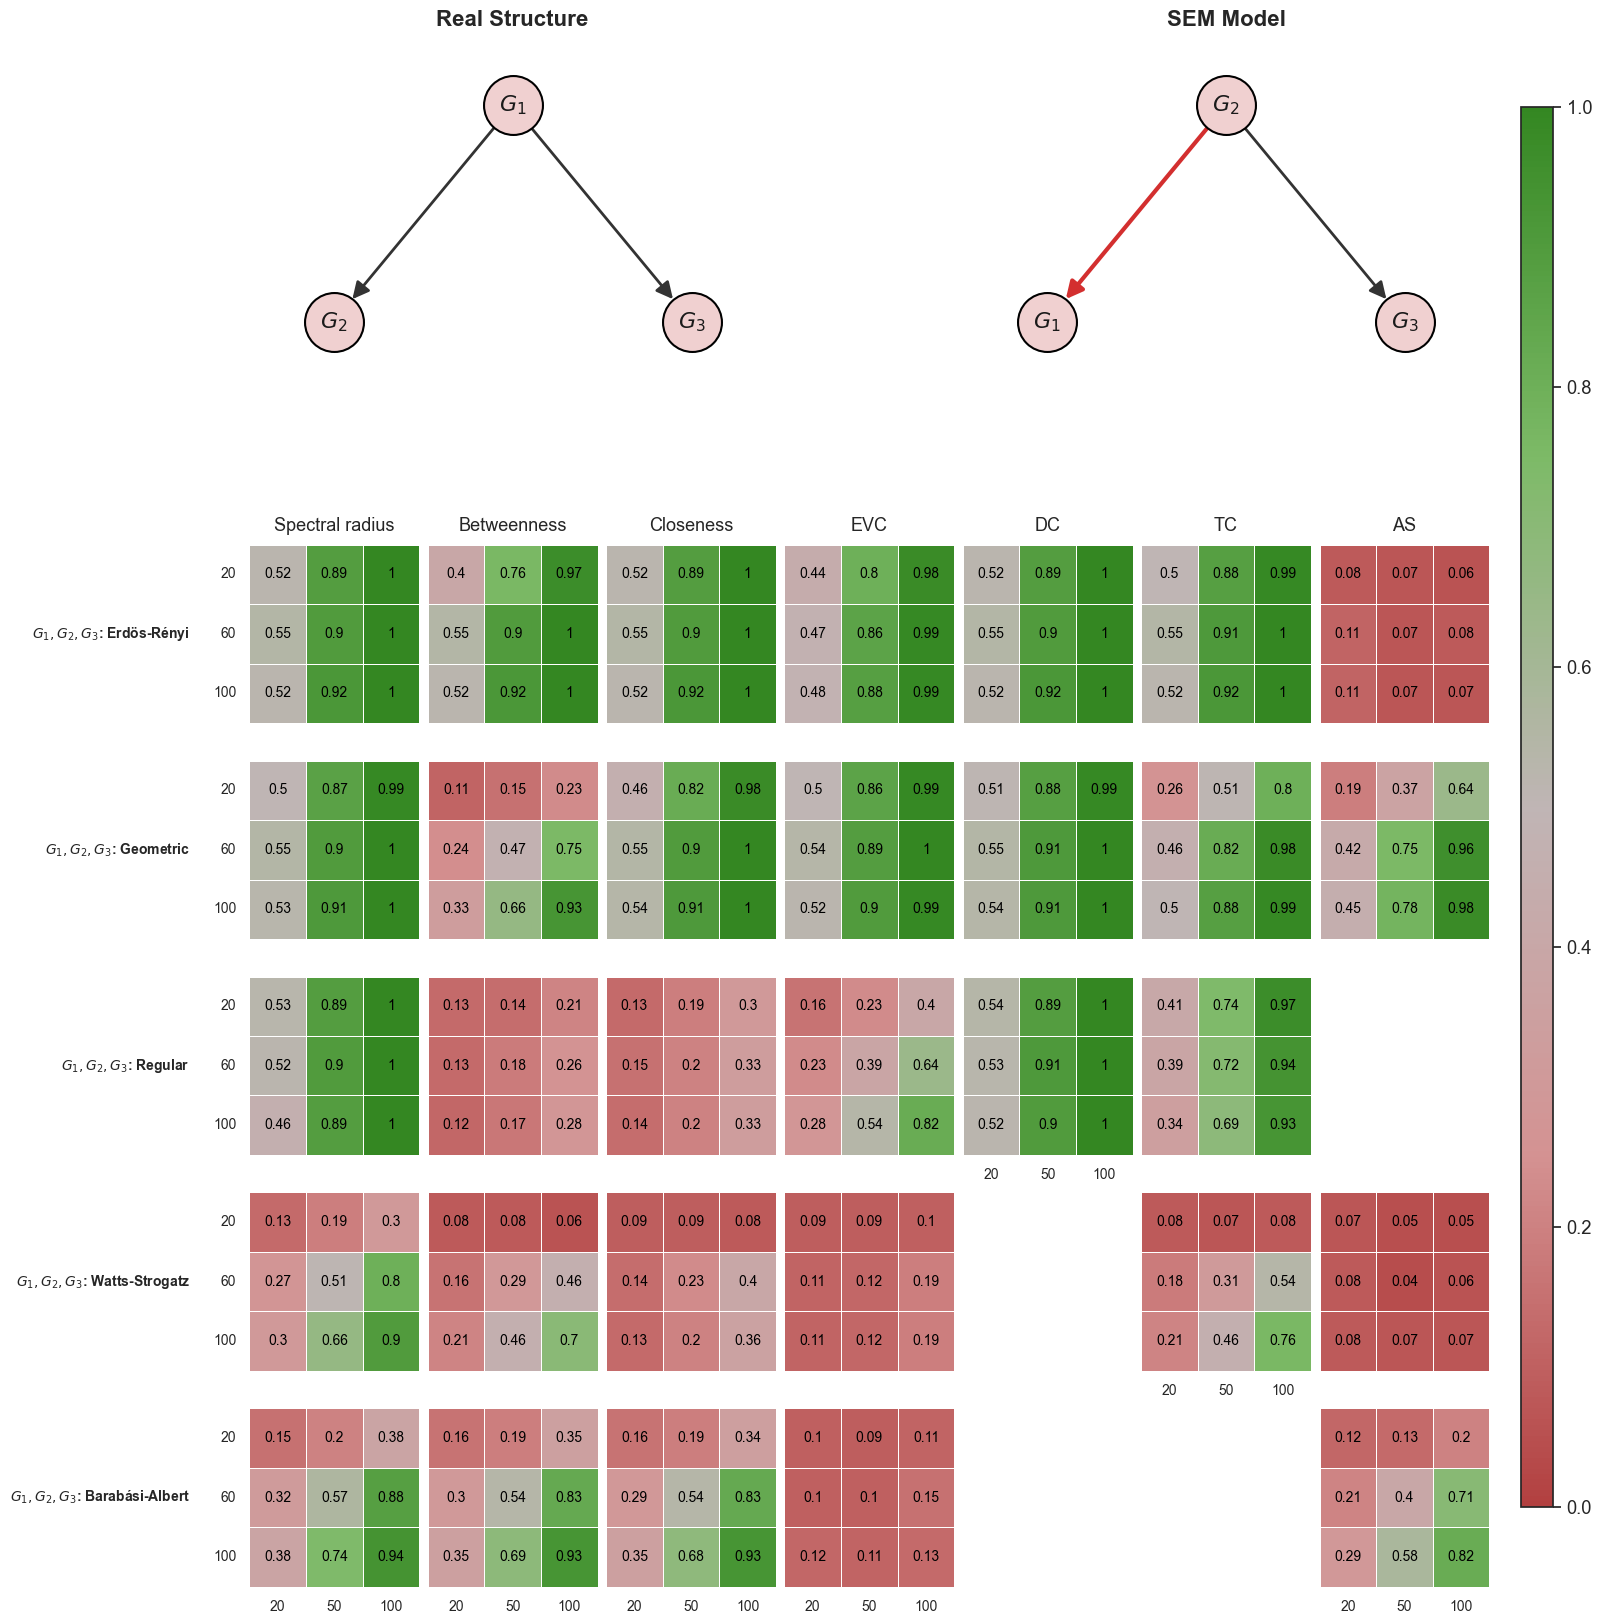

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\uniform\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_uniform_B_to_A.pdf


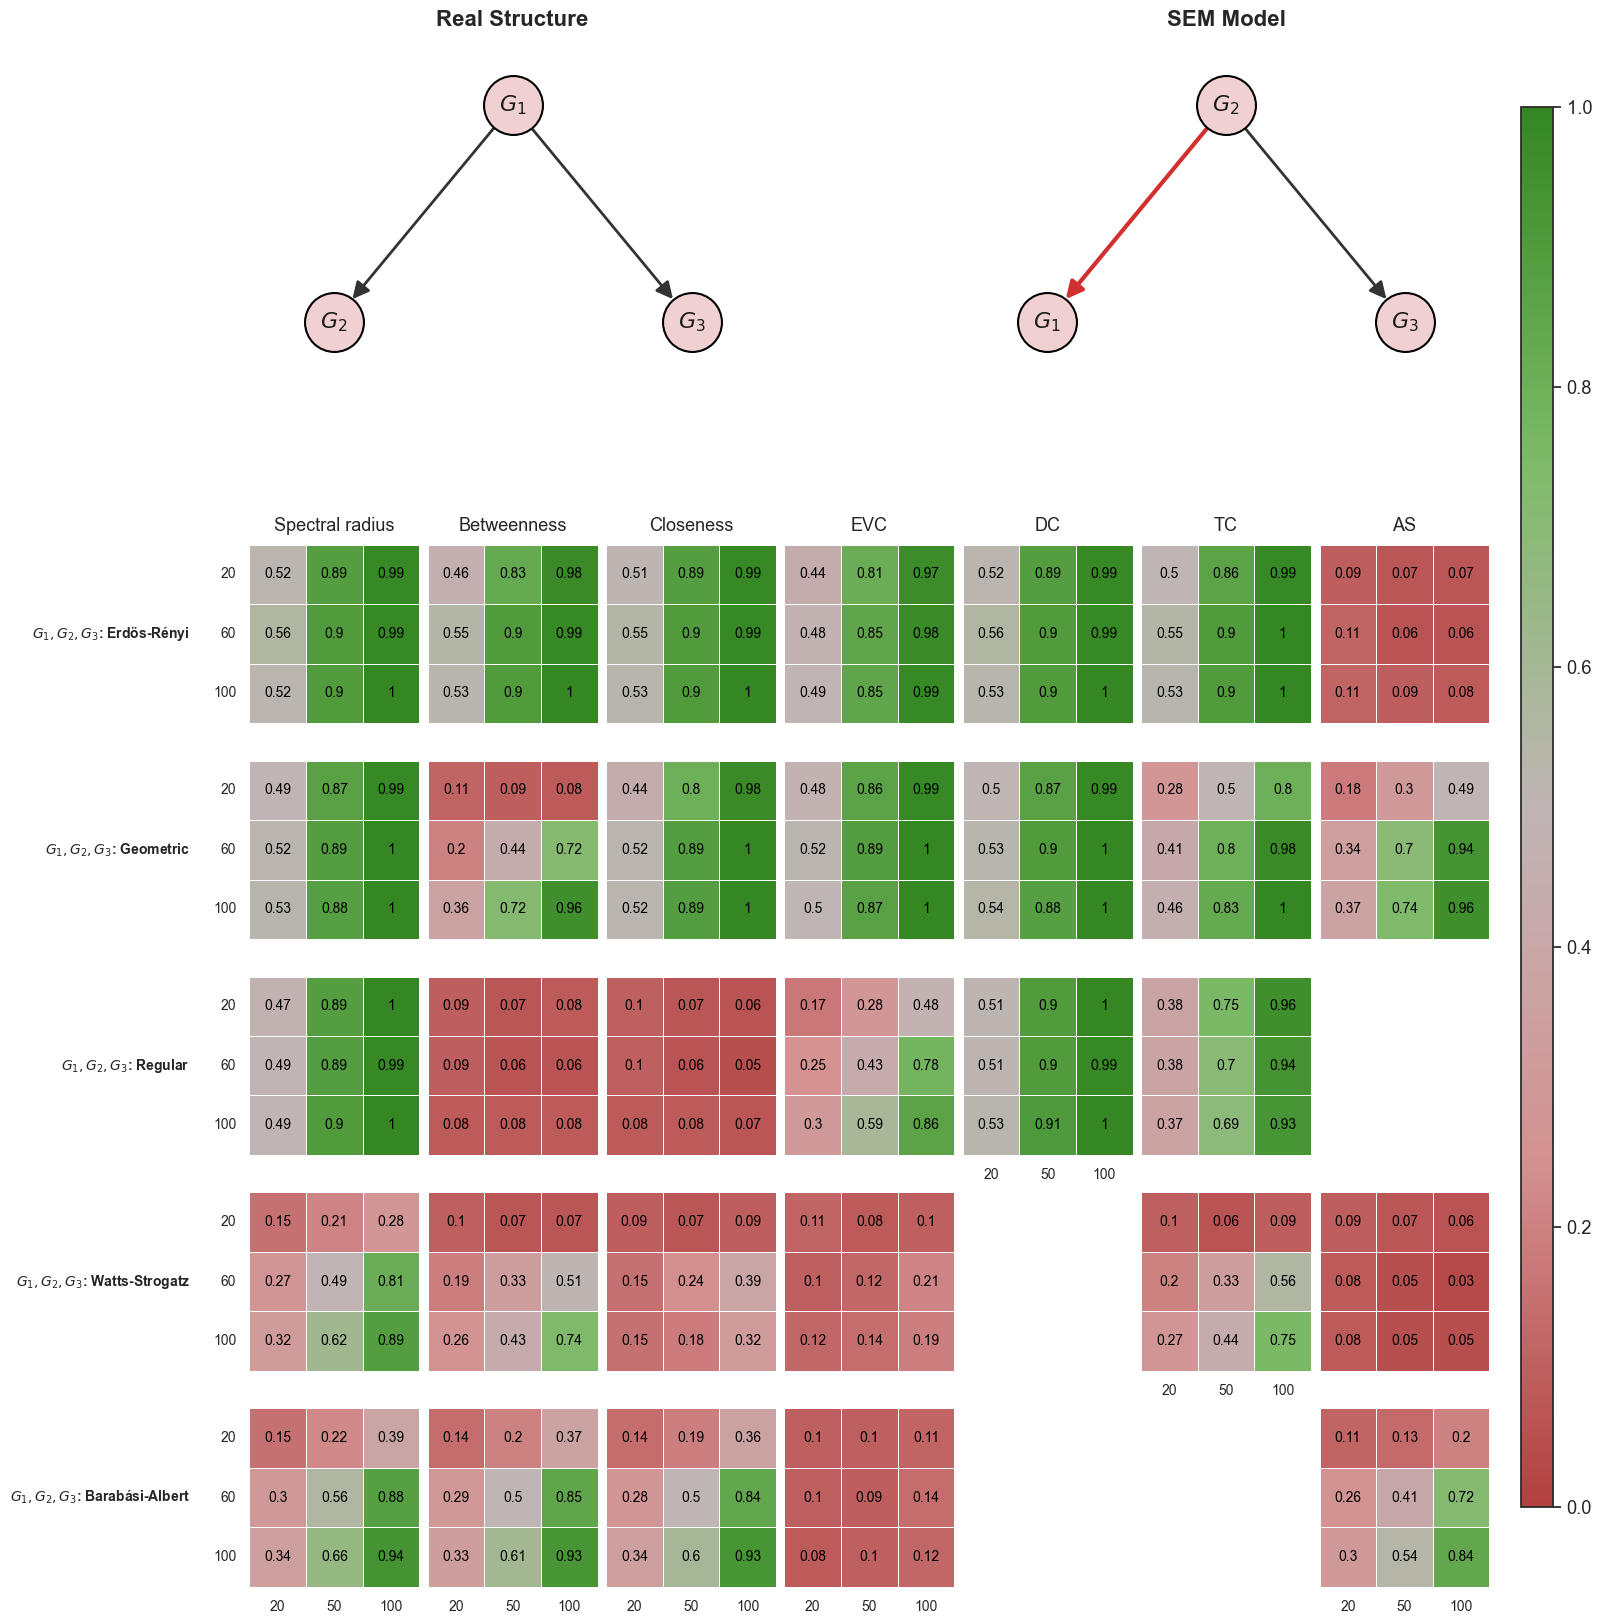

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\chi_square\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_chi_square_B_to_A.pdf


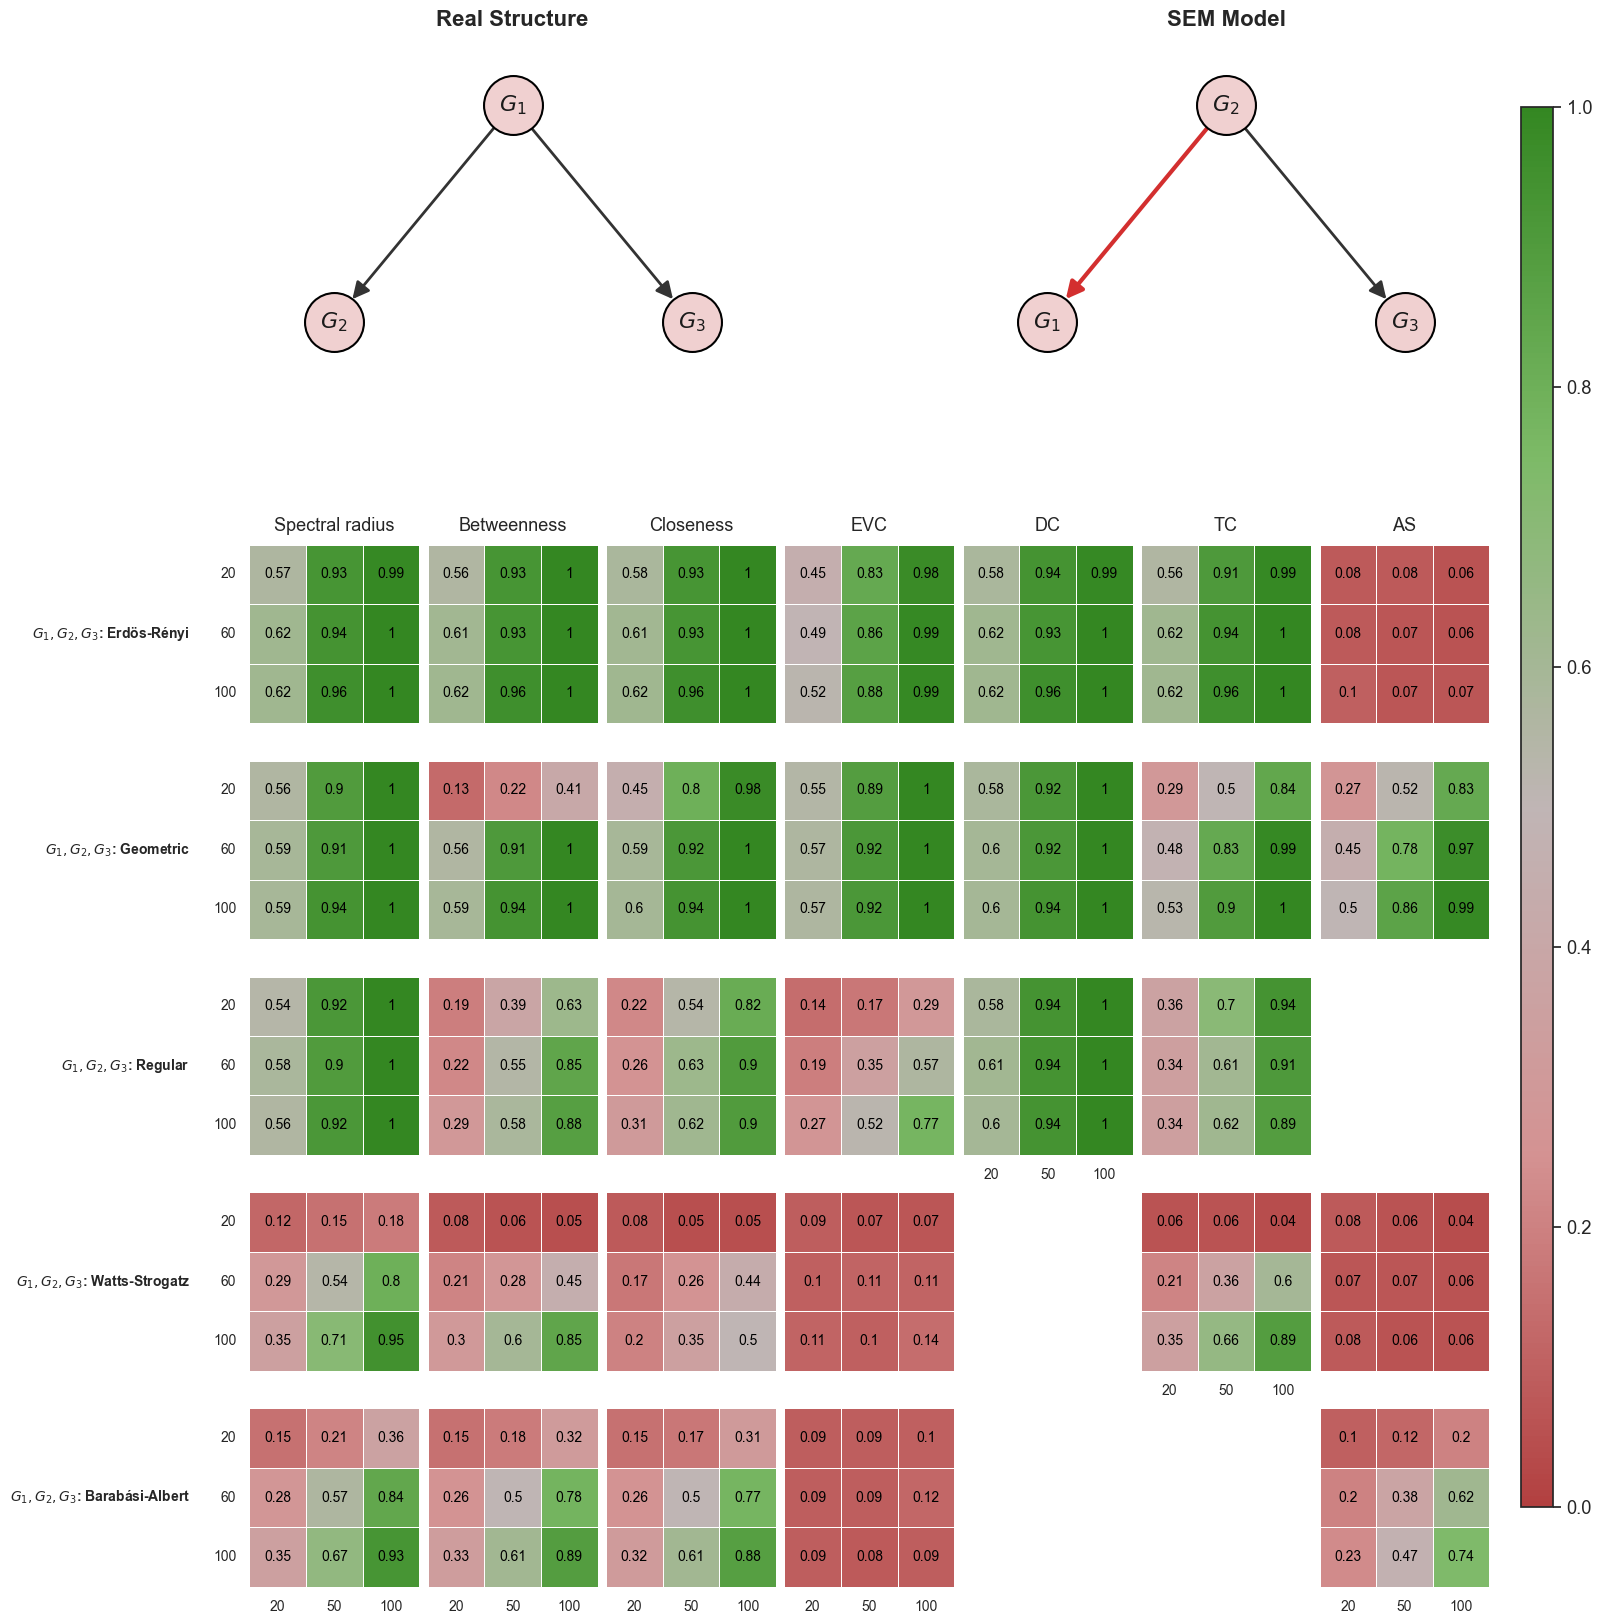

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\F\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_F_B_to_A.pdf


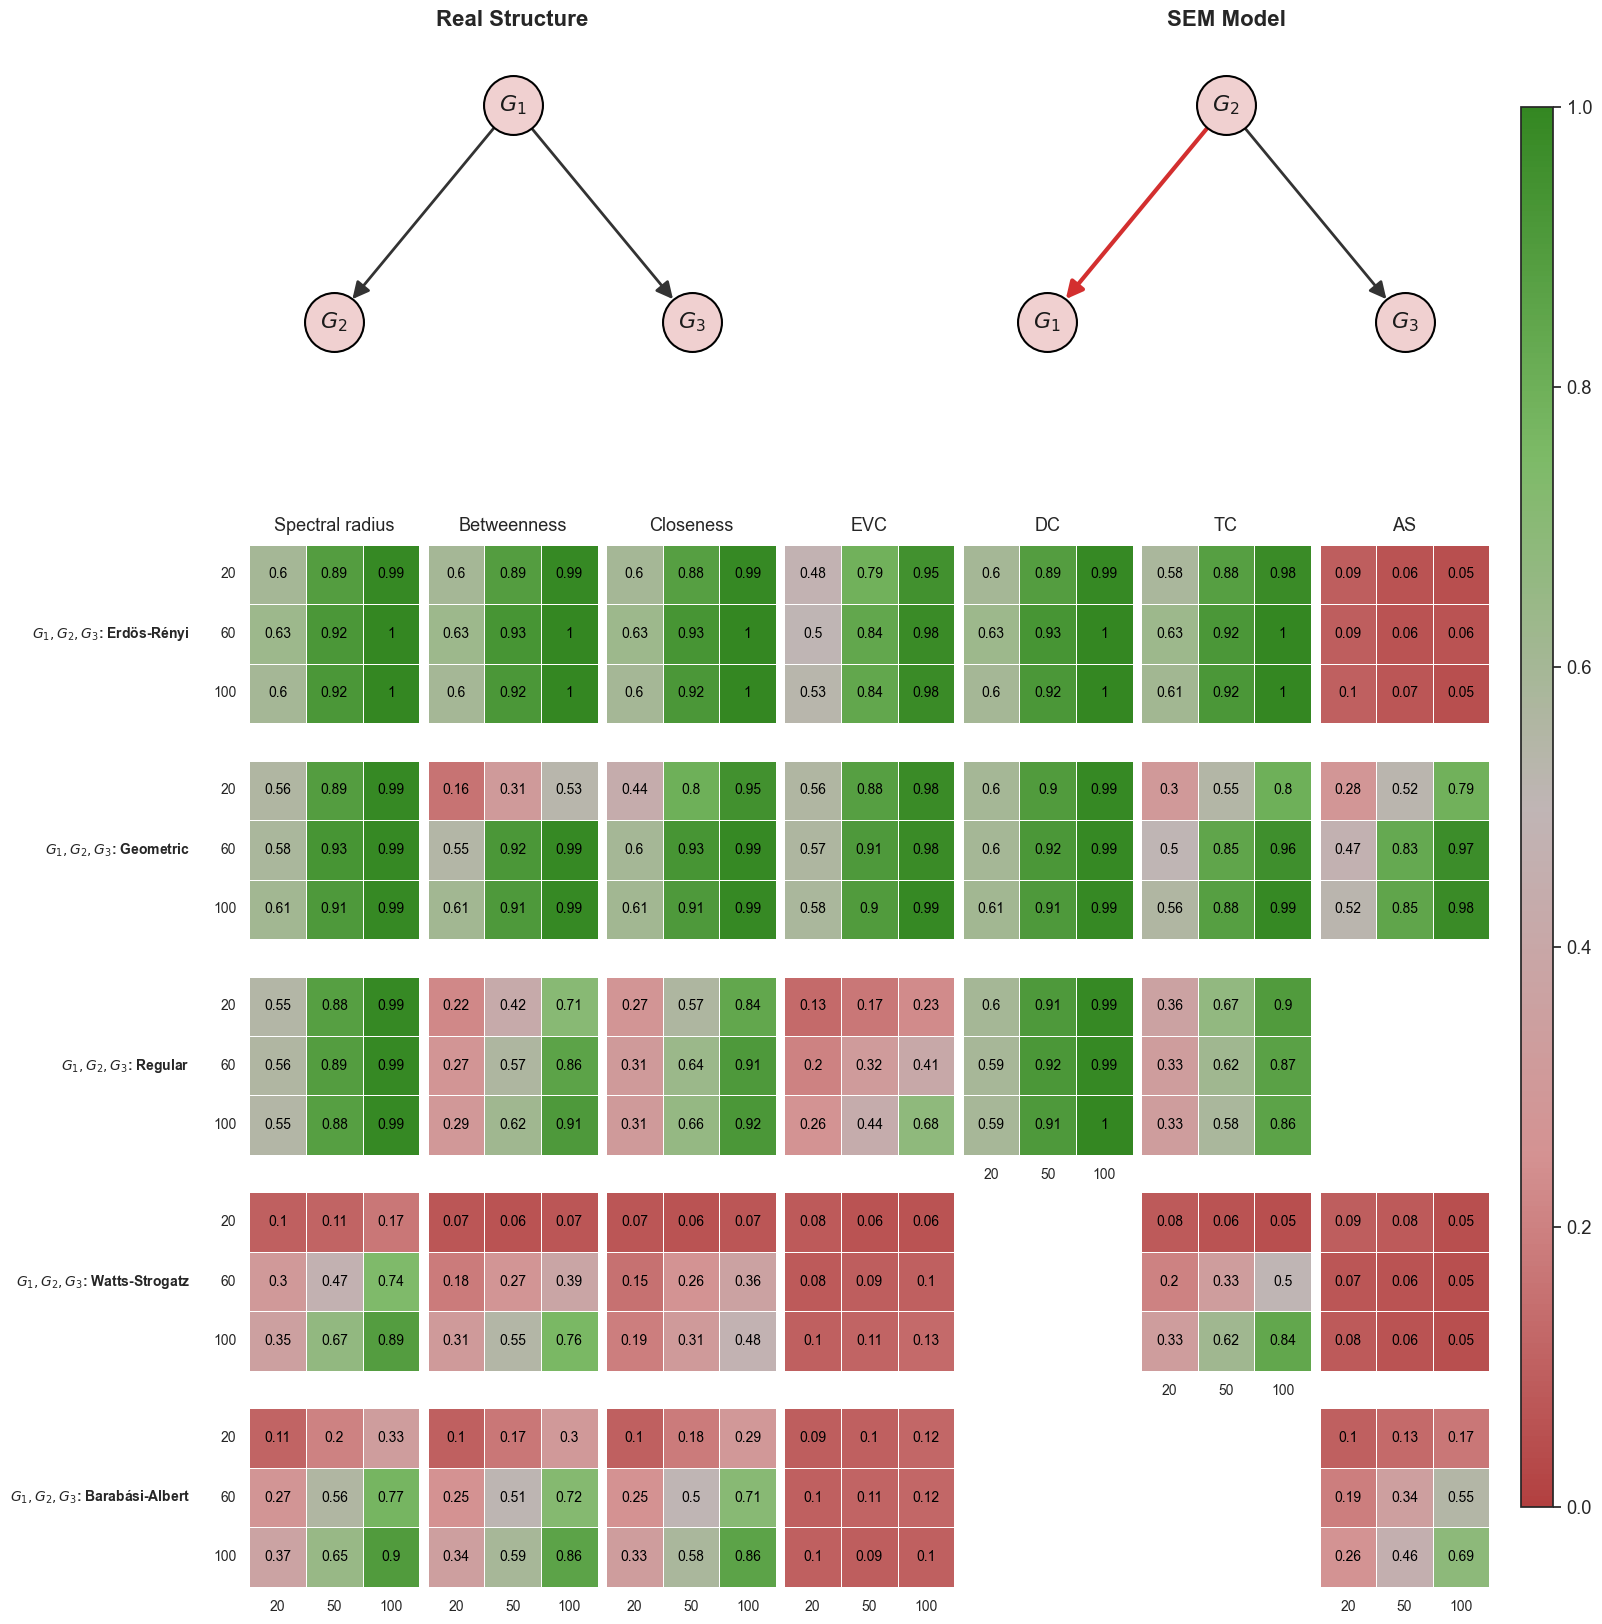

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\gaussian\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_gaussian_B_to_C.pdf


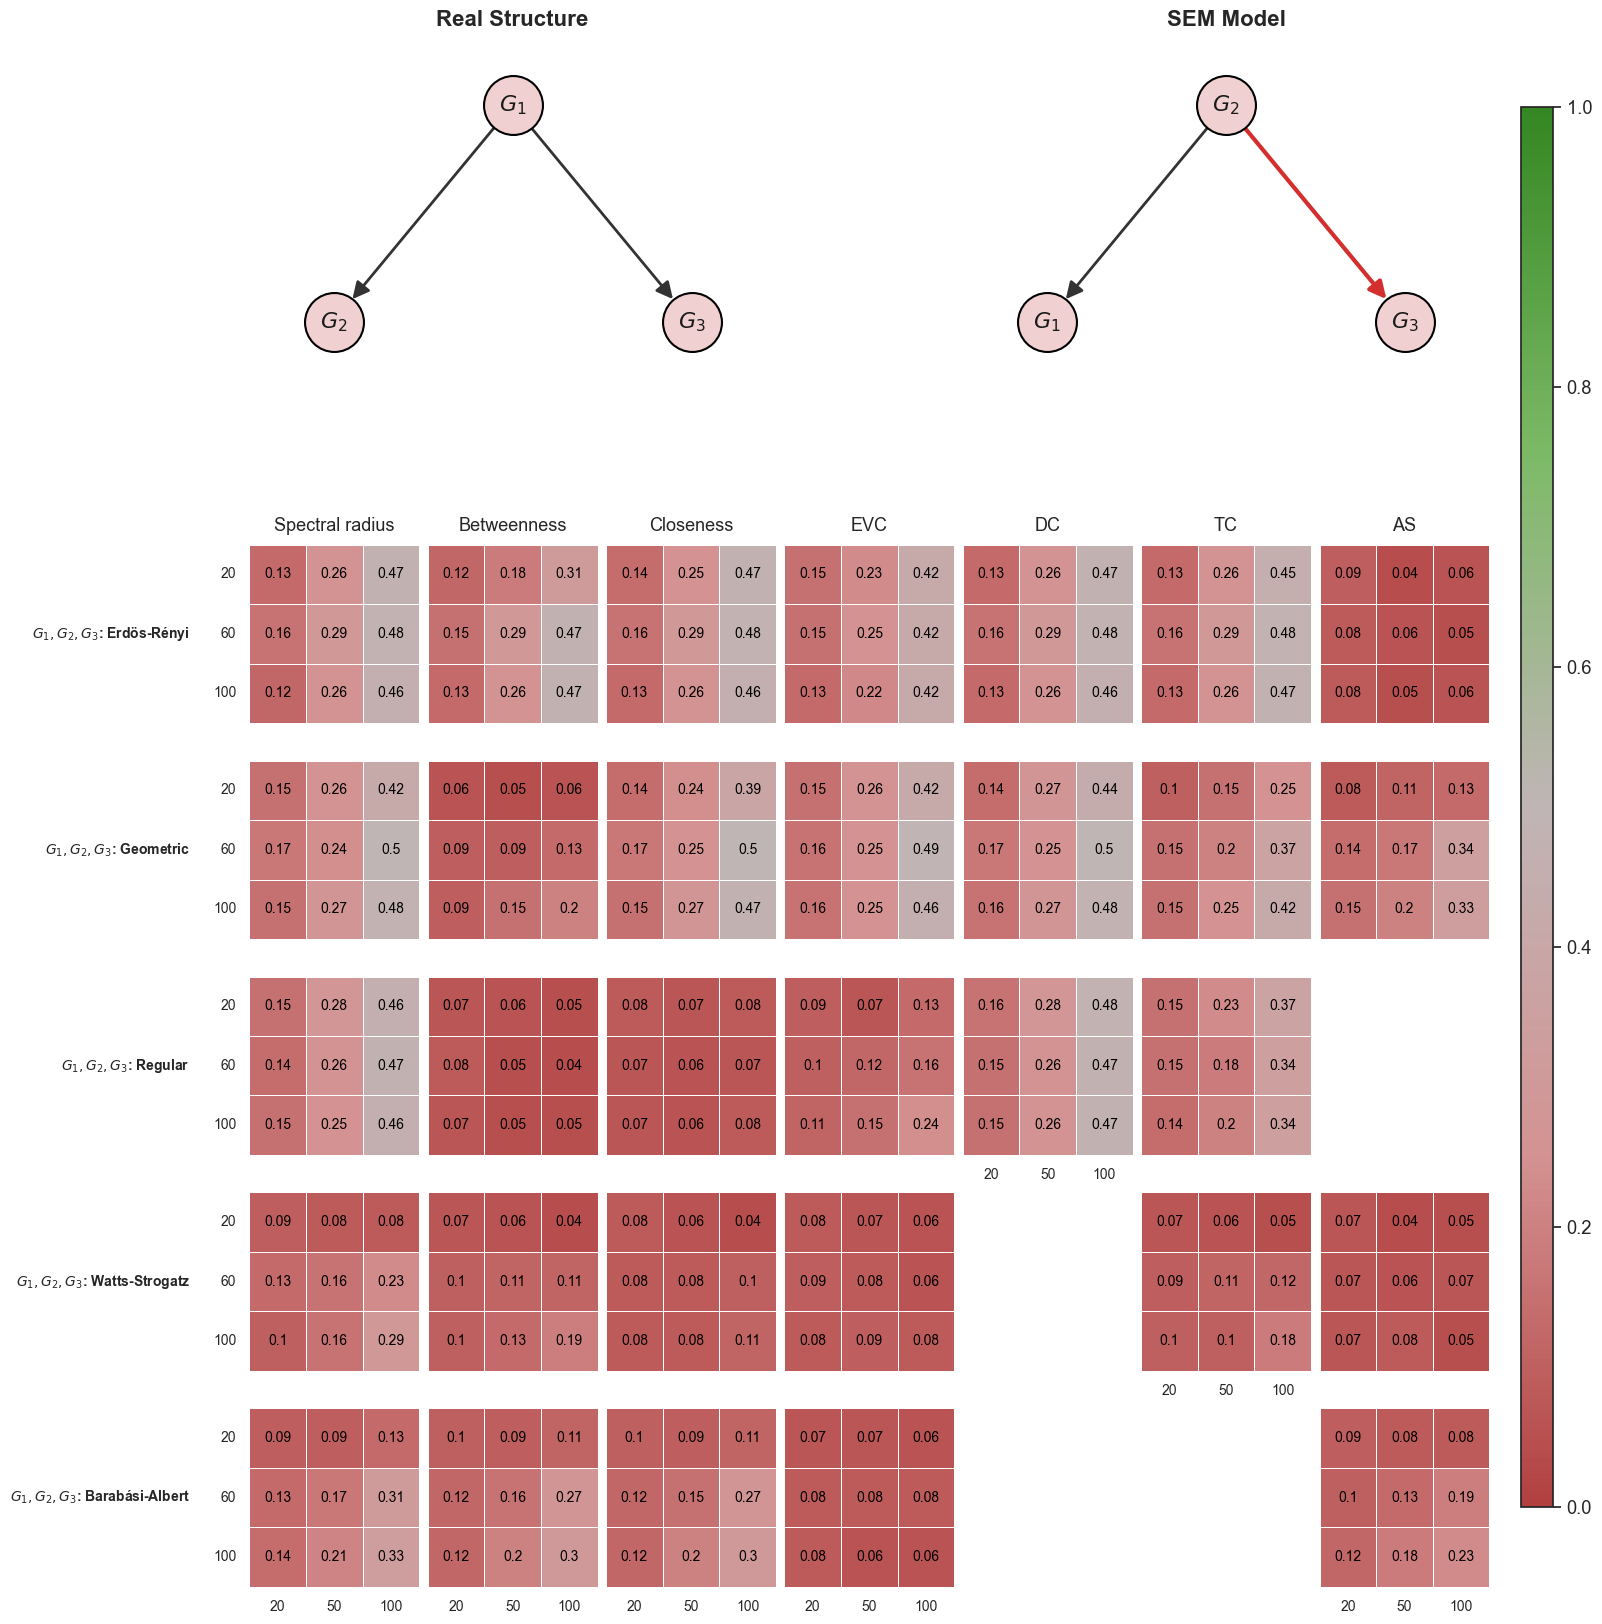

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\uniform\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_uniform_B_to_C.pdf


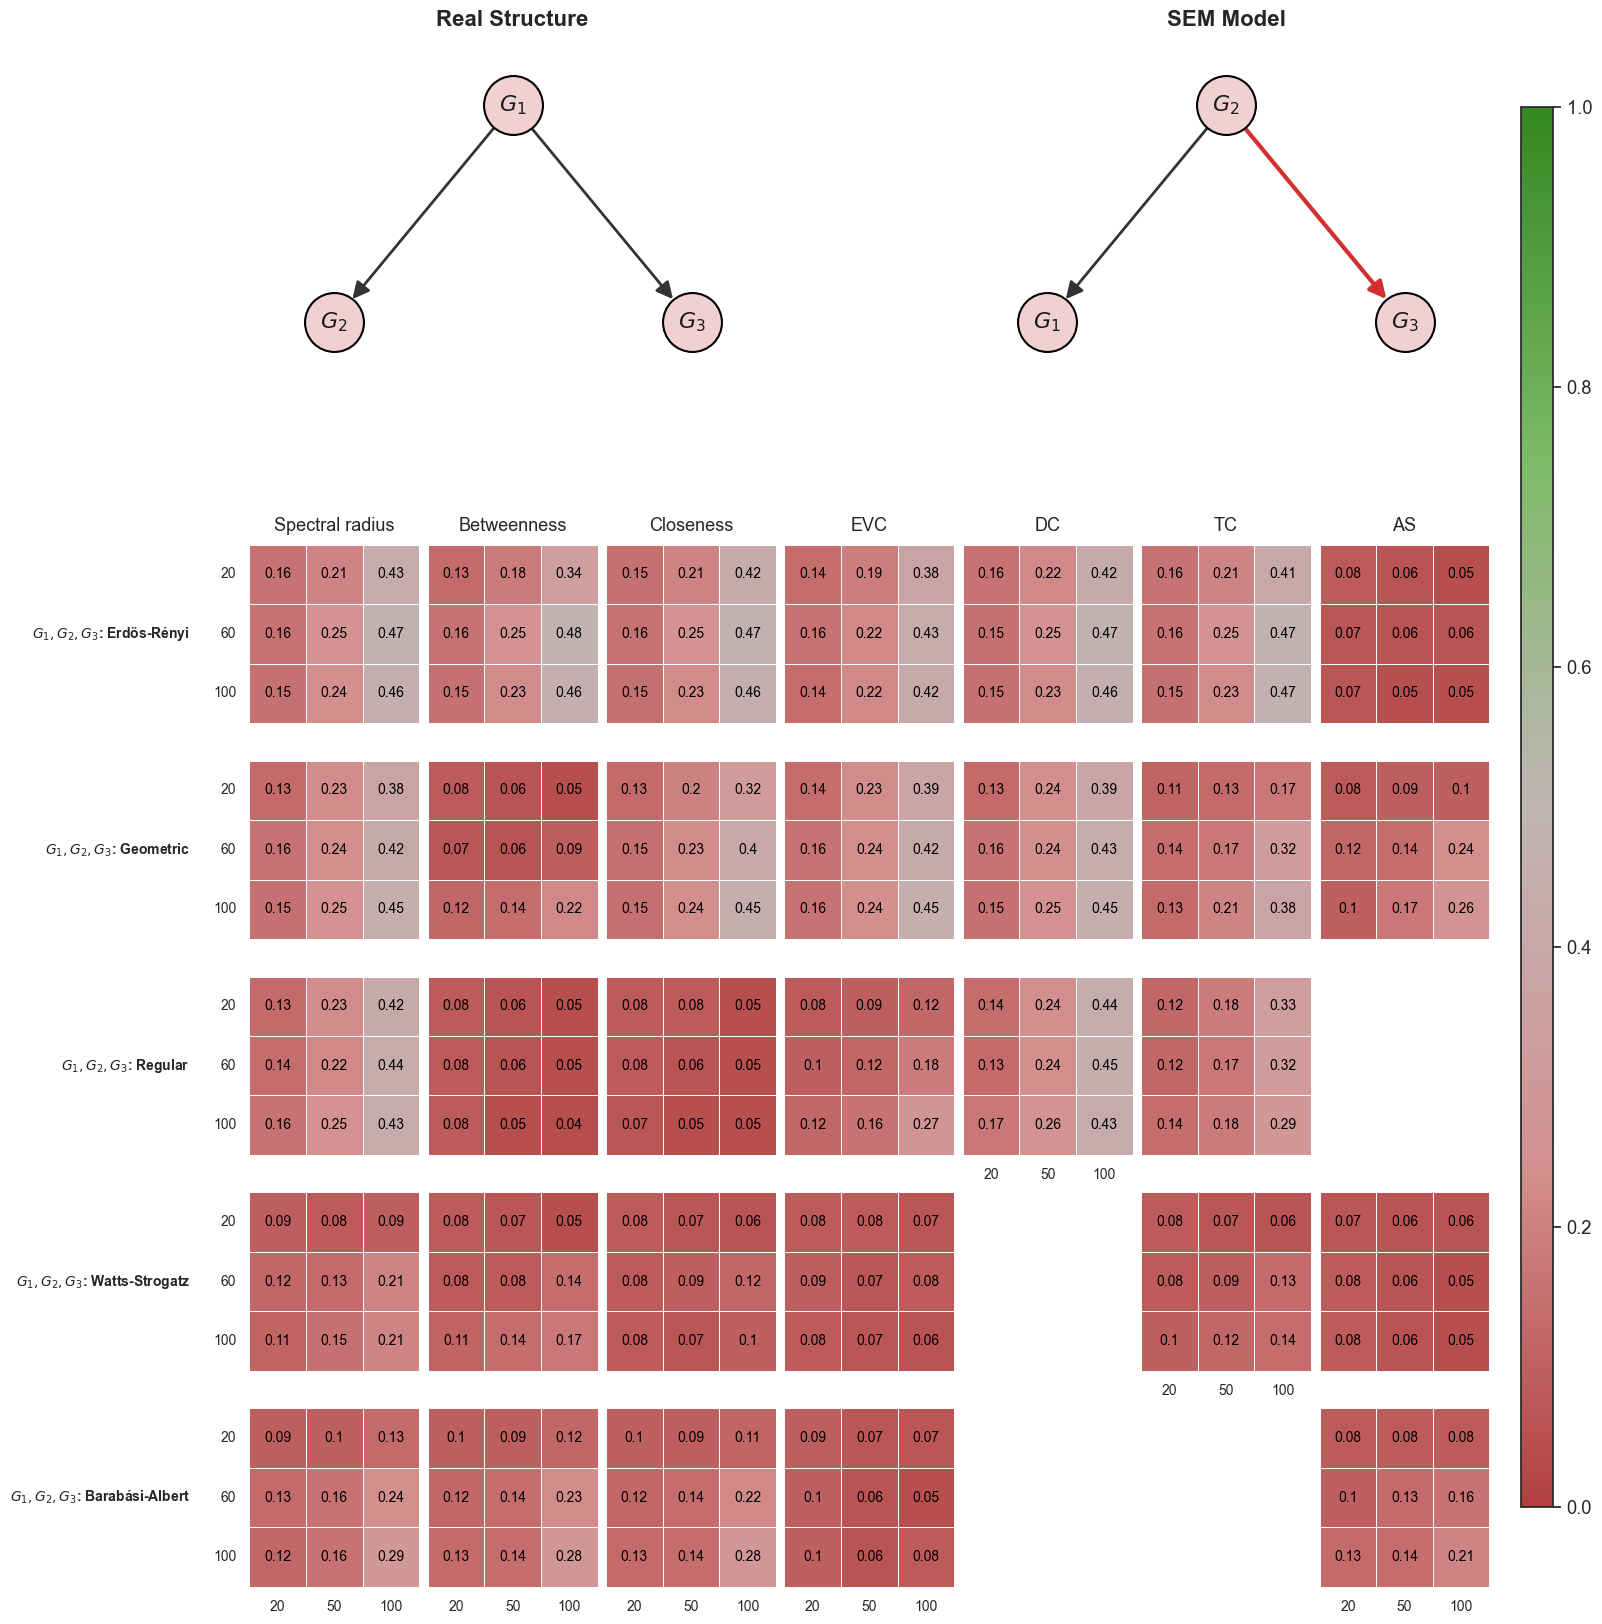

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\chi_square\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_chi_square_B_to_C.pdf


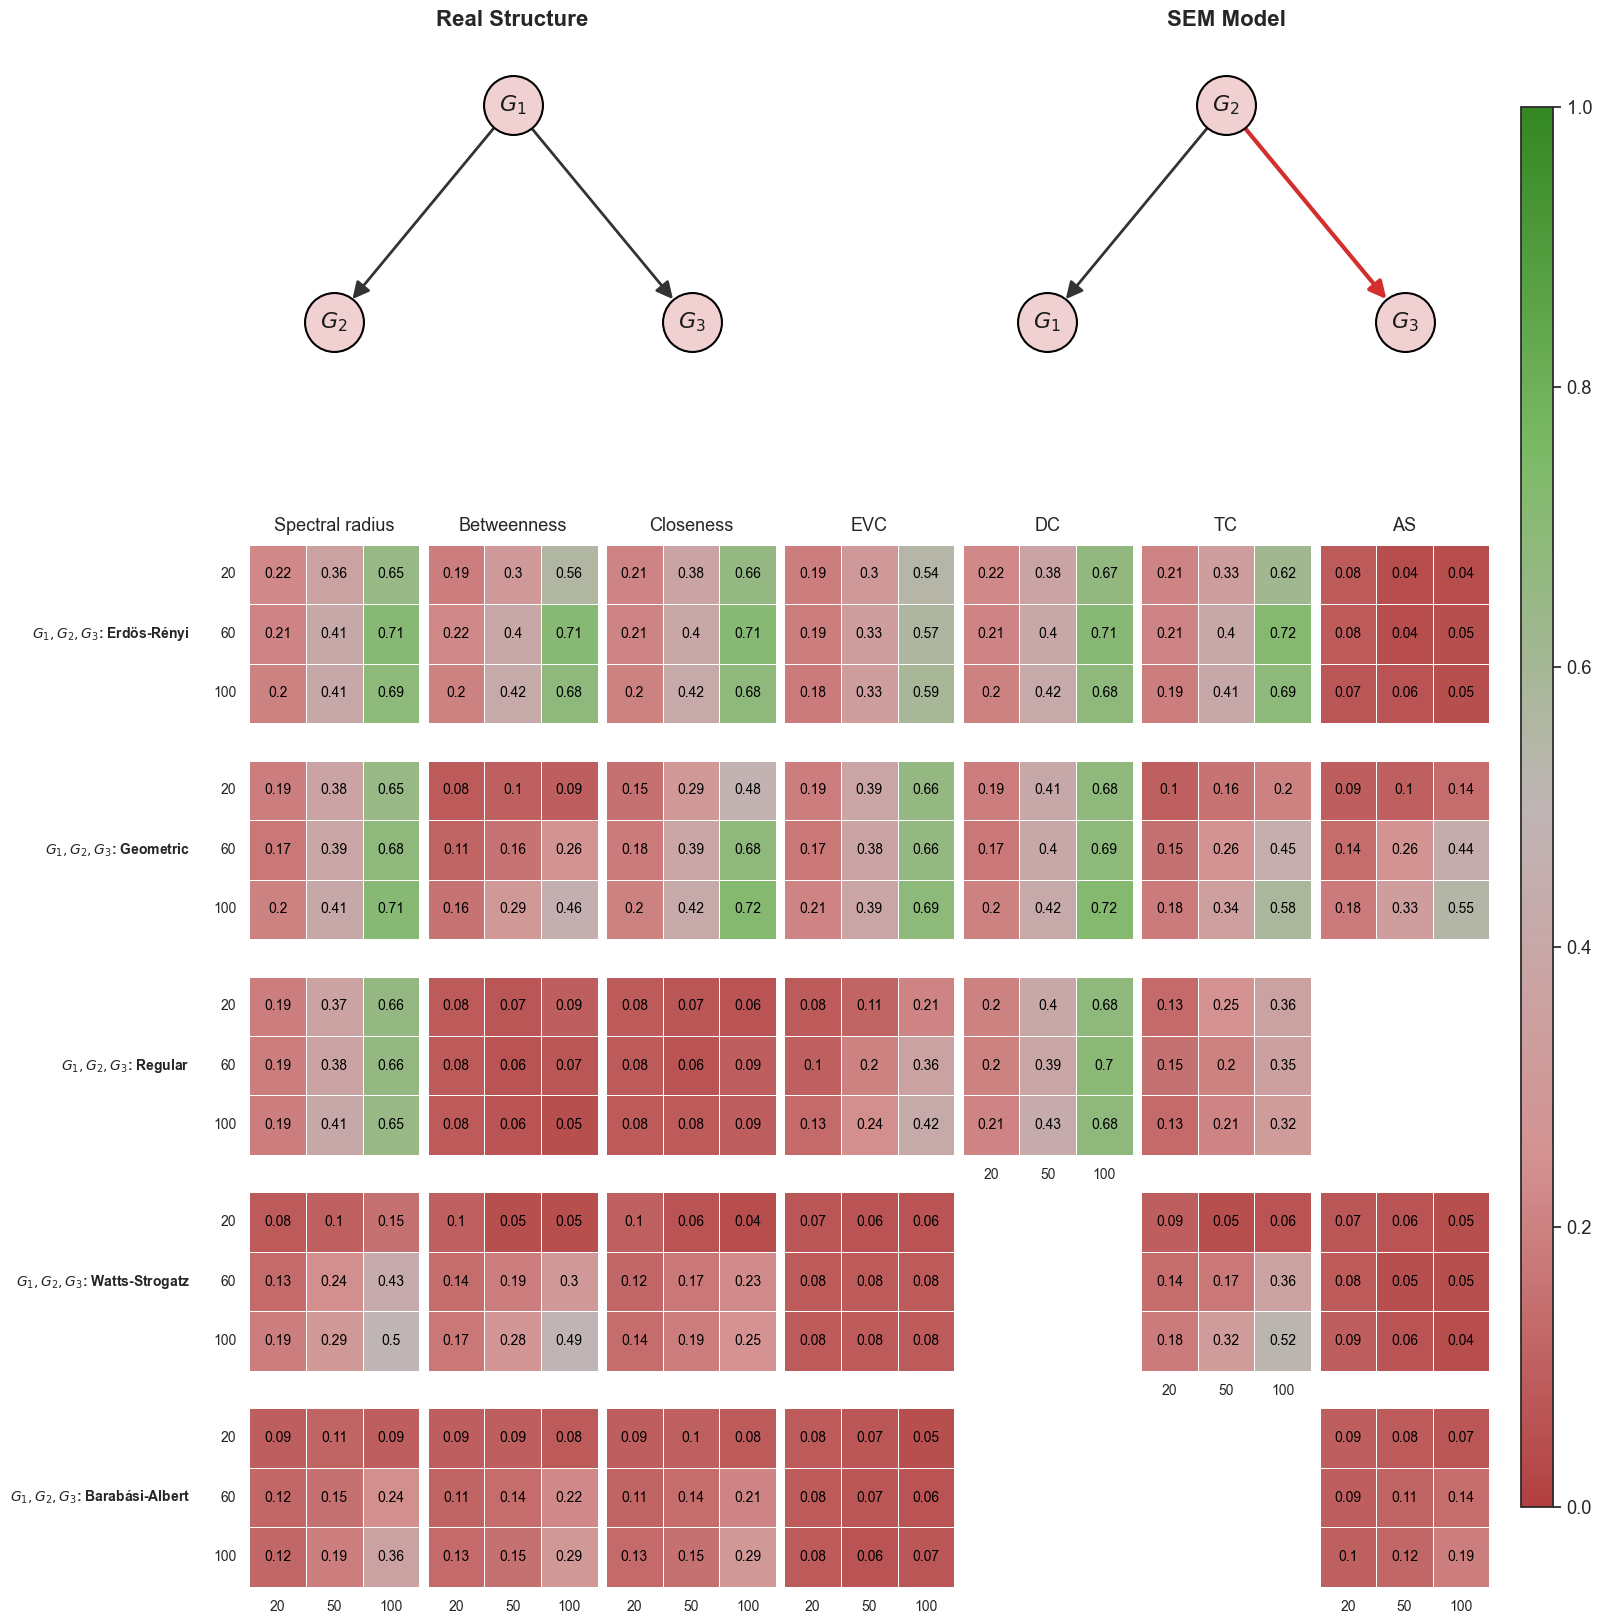

Salvo em: ..\dados\resultados\sim\figuras\Heatmap_Cenario_3\SEM_Class_3_Garfo_B\F\Heatmap_5_Cenario_3_SEM_Class_3_Garfo_B_F_B_to_C.pdf


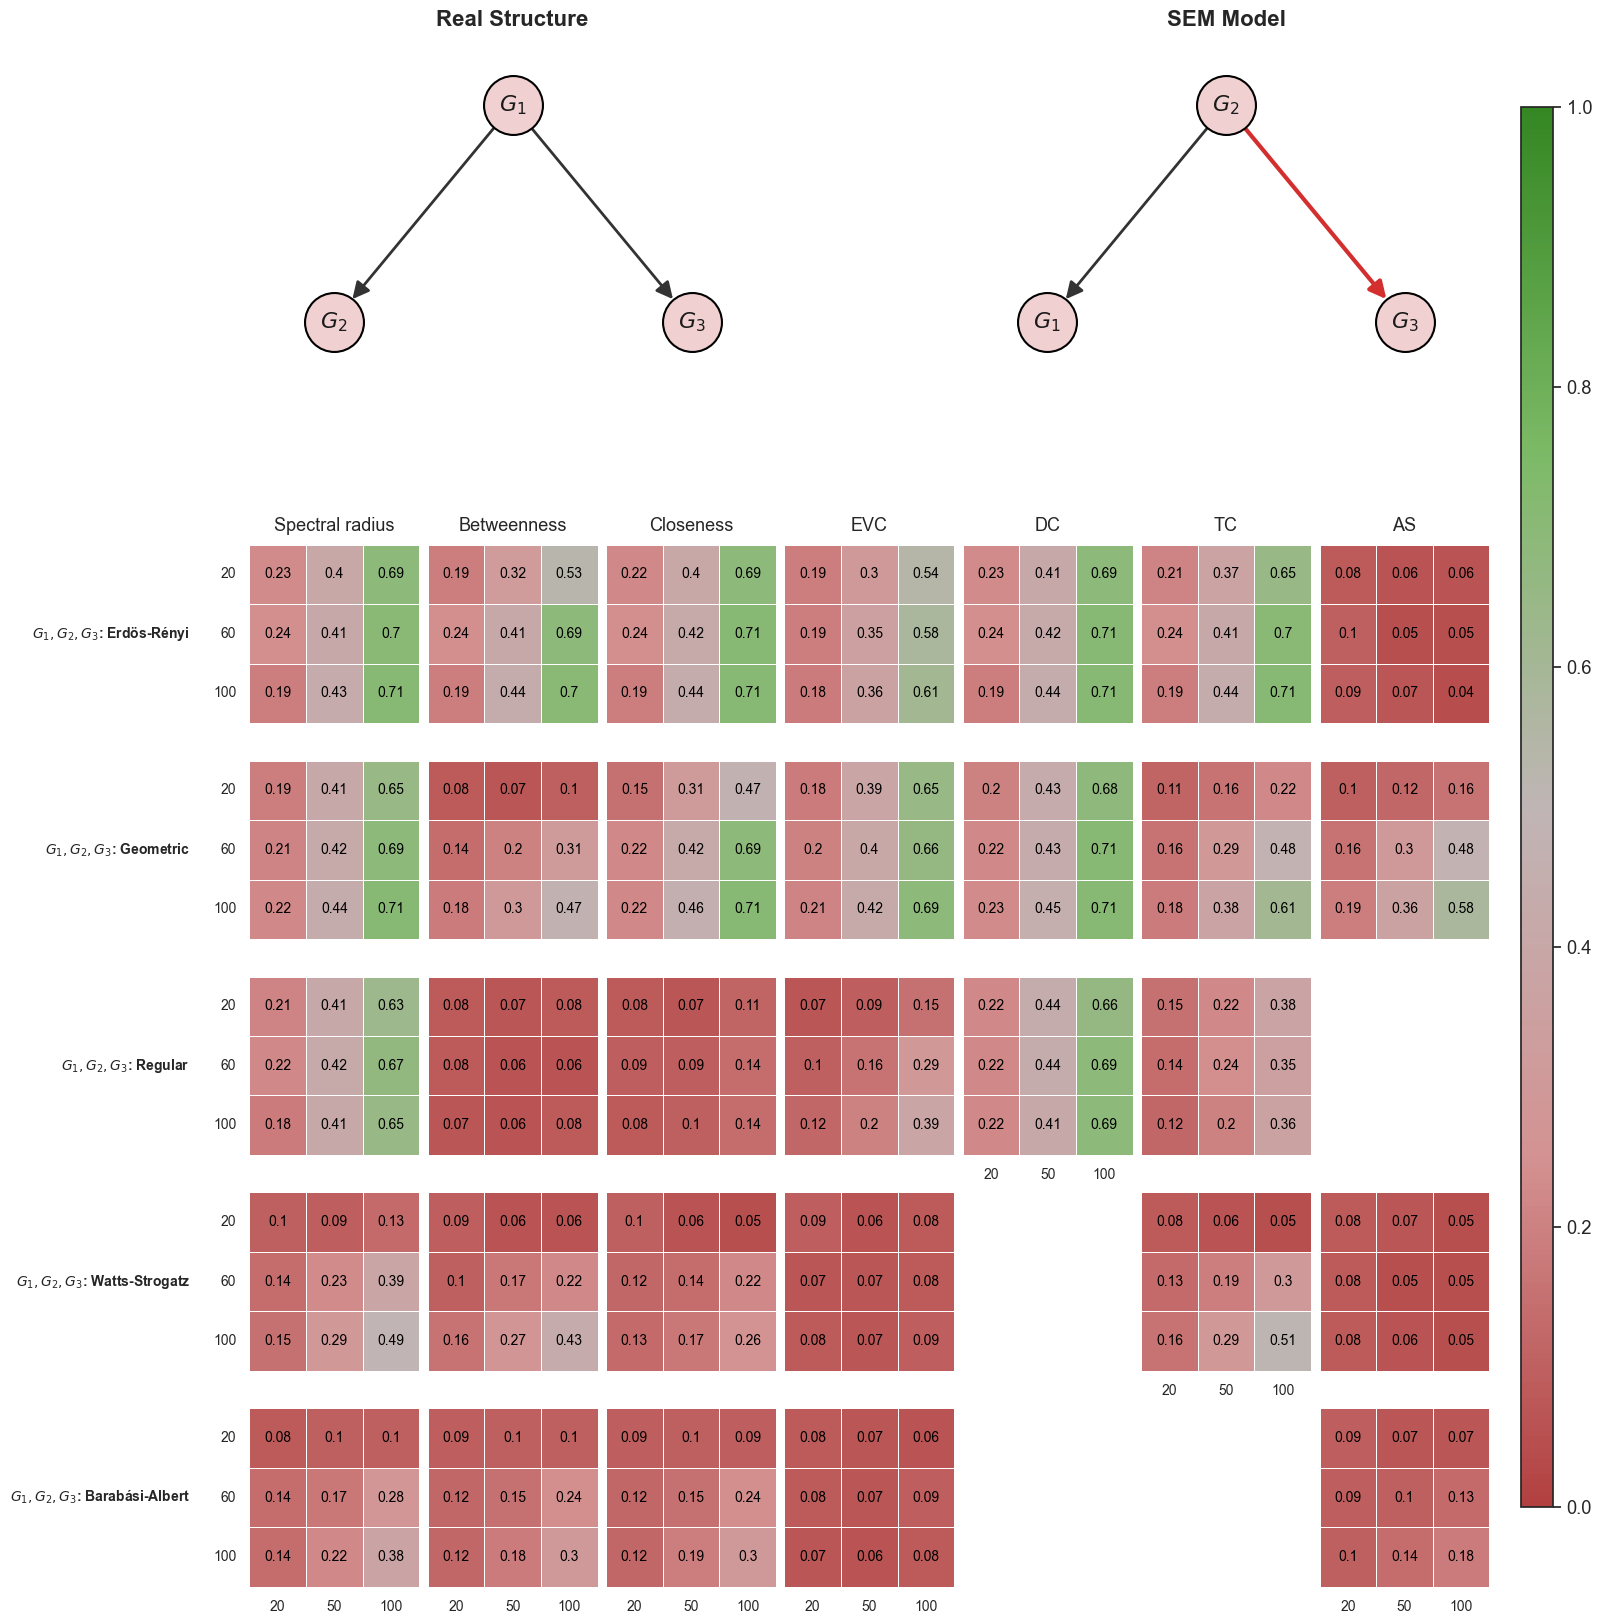

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
import os

def desenhar_estrutura(ax, estrutura, direcao_analisada):
    """
    Desenha o grafo da estrutura no eixo fornecido, destacando em vermelho 
    a aresta correspondente à direcao_analisada.
    Utiliza coordenadas fixas para garantir qualidade de publicação (estilo artigo).
    """
    G = nx.DiGraph()
    # Adiciona as arestas partindo da lista de estrutura
    for aresta in estrutura:
        if '->' in aresta:
            u, v = aresta.split('->')
            G.add_edge(u.strip(), v.strip())
        elif ' ' in aresta:
            u, v = aresta.split(' ')
            G.add_node(u.strip())
            G.add_node(v.strip())

    # --- DEFINIÇÃO MANUAL DE LAYOUT PARA QUALIDADE DE PUBLICAÇÃO ---
    nodes = sorted(list(G.nodes()))
    pos = {}
    
    if nodes == ['A', 'B']:
        # Casos 1 e 2 (Independência ou Efeito Direto)
        pos = {'A': (0, 0), 'B': (1, 0)}
        
    elif nodes == ['A', 'B', 'C']:
        arestas_tuplas = list(G.edges())
        
        # --- AJUSTE: Agrupamento Lógico de Garfos e Colisores (Nó central elevado) ---
        
        # Centro em A (Garfo em A ou Colisor em A)
        if (('A', 'B') in arestas_tuplas and ('A', 'C') in arestas_tuplas) or \
           (('B', 'A') in arestas_tuplas and ('C', 'A') in arestas_tuplas):
            pos = {'A': (1, 1), 'B': (0, 0), 'C': (2, 0)}
            
        # Centro em B (Garfo em B ou Colisor em B)
        elif (('B', 'A') in arestas_tuplas and ('B', 'C') in arestas_tuplas) or \
             (('A', 'B') in arestas_tuplas and ('C', 'B') in arestas_tuplas):
            pos = {'A': (0, 0), 'B': (1, 1), 'C': (2, 0)}
            
        # Centro em C (Garfo em C ou Colisor em C)
        elif (('C', 'A') in arestas_tuplas and ('C', 'B') in arestas_tuplas) or \
             (('A', 'C') in arestas_tuplas and ('B', 'C') in arestas_tuplas):
            pos = {'A': (0, 0), 'B': (2, 0), 'C': (1, 1)}
            
        # --- Cadeias de Mediação (Garante fluxo em linha reta) ---
        elif ('A', 'B') in arestas_tuplas and ('B', 'C') in arestas_tuplas:
            pos = {'A': (0, 0), 'B': (1, 0), 'C': (2, 0)}
        elif ('C', 'B') in arestas_tuplas and ('B', 'A') in arestas_tuplas:
            pos = {'C': (0, 0), 'B': (1, 0), 'A': (2, 0)}
        elif ('A', 'C') in arestas_tuplas and ('C', 'B') in arestas_tuplas:
            pos = {'A': (0, 0), 'C': (1, 0), 'B': (2, 0)}
        elif ('B', 'C') in arestas_tuplas and ('C', 'A') in arestas_tuplas:
            pos = {'B': (0, 0), 'C': (1, 0), 'A': (2, 0)}
        elif ('B', 'A') in arestas_tuplas and ('A', 'C') in arestas_tuplas:
            pos = {'B': (0, 0), 'A': (1, 0), 'C': (2, 0)}
        elif ('C', 'A') in arestas_tuplas and ('A', 'B') in arestas_tuplas:
            pos = {'C': (0, 0), 'A': (1, 0), 'B': (2, 0)}
        else:
            # Padrão genérico
            pos = {'A': (0, 0), 'B': (1, 0), 'C': (2, 0)}
            
    elif nodes == ['A', 'B', 'C', 'D']:
        # Caso 4 (Cascata)
        pos = {'A': (0, 2), 'B': (1, 1), 'C': (0, 0), 'D': (-1, -1)}
        
    else:
        # Fallback de segurança
        pos = nx.spring_layout(G)

    # Mapeamento de 'A', 'B', 'C', 'D' para G_1, G_2, G_3, G_4
    mapeamento_labels = {}
    for node in G.nodes():
        idx = ord(node.upper()) - ord('A') + 1 
        mapeamento_labels[node] = f"$G_{idx}$"
        
    # Configurações estéticas do nó
    node_size = 1800
    node_color = '#f0d0d0'
    edge_color_default = '#333333'
    edge_color_highlight = '#D32F2F'

    # Desenhar os nós
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color, 
                           edgecolors='black', node_size=node_size, linewidths=1.5)
    
    # Desenhar os rótulos
    nx.draw_networkx_labels(G, pos, labels=mapeamento_labels, ax=ax, 
                            font_size=16, font_weight='bold')
    
    # Prepara aresta analisada
    if '->' in direcao_analisada:
        u_analisada, v_analisada = [x.strip() for x in direcao_analisada.split('->')]
    else:
        u_analisada, v_analisada = None, None
    
    # Desenhar as arestas
    for u, v in G.edges():
        is_analyzed = (u == u_analisada and v == v_analisada)
        color = edge_color_highlight if is_analyzed else edge_color_default
        
        width = 3.0 if is_analyzed else 2.0
        
        # Curvatura suave se a aresta pula nós (ex: A->C em uma cadeia horizontal)
        rad = 0.0
        if pos[u][1] == pos[v][1] and abs(pos[u][0] - pos[v][0]) > 1:
            rad = -0.3
            
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], ax=ax, edge_color=color, 
            width=width, arrowsize=25, arrowstyle='-|>',
            connectionstyle=f'arc3,rad={rad}', style="-", 
            node_size=node_size, min_source_margin=0, min_target_margin=0
        )
        
    ax.margins(0.2) 
    ax.axis('off')


def plot_power_heatmaps(caminho_csv, noise='uniform', direcao='A->B', 
                        salvar_pdf=False, path_figuras="figuras", caso=None, 
                        estrutura_real=None, estrutura_sem=None):
    
    # Tratamento de erro simples para o caso do arquivo não existir durante o teste
    if not os.path.exists(caminho_csv):
        print(f"Atenção: Arquivo '{caminho_csv}' não encontrado. Gráficos das DAGs serão exibidos vazios para visualização.")
        df = pd.DataFrame(columns=['ruido', 'Direcao', 'Modelo', 'Feature', 'Vértices', 'R', 'Poder_5%'])
    else:
        df = pd.read_csv(caminho_csv)
    
    df_f = df[(df['ruido'] == noise) & (df['Direcao'] == direcao)].copy()
    
    if df_f.empty:
        print(f"Atenção: Nenhum dado encontrado para ruído '{noise}' e direção '{direcao}'.")
        # Renderizar as DAGs mesmo sem dados do Heatmap para testar a estética
        fig, (ax_real, ax_sem) = plt.subplots(1, 2, figsize=(12, 4))
        if estrutura_real and estrutura_sem:
            desenhar_estrutura(ax_real, estrutura_real, direcao)
            ax_real.set_title("DAG Real", fontsize=16, fontweight='bold')
            desenhar_estrutura(ax_sem, estrutura_sem, direcao)
            ax_sem.set_title("DAG do Modelo SEM", fontsize=16, fontweight='bold')
        plt.show()
        return

    nomes_base = {
        'erdos_renyi': 'Erdös-Rényi',
        'geometric': 'Geometric',
        'k_regular': 'Regular',
        'watts_strogatz': 'Watts-Strogatz',
        'barabasi_albert': 'Barabási-Albert'
    }

    def format_model_name(m, estrutura):
        if len(estrutura) == 1:
            if '-' in m:
                p1, p2 = m.split('-')
                return f"$G_1$: {nomes_base.get(p1, p1)}\n$G_2$: {nomes_base.get(p2, p2)}"
            else:
                return f"$G_1, G_2$: {nomes_base.get(m, m)}"
        elif len(estrutura) >= 2:
            nos = set()
            for aresta in estrutura:
                if '->' in aresta:
                    u, v = aresta.split('->')
                    nos.add(u.strip())
                    nos.add(v.strip())
                elif ' ' in aresta:
                    u, v = aresta.split(' ')
                    nos.add(u.strip())
                    nos.add(v.strip())
            
            num_nos = len(nos)
            lista_g = ", ".join([f"G_{i}" for i in range(1, num_nos + 1)])
            return f"${lista_g}$: {nomes_base.get(m, m)}"


    modelos_unicos = df_f['Modelo'].unique()
    
    ordem_base = {
        'erdos_renyi': 0,
        'geometric': 1,
        'k_regular': 2,
        'watts_strogatz': 3,
        'barabasi_albert': 4
    }

    def sort_models(m):
        if '-' in m:
            p1, p2 = m.split('-')
            return (1, ordem_base.get(p1, 99), ordem_base.get(p2, 99))
        else:
            return (0, ordem_base.get(m, 99), -1)
            
    models = sorted(modelos_unicos, key=sort_models)
    
    # Usa a estrutura_sem como base para identificar os labels de nome de modelo
    estrutura_base_labels = estrutura_sem if estrutura_sem else []
    model_labels = [format_model_name(m, estrutura_base_labels) for m in models]
    
    features = [r'$\lambda$', 'BC', 'CC', 'EVC', 'DC', 'TC', 'AS']
    feature_labels = ['Spectral radius', 'Betweenness', 'Closeness', 'EVC', 'DC', 'TC', 'AS']
    
    # --- PALETA DE CORES PERSONALIZADA DA IMAGEM ---
    cores_paleta = ["#b24040", "#d49292", "#c0b5b5", "#7dba67", "#348722"]
    cmap_custom = LinearSegmentedColormap.from_list("custom_palette", cores_paleta)
    
    fig_size = (16, 20)
    if caso and "Caso_3" in caso:
        fig_size = (15, 17)

    fig = plt.figure(figsize=fig_size)
    
    num_colunas = len(features)
    
    # Ajuste de layout
    if estrutura_real and estrutura_sem:
        num_linhas = len(models) + 2
        height_ratios = [1.87, 0.5] + [1] * len(models) 
        offset_row = 2
    else:
        num_linhas = len(models)
        height_ratios = [1] * len(models)
        offset_row = 0
        
    gs = fig.add_gridspec(nrows=num_linhas, ncols=num_colunas, height_ratios=height_ratios, hspace=0.2, wspace=0.05)
    
    if estrutura_real and estrutura_sem:
        # Divide as colunas superiores: DAG Real na esquerda, DAG SEM na direita
        # Com 7 features, colunas [0, 1, 2] para a Real e [4, 5, 6] para a SEM
        ax_dag_real = fig.add_subplot(gs[0, 0:3])
        desenhar_estrutura(ax_dag_real, estrutura_real, direcao)
        ax_dag_real.set_title("Real Structure", fontsize=16, fontweight='bold', pad=15)
        
        ax_dag_sem = fig.add_subplot(gs[0, 4:7])
        desenhar_estrutura(ax_dag_sem, estrutura_sem, direcao)
        ax_dag_sem.set_title("SEM Model", fontsize=16, fontweight='bold', pad=15)

    # Mapear última linha ativa de cada coluna para os ticks do eixo X
    last_active_in_col = {}
    for j, feat in enumerate(features):
        for i in reversed(range(len(models))):
            mod = models[i]
            sub_df = df_f[(df_f['Modelo'] == mod) & (df_f['Feature'] == feat)]
            if not sub_df.empty:
                pivot_k = sub_df.pivot_table(index='Vértices', columns='R', values='Poder_5%')
                if not (pivot_k.isna().all().all() or (pivot_k == 0.0).all().all()):
                    last_active_in_col[j] = i
                    break
    
    # Desenhar os Heatmaps
    for i, mod in enumerate(models):
        for j, feat in enumerate(features):
            ax = fig.add_subplot(gs[i + offset_row, j])
            
            sub_df = df_f[(df_f['Modelo'] == mod) & (df_f['Feature'] == feat)]
            
            if sub_df.empty:
                ax.axis('off')
                continue
                
            pivot_k = sub_df.pivot_table(index='Vértices', columns='R', values='Poder_5%')
            
            if pivot_k.isna().all().all() or (pivot_k == 0.0).all().all():
                ax.axis('off')
            else:
                pivot_k = pivot_k.round(2)
                
                sns.heatmap(pivot_k, ax=ax, cmap=cmap_custom, vmin=0, vmax=1, 
                            annot=True, fmt="g", cbar=False, 
                            annot_kws={"size": 10, "color": "black"}, 
                            linewidths=0.5)
                
                ax.set_ylabel("")
                ax.set_xlabel("")
                ax.tick_params(axis='both', which='major', labelsize=10)
                ax.tick_params(axis='y', rotation=0)
                
                if j != 0:
                    ax.set_yticks([])
                if i != last_active_in_col.get(j, len(models)-1):
                    ax.set_xticks([])
                
            # Colocar o nome da feature no topo dos heatmaps
            if i == 0:
                ax.set_title(feature_labels[j], fontsize=13, pad=10)
            
            # Anotar o nome do modelo (G1, G2) na primeira coluna
            if j == 0:
                ax.annotate(model_labels[i], xy=(-0.35, 0.5), xycoords='axes fraction',
                            fontsize=10, fontweight='bold', rotation=0,
                            ha='right', va='center')
    
    # Ajusta margem direita para caber a barra de cores geral do heatmap
    fig.subplots_adjust(right=0.9) 
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [esquerda, base, largura, altura]
    sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=plt.Normalize(vmin=0, vmax=1))
    fig.colorbar(sm, cax=cbar_ax)

    if salvar_pdf:
        os.makedirs(path_figuras, exist_ok=True)
        dir_nome_arquivo = direcao.replace("->", "_to_")
        nome_arquivo = f"Heatmap_5_{caso.replace('/', '_')}_{noise}_{dir_nome_arquivo}.pdf"
        
        caminho_salvar = os.path.join(path_figuras, nome_arquivo)
        plt.savefig(caminho_salvar, bbox_inches='tight', dpi=300)
        print(f"Salvo em: {caminho_salvar}")
        
    plt.show()
    plt.close()


modelos_sem = {
    "Cenario_1/SEM_Grafo_REAL": {"arestas": ["A->B"]},
    "Cenario_2/SEM_Grafo_REAL": {"arestas": ["A->B"]},
    "Cenario_3/SEM_Class_1_Garfo_A_REAL": {"arestas": ["A->B", "A->C"]},
    "Cenario_3/SEM_Class_1_Cadeia_B_A_C": {"arestas": ["B->A", "A->C"]},
    "Cenario_3/SEM_Class_1_Cadeia_C_A_B": {"arestas": ["C->A", "A->B"]},
    "Cenario_3/SEM_Class_2_Colisor_A": {"arestas": ["B->A", "C->A"]},
    "Cenario_3/SEM_Class_3_Garfo_B": {"arestas": ["B->A", "B->C"]},
    "Cenario_3/SEM_Class_4_Colisor_B": {"arestas": ["A->B", "C->B"]},
    "Cenario_3/SEM_Class_5_Cadeia_A_C_B": {"arestas": ["A->C", "C->B"]},
    "Cenario_3/SEM_Class_6_Colisor_C": {"arestas": ["A->C", "B->C"]},
    "Cenario_3/SEM_Class_7_Triangulo_A_B-B_C-A_C": {"arestas": ["A->B", "A->C", "B->C"]},
    "Cenario_4/SEM_Grafo_REAL": {"arestas": ["A->B", "A->C", "B->C", "C->D"]}
}

estrutura_real = {
    "Cenario_1": {"arestas": ["A B"]},
    "Cenario_2": {"arestas": ["A->B"]},
    "Cenario_3": {"arestas": ["A->B", "A->C"]},
    "Cenario_4": {"arestas": ["A->B", "A->C", "B->C", "C->D"]}
}


cenario = "Cenario_3"
modelo_sem = "SEM_Class_3_Garfo_B"
noises = ["gaussian", "uniform", "chi_square", "F"]

caso = f"{cenario}/{modelo_sem}"
for aresta_analise in modelos_sem[caso]["arestas"]:
    for noise in noises:
        plot_power_heatmaps(
                caminho_csv=os.path.join("..", "dados", "resultados", "sim", caso, "resultados_power.csv"), 
                noise=noise, 
                direcao=aresta_analise,
                caso=caso,
                salvar_pdf=True,
                estrutura_real=estrutura_real[cenario]["arestas"],  
                estrutura_sem=modelos_sem[caso]["arestas"],         
                path_figuras=os.path.join("..", "dados", "resultados", "sim", "figuras", f"Heatmap_{cenario}", modelo_sem, noise)
            )

### Plot dos Modelos estrela em Grafos Direcionais

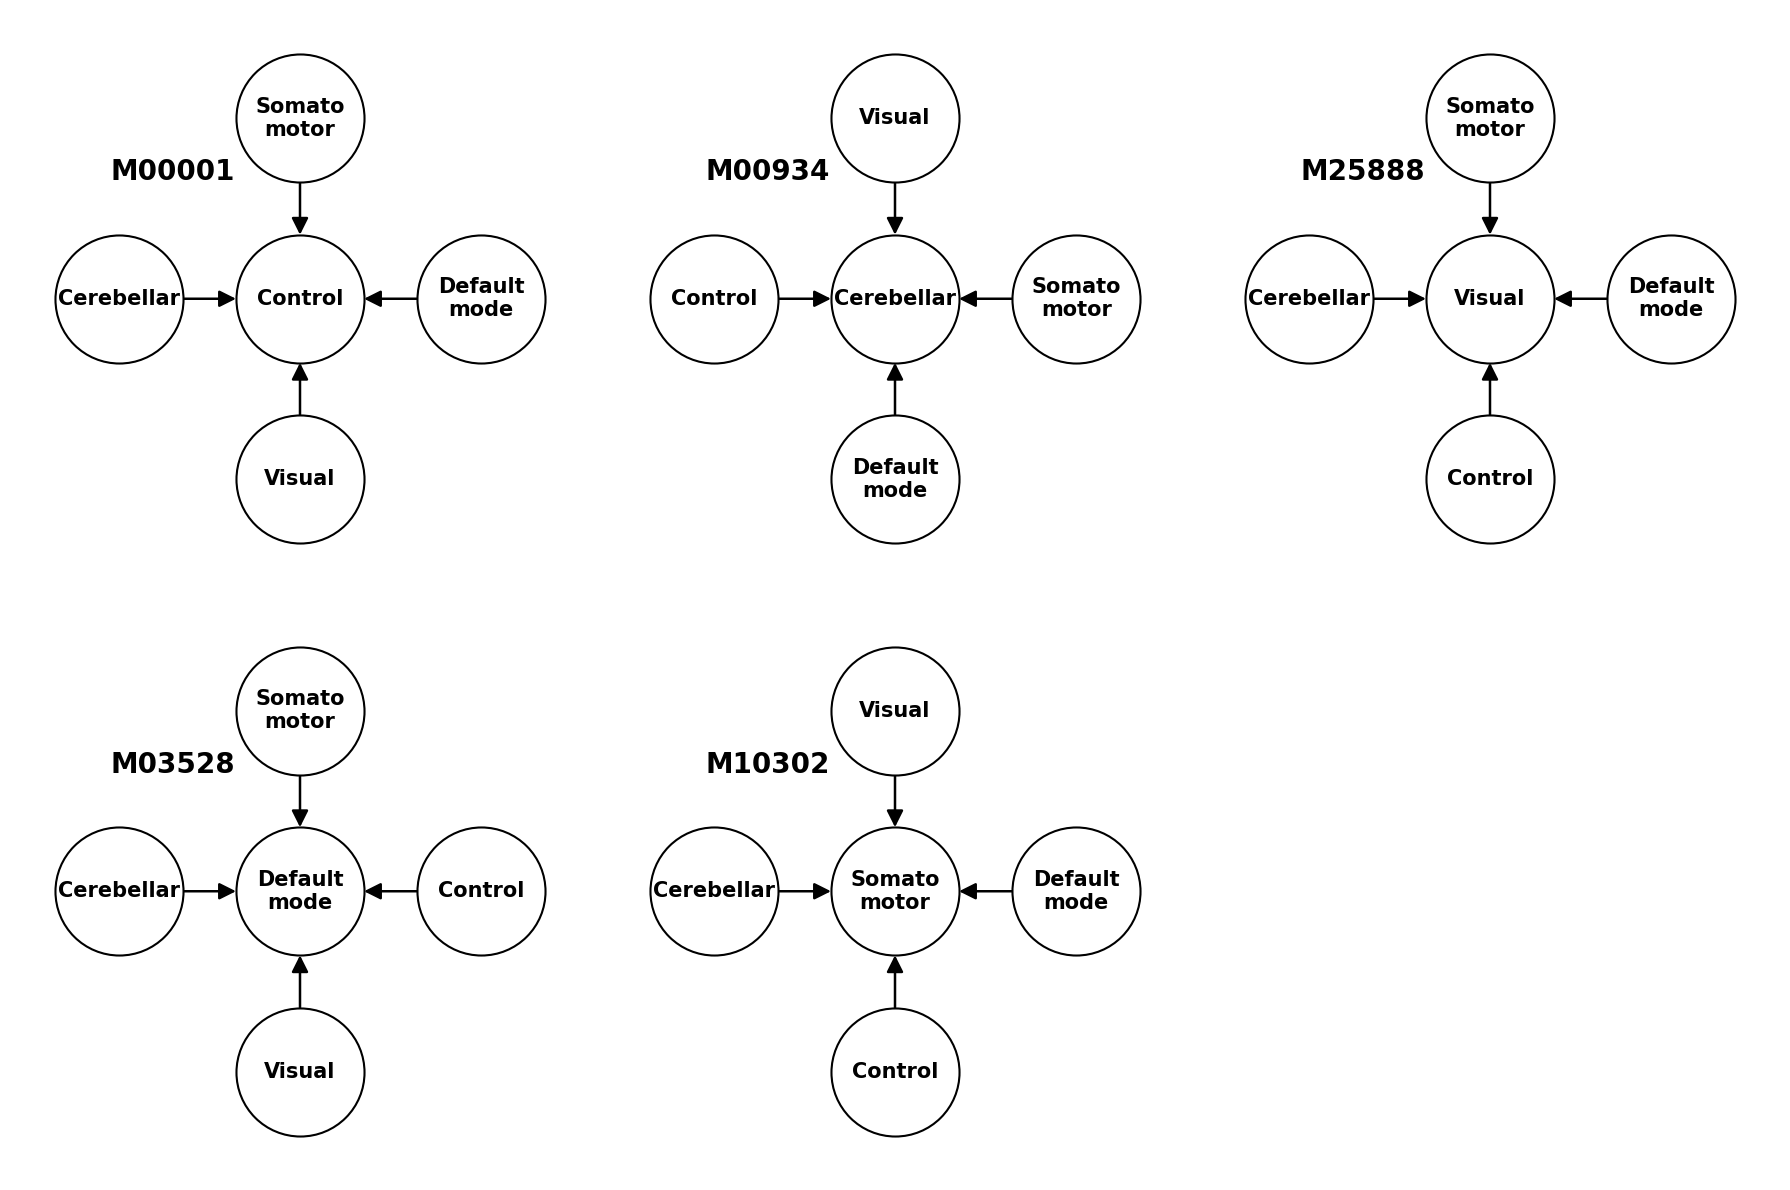

In [33]:
import networkx as nx
import matplotlib.pyplot as plt
import os

# 1. Definição dos dados para cada um dos 5 grafos
# Formato: (Identificador, Centro, Topo, Direita, Baixo, Esquerda)
dados_grafos = [
    ("M00001", "Control", "Somato\nmotor", "Default\nmode", "Visual", "Cerebellar"),
    ("M00934", "Cerebellar", "Visual", "Somato\nmotor", "Default\nmode", "Control"),
    ("M25888", "Visual", "Somato\nmotor", "Default\nmode", "Control", "Cerebellar"),
    ("M03528", "Default\nmode", "Somato\nmotor", "Control", "Visual", "Cerebellar"),
    ("M10302", "Somato\nmotor", "Visual", "Default\nmode", "Control", "Cerebellar")
]

# 2. Configuração da figura com subplots (2 linhas e 3 colunas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten() # Transforma a matriz de eixos numa lista simples

for i, dados in enumerate(dados_grafos):
    id_grafo, centro, topo, direita, baixo, esquerda = dados
    ax = axes[i]
    
    # Cria o grafo direcionado
    G = nx.DiGraph()
    
    # Adiciona as arestas (todas apontando para o nó central)
    arestas = [
        (topo, centro),
        (direita, centro),
        (baixo, centro),
        (esquerda, centro)
    ]
    G.add_edges_from(arestas)
    
    # Define as posições fixas (formato de cruz)
    posicao = {
        centro: (0, 0),
        topo: (0, 1),
        direita: (1, 0),
        baixo: (0, -1),
        esquerda: (-1, 0)
    }
    
    # Desenha o grafo no subplot correspondente
    nx.draw(
        G, posicao, ax=ax,
        with_labels=True,
        node_size=8500, 
        node_color="white",
        edgecolors="black",
        linewidths=1.5,
        width=1.8,
        arrowsize=25,
        font_size=15, 
        font_weight="bold" # No NetworkX usa-se com underline
    )
    
    # CORREÇÃO AQUI: fontweight='bold' (sem underline) para o Matplotlib
    ax.text(-0.7, 0.7, id_grafo, 
            color='black', 
            fontsize=20, 
            fontweight='bold', 
            ha='center', va='center')
    
    # Ajusta os limites para garantir que os círculos não sejam cortados
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    
    # Remove os eixos do subplot
    ax.axis('off')

# 3. Remove o último subplot que ficou vazio (o 6º espaço)
axes[5].axis('off')

plt.tight_layout()

# 4. Salvar o ficheiro no caminho especificado
caminho = "../dados/resultados/sim/figuras"
if not os.path.exists(caminho):
    os.makedirs(caminho)

plt.savefig(f"{caminho}/grafos_modelos.pdf", format="pdf")
plt.show()

### Plot dos grafos direcionaris para cenários

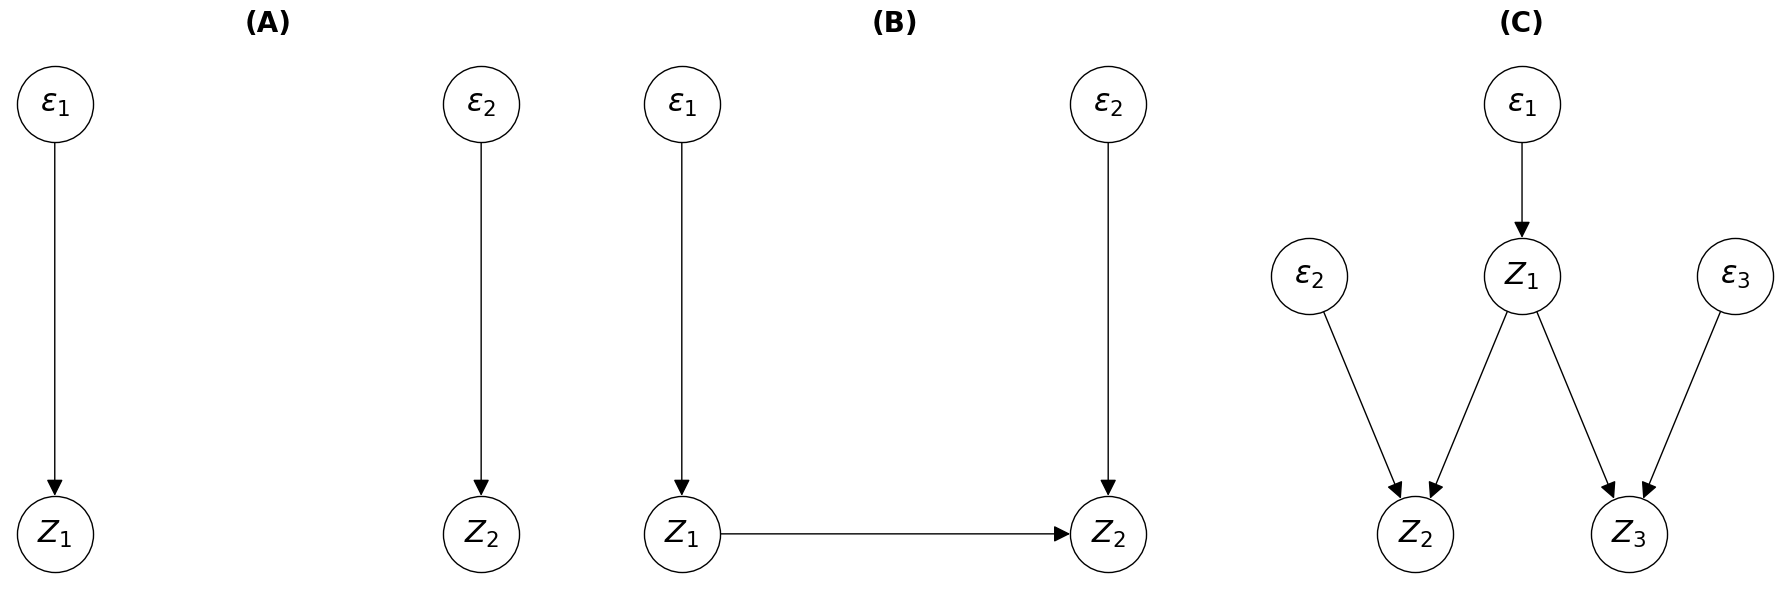

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# ALTERAÇÃO 1: Aumentei a largura do figsize de 15 para 18
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Opções comuns de estilo para todos os grafos
style_options = {
    "node_size": 3000,
    "node_color": 'white',
    "font_size": 22,
    "font_weight": 'bold',
    "edgecolors": 'black',
    "arrowsize": 25
}

# ==========================================
# CENÁRIO 1: Independência (Desenhado em axes[0])
# ==========================================
dag1 = nx.DiGraph()
dag1.add_edges_from([("e1", "Z1"), ("e2", "Z2")])
pos1 = {"e1": (0, 1), "Z1": (0, 0), "e2": (1, 1), "Z2": (1, 0)}
labels1 = {"e1": r"$\epsilon_1$", "Z1": "$Z_1$", "e2": r"$\epsilon_2$", "Z2": "$Z_2$"}

nx.draw_networkx(dag1, ax=axes[0], pos=pos1, labels=labels1, **style_options)
axes[0].set_title("(A)", fontsize=20, fontweight='bold', pad=20)
axes[0].axis('off')

# ==========================================
# CENÁRIO 2: Causalidade Direta (Desenhado em axes[1])
# ==========================================
dag2 = nx.DiGraph()
dag2.add_edges_from([("e1", "Z1"), ("Z1", "Z2"), ("e2", "Z2")])
pos2 = {"e1": (0, 1), "Z1": (0, 0), "e2": (1, 1), "Z2": (1, 0)}
labels2 = {"e1": r"$\epsilon_1$", "Z1": "$Z_1$", "e2": r"$\epsilon_2$", "Z2": "$Z_2$"}

nx.draw_networkx(dag2, ax=axes[1], pos=pos2, labels=labels2, **style_options)
axes[1].set_title("(B)", fontsize=20, fontweight='bold', pad=20)
axes[1].axis('off')

# ==========================================
# CENÁRIO 3: Confundimento (Desenhado em axes[2])
# ==========================================
dag3 = nx.DiGraph()
dag3.add_edges_from([("e1", "Z1"), ("Z1", "Z2"), ("Z1", "Z3"), ("e2", "Z2"), ("e3", "Z3")])
pos3 = {"e1": (0, 2.5), "Z1": (0, 1.5), "Z2": (-1, 0), "Z3": (1, 0), "e2": (-2, 1.5), "e3": (2, 1.5)}
labels3 = {"e1": r"$\epsilon_1$", "Z1": "$Z_1$", "Z2": "$Z_2$", "Z3": "$Z_3$", "e2": r"$\epsilon_2$", "e3": r"$\epsilon_3$"}

nx.draw_networkx(dag3, ax=axes[2], pos=pos3, labels=labels3, **style_options)
axes[2].set_title("(C)", fontsize=20, fontweight='bold', pad=20)
axes[2].axis('off')

# ==========================================
# AJUSTES FINAIS E SALVAMENTO
# ==========================================

# ALTERAÇÃO 2: Adicionei o w_pad (width padding) para forçar distância entre os subplots
plt.tight_layout(w_pad=8.0)

# Salva a figura combinada
plt.savefig("../dados/resultados/sim/figuras/tres_cenarios.pdf", format="pdf", bbox_inches="tight")
plt.show()

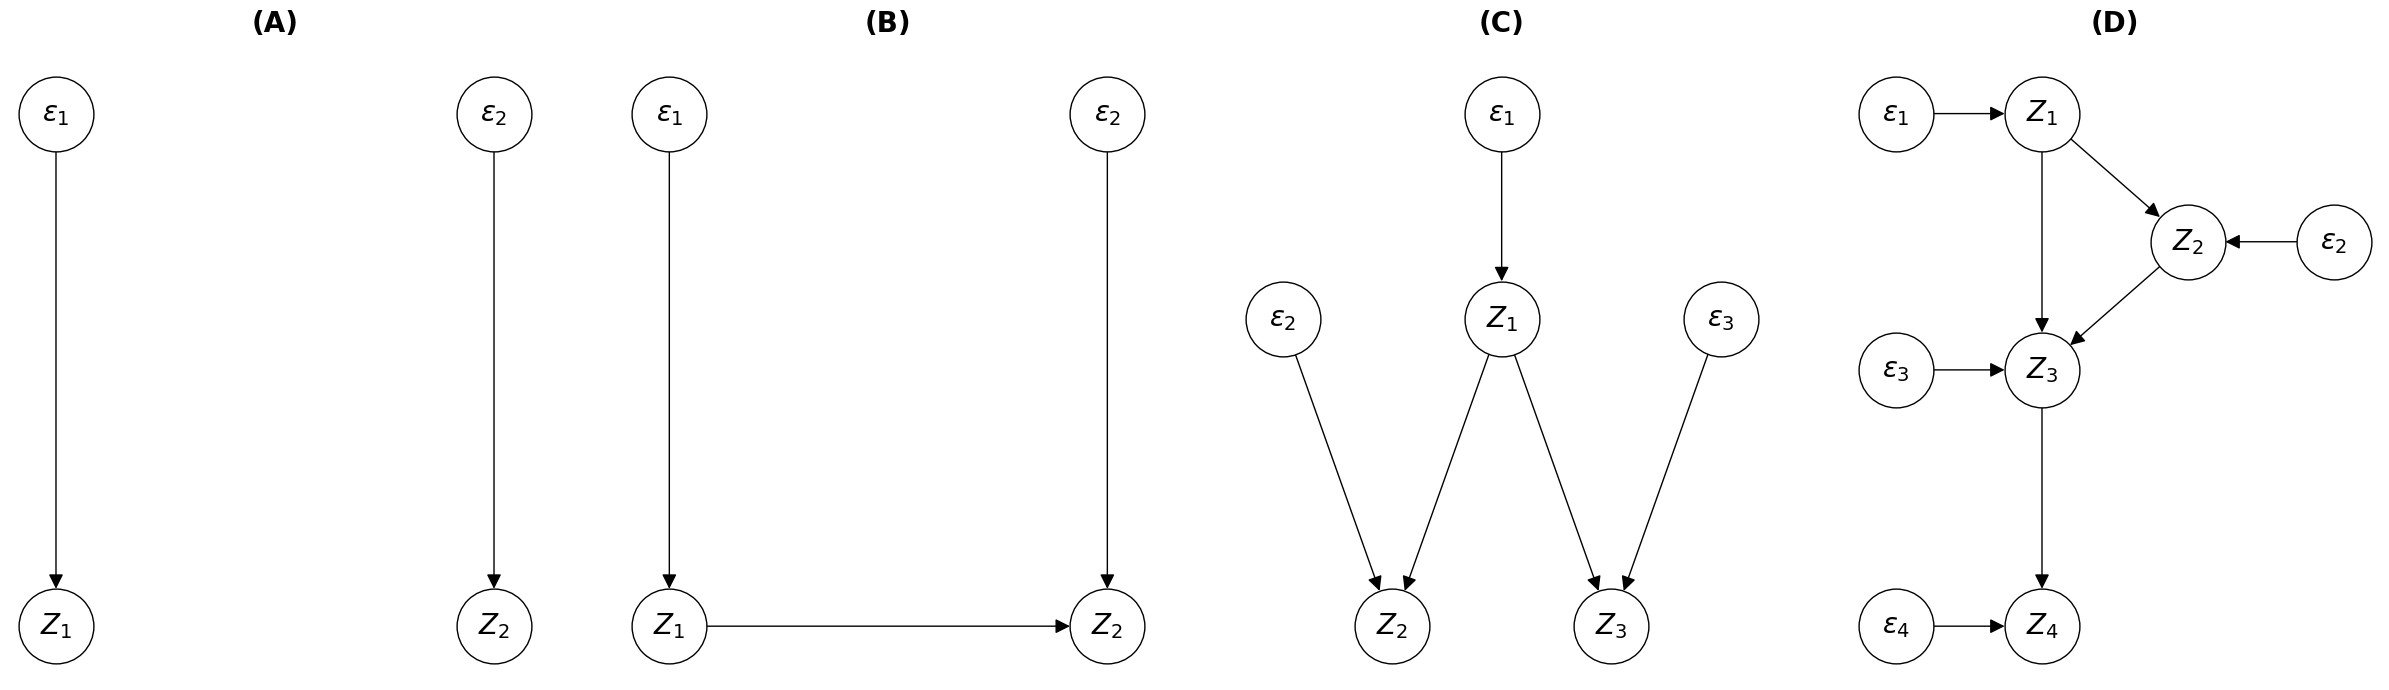

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

# Subplots configurados para 4 cenários
fig, axes = plt.subplots(1, 4, figsize=(24, 7))

# Opções comuns de estilo para todos os grafos
style_options = {
    "node_size": 2900,
    "node_color": 'white',
    "font_size": 20,
    "font_weight": 'bold',
    "edgecolors": 'black',
    "arrowsize": 22
}

# ==========================================
# CENÁRIO 1: Independência (Desenhado em axes[0])
# ==========================================
dag1 = nx.DiGraph()
dag1.add_edges_from([("e1", "Z1"), ("e2", "Z2")])
pos1 = {"e1": (0, 1), "Z1": (0, 0), "e2": (1, 1), "Z2": (1, 0)}
labels1 = {"e1": r"$\epsilon_1$", "Z1": "$Z_1$", "e2": r"$\epsilon_2$", "Z2": "$Z_2$"}

nx.draw_networkx(dag1, ax=axes[0], pos=pos1, labels=labels1, **style_options)
axes[0].set_title("(A)", fontsize=20, fontweight='bold', pad=20)
axes[0].axis('off')

# ==========================================
# CENÁRIO 2: Causalidade Direta (Desenhado em axes[1])
# ==========================================
dag2 = nx.DiGraph()
dag2.add_edges_from([("e1", "Z1"), ("Z1", "Z2"), ("e2", "Z2")])
pos2 = {"e1": (0, 1), "Z1": (0, 0), "e2": (1, 1), "Z2": (1, 0)}
labels2 = {"e1": r"$\epsilon_1$", "Z1": "$Z_1$", "e2": r"$\epsilon_2$", "Z2": "$Z_2$"}

nx.draw_networkx(dag2, ax=axes[1], pos=pos2, labels=labels2, **style_options)
axes[1].set_title("(B)", fontsize=20, fontweight='bold', pad=20)
axes[1].axis('off')

# ==========================================
# CENÁRIO 3: Confundimento (Desenhado em axes[2])
# ==========================================
dag3 = nx.DiGraph()
dag3.add_edges_from([("e1", "Z1"), ("Z1", "Z2"), ("Z1", "Z3"), ("e2", "Z2"), ("e3", "Z3")])
pos3 = {"e1": (0, 2.5), "Z1": (0, 1.5), "Z2": (-1, 0), "Z3": (1, 0), "e2": (-2, 1.5), "e3": (2, 1.5)}
labels3 = {"e1": r"$\epsilon_1$", "Z1": "$Z_1$", "Z2": "$Z_2$", "Z3": "$Z_3$", "e2": r"$\epsilon_2$", "e3": r"$\epsilon_3$"}

nx.draw_networkx(dag3, ax=axes[2], pos=pos3, labels=labels3, **style_options)
axes[2].set_title("(C)", fontsize=20, fontweight='bold', pad=20)
axes[2].axis('off')

# ==========================================
# CENÁRIO 4: Estrutura Complexa (Desenhado em axes[3])
# ==========================================
dag4 = nx.DiGraph()
dag4.add_edges_from([
    ("e1", "Z1"), ("e2", "Z2"), ("e3", "Z3"), ("e4", "Z4"),
    ("Z1", "Z2"), ("Z1", "Z3"), ("Z2", "Z3"), ("Z3", "Z4")
])

# Layout atualizado: e1 e e4 posicionados à esquerda
pos4 = {
    "Z1": (0, 2),    "e1": (-1.5, 2), # Alterado
    "Z2": (1.5, 1),  "e2": (3, 1),
    "Z3": (0, 0),    "e3": (-1.5, 0),
    "Z4": (0, -2),   "e4": (-1.5, -2) # Alterado
}

labels4 = {
    "e1": r"$\epsilon_1$", "Z1": "$Z_1$", 
    "e2": r"$\epsilon_2$", "Z2": "$Z_2$", 
    "e3": r"$\epsilon_3$", "Z3": "$Z_3$", 
    "e4": r"$\epsilon_4$", "Z4": "$Z_4$"
}

nx.draw_networkx(dag4, ax=axes[3], pos=pos4, labels=labels4, **style_options)
axes[3].set_title("(D)", fontsize=20, fontweight='bold', pad=20)
axes[3].axis('off')

# ==========================================
# AJUSTES FINAIS E SALVAMENTO
# ==========================================
plt.tight_layout(w_pad=6.0)

plt.savefig("../dados/resultados/sim/figuras/quatro_cenarios.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Plot Bootstrap AUC - Ao longo das Features

#### Caso 1

Calculating Estimations and CI for all scenarios. This might take a few seconds...
Generating Matrix Plot with strict numerical positioning...


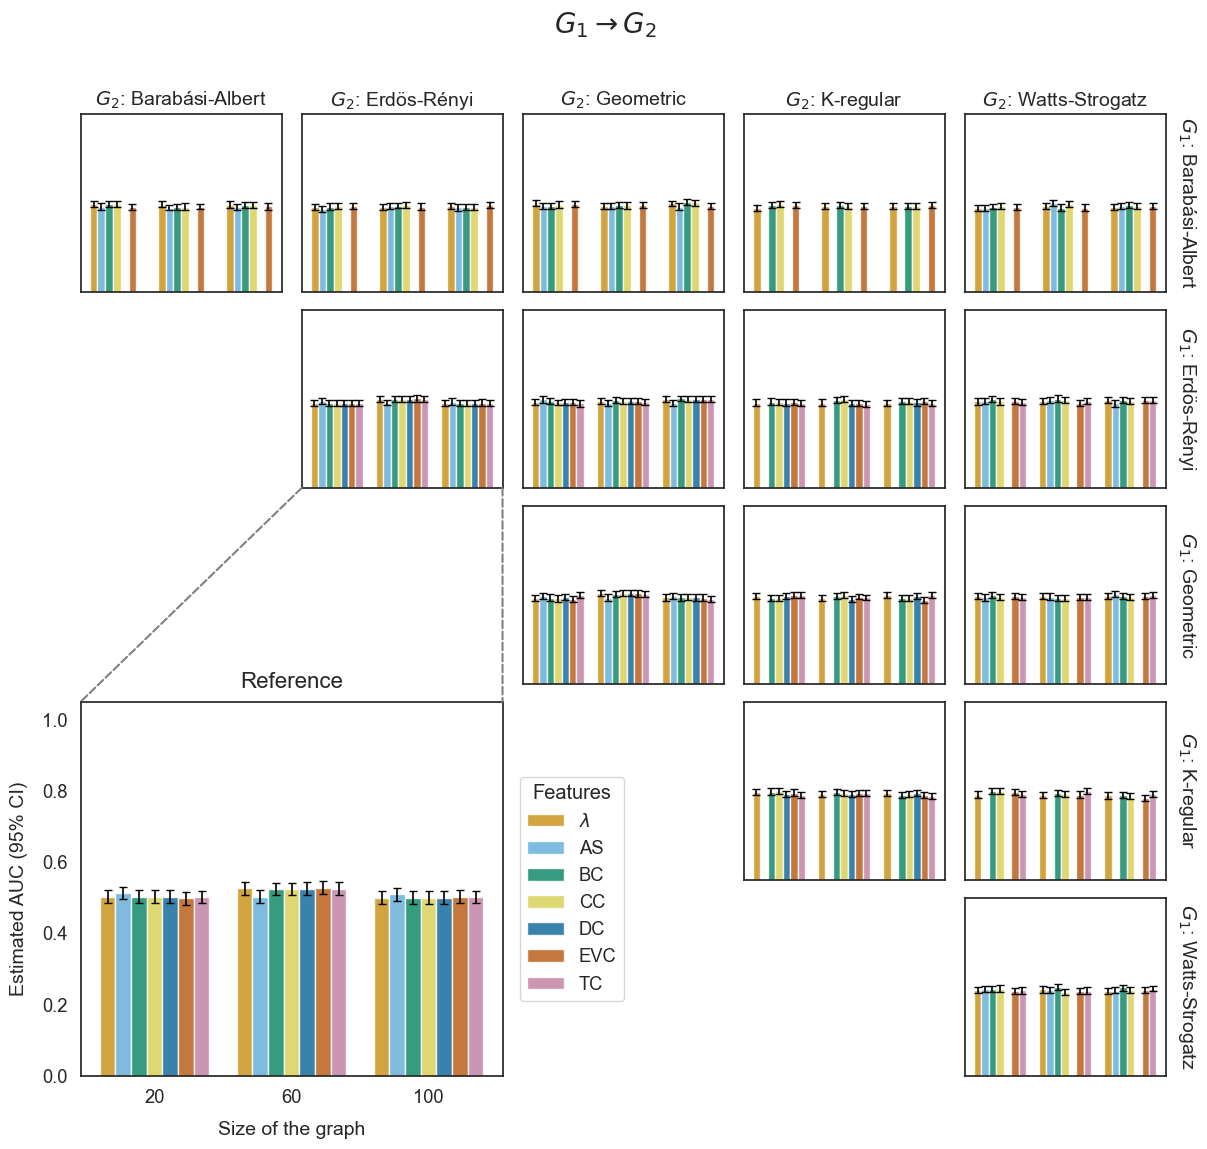

Gráfico para a direção A->B salvo em: ..\dados\resultados\sim\Caso_1\auc_features_uniform_A_to_B_R50_rank.pdf


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
from cycler import cycler
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as patches_mpl

minha_paleta = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
plt.rcParams['axes.prop_cycle'] = cycler(color=minha_paleta)
sns.set_theme(style="white", font_scale=1.2)
sns.set_palette(minha_paleta)

def calcular_area_poder(p_valores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    poderes = np.array([np.mean(p_valores <= t) for t in thresholds])
    return auc(thresholds, poderes)

def bootstrap_power_area(p_valores, n_bootstraps=1000, alpha_ic=0.05):
    p_valores = np.array(p_valores)
    n_amostras = len(p_valores)
    
    estimativa_real = calcular_area_poder(p_valores)
    
    areas_bootstrap = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        amostra_p = rng.choice(p_valores, size=n_amostras, replace=True)
        area = calcular_area_poder(amostra_p)
        areas_bootstrap.append(area)
        
    areas_bootstrap = np.array(areas_bootstrap)
    areas_bootstrap.sort()
    
    lower_bound = np.percentile(areas_bootstrap, (alpha_ic / 2) * 100)
    upper_bound = np.percentile(areas_bootstrap, (1 - alpha_ic / 2) * 100)
    
    return estimativa_real, lower_bound, upper_bound

# ==========================================
# 2. LEITURA E MAPEAMENTO DOS DADOS
# ==========================================

caso = "Caso_1"
ruido = "uniform"
path = os.path.join("..", "dados", "resultados", "sim", caso, "p_valores_rank.csv") 
n_boots = 1000
df_full = pd.read_csv(path)

# Renomear colunas para o padrão
df_full = df_full.rename(columns={
    'Vertices': 'N',
    'Direcao': 'Direction',
    'p_valor': 'p_value'
})

# ---> FILTRO ADICIONADO AQUI: Seleciona apenas os dados onde R é 50 <---
df_full = df_full[df_full['R'] == 50].copy()

# Separar a coluna 'Modelo' em G1 e G2
df_full[['Model_G1', 'Model_G2']] = df_full['Modelo'].apply(
    lambda x: pd.Series(x.split('-') if '-' in str(x) else [x, x])
)

modelos_quero = ["barabasi_albert", "erdos_renyi", "geometric", "k_regular", "watts_strogatz"]

df_full = df_full[
    df_full["Model_G1"].isin(modelos_quero) & 
    df_full["Model_G2"].isin(modelos_quero)
].reset_index(drop=True)

mapa_topologia = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_direcao = {
    'A->B': r'$G_1 \rightarrow G_2$',
    'B->A': r'$G_2 \rightarrow G_1$'
}

mapa_features = {
    'Lambda': r'$\lambda$', 
    'lambda': r'$\lambda$',
    r'$\lambda$': r'$\lambda$',
    r'$\lambda_1$': r'$\lambda$'
}

df_full['Model_G1'] = df_full['Model_G1'].map(mapa_topologia).fillna(df_full['Model_G1'])
df_full['Model_G2'] = df_full['Model_G2'].map(mapa_topologia).fillna(df_full['Model_G2'])
df_full['Direction_Raw'] = df_full['Direction']
df_full['Direction'] = df_full['Direction'].map(mapa_direcao).fillna(df_full['Direction'])
df_full['Feature'] = df_full['Feature'].replace(mapa_features)
df_full['N'] = df_full['N'].astype(int)

# ==========================================
# 3. PROCESSAMENTO VIA BOOTSTRAP
# ==========================================
final_results = []
print("Calculating Estimations and CI for all scenarios. This might take a few seconds...")

for (mod1, mod2, n_nodes, feature, direction, dir_raw), group in df_full.groupby(['Model_G1', 'Model_G2', 'N', 'Feature', 'Direction', 'Direction_Raw']):
    experiment_p_values = pd.to_numeric(group['p_value'], errors='coerce').dropna().values
    
    if len(experiment_p_values) == 0:
        continue
        
    estimativa, lower, upper = bootstrap_power_area(experiment_p_values, n_bootstraps=n_boots)
    
    final_results.append({
        'Model_G1': mod1, 'Model_G2': mod2, 'N': n_nodes, 'Feature': feature,
        'Direction': direction, 'Direction_Raw': dir_raw,
        'Area_Estimate': estimativa, 
        'Err_Lower': estimativa - lower, 
        'Err_Upper': upper - estimativa
    })

df_plot = pd.DataFrame(final_results)
df_plot = df_plot.sort_values(by=['Model_G1', 'Model_G2', 'Direction', 'Feature', 'N'])

# ==========================================
# 4. PLOTAGEM (MATRIZ + ZOOM NO VÃO)
# ==========================================
print("Generating Matrix Plot with strict numerical positioning...")
path_figuras = os.path.join("..", "dados", "resultados", "sim", caso)
os.makedirs(path_figuras, exist_ok=True)

# Definição estrita das categorias (mantém o plot e as barras de erro sincronizados)
global_order_x = sorted(df_plot['N'].unique())
features_ordem = [r'$\lambda$', 'AS', 'BC', 'CC', 'DC', 'EVC', 'TC']

def plot_bars_manual(ax, data, x, y, err_inf, err_sup, hue, hue_order, legend=False):
    if data.empty:
        return
        
    sns.barplot(
        x=x, y=y, hue=hue, data=data, 
        ax=ax, alpha=0.85, 
        order=global_order_x, hue_order=hue_order,
        palette=minha_paleta
    )
    
    if not legend and ax.legend_ is not None:
        ax.legend_.remove()
    elif legend:
        sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), title="Features")
        
    x_coords, y_coords, y_errs_inf, y_errs_sup = [], [], [], []
    
    # Seaborn usa 0.8 como largura total dos blocos num group barplot por padrão.
    H = len(hue_order)
    w = 0.8 / H
    
    # Cálculo matemático para encontrar a coordenada exata de cada erro
    for h_idx, feature in enumerate(hue_order):
        offset = -0.4 + (w / 2.0) + (h_idx * w)
        
        for x_idx, x_val in enumerate(global_order_x):
            exact_x = x_idx + offset
            
            subset = data[(data[hue] == feature) & (data[x] == x_val)]
            if not subset.empty:
                y_val = subset[y].values[0]
                # Apenas vincula erro e plotagem se não for um NaN/Null
                if pd.notnull(y_val):
                    x_coords.append(exact_x)
                    y_coords.append(y_val)
                    y_errs_inf.append(subset[err_inf].values[0])
                    y_errs_sup.append(subset[err_sup].values[0])

    if x_coords:
        ax.errorbar(
            x=x_coords, 
            y=y_coords, 
            yerr=[y_errs_inf, y_errs_sup], 
            fmt='none', c='black', capsize=3, linewidth=1.2
        )

modelos_labels = [mapa_topologia[m] for m in modelos_quero] 

for dir_raw in df_plot['Direction_Raw'].unique():
    df_dir_plot = df_plot[df_plot['Direction_Raw'] == dir_raw]
    titulo_dir = df_dir_plot['Direction'].iloc[0]
    
    fig = plt.figure(figsize=(14, 13))
    gs = fig.add_gridspec(5, 5)
    axes_matrix = {}
    
    for i, mod1 in enumerate(modelos_labels):
        for j, mod2 in enumerate(modelos_labels):
            
            if i >= 3 and j <= 1:
                continue
                
            ax = fig.add_subplot(gs[i, j])
            axes_matrix[(i, j)] = ax
            
            subset = df_dir_plot[(df_dir_plot['Model_G1'] == mod1) & (df_dir_plot['Model_G2'] == mod2)]
            if subset.empty:
                ax.set_visible(False)
                continue
                
            plot_bars_manual(ax, subset, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "Feature", features_ordem, legend=False)
            
            ax.set_ylim(0, 1.05)
            ax.set_xlabel("")
            ax.set_ylabel("")
            
            if i == 0:
                ax.set_title(fr"$G_2$: {mod2}", fontsize=14)
            if j == len(modelos_labels) - 1:
                ax.text(1.05, 0.5, fr"$G_1$: {mod1}", rotation=270, va='center', ha='left', transform=ax.transAxes, fontsize=14)
            
            hide_x = False
            hide_y = False
            
            if i < len(modelos_labels) - 1 and (i, j) not in [(2, 0), (2, 1)]: 
                hide_x = True
            if j > 0 and not (j == 2 and i >= 3): 
                hide_y = True
                
            if (i, j) == (0, 0) or (i, j) == (len(modelos_labels) - 1, len(modelos_labels) - 1):
                hide_x = True
                hide_y = True

            if hide_x:
                ax.set_xticklabels([])
            if hide_y:
                ax.set_yticklabels([])

    zoom_i, zoom_j = None, None
    subset_ref = pd.DataFrame()
    
    ordem_busca = [(2, 1), (2, 0), (1, 1), (1, 0), (2, 2), (1, 2), (0, 0), (0, 1)]
    for i, j in ordem_busca:
        mod_1, mod_2 = modelos_labels[i], modelos_labels[j]
        temp_subset = df_dir_plot[(df_dir_plot['Model_G1'] == mod_1) & (df_dir_plot['Model_G2'] == mod_2)]
        if not temp_subset.empty:
            zoom_i, zoom_j = i, j
            subset_ref = temp_subset
            break
            
    if subset_ref.empty:
        zoom_i, zoom_j = 0, 0
        mod_1, mod_2 = modelos_labels[0], modelos_labels[0]
        subset_ref = df_dir_plot[(df_dir_plot['Model_G1'] == mod_1) & (df_dir_plot['Model_G2'] == mod_2)]
    
    ax_ref = fig.add_subplot(gs[3:5, 0:2])
    
    plot_bars_manual(ax_ref, subset_ref, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "Feature", features_ordem, legend=True)
    
    ax_ref.set_ylim(0, 1.05)
    ax_ref.set_xlabel("Size of the graph", fontsize=14, labelpad=10)
    ax_ref.set_ylabel("Estimated AUC (95% CI)", fontsize=14, labelpad=10)
    ax_ref.set_title(fr"Reference", fontsize=16, pad=10)
    
    if (zoom_i, zoom_j) in axes_matrix:
        ax_src = axes_matrix[(zoom_i, zoom_j)]
        
        con1 = ConnectionPatch(xyA=(0, 0), xyB=(0, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con1.set_clip_on(False)
        
        con2 = ConnectionPatch(xyA=(1, 0), xyB=(1, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con2.set_clip_on(False)
        
        fig.add_artist(con1)
        fig.add_artist(con2)
    
    fig.suptitle(titulo_dir, fontsize=20, y=0.93)
        
    plt.subplots_adjust(top=0.85, hspace=0.1, wspace=0.1) 
    plt.show()

    dir_nome_seguro = str(dir_raw).replace('->', '_to_')
    nome_arquivo = f"auc_features_{ruido}_{dir_nome_seguro}_R50_rank.pdf"
    
    fig.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
    print(f"Gráfico para a direção {dir_raw} salvo em: {os.path.join(path_figuras, nome_arquivo)}")

#### Caso 2

Calculating Estimations and CI for all scenarios. This might take a few seconds...
Generating Matrix Plot with strict numerical positioning...


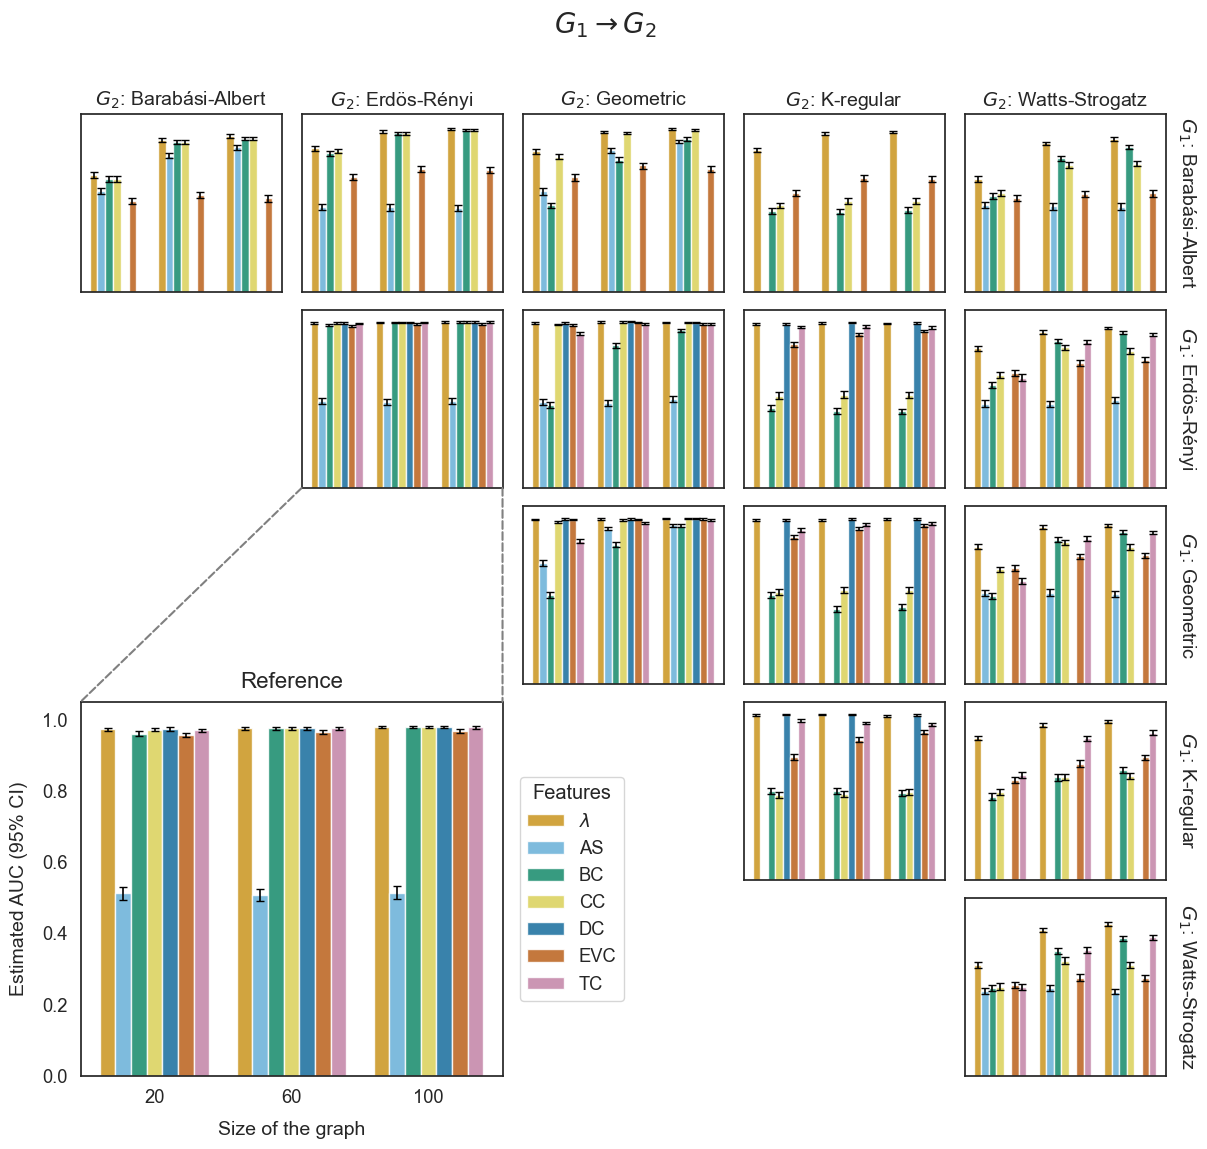

Gráfico para a direção A->B salvo em: ..\dados\resultados\sim\Caso_2\auc_features_uniform_A_to_B_R50_rank.pdf


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
from cycler import cycler
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as patches_mpl

minha_paleta = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
plt.rcParams['axes.prop_cycle'] = cycler(color=minha_paleta)
sns.set_theme(style="white", font_scale=1.2)
sns.set_palette(minha_paleta)

def calcular_area_poder(p_valores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    poderes = np.array([np.mean(p_valores <= t) for t in thresholds])
    return auc(thresholds, poderes)

def bootstrap_power_area(p_valores, n_bootstraps=1000, alpha_ic=0.05):
    p_valores = np.array(p_valores)
    n_amostras = len(p_valores)
    
    estimativa_real = calcular_area_poder(p_valores)
    
    areas_bootstrap = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        amostra_p = rng.choice(p_valores, size=n_amostras, replace=True)
        area = calcular_area_poder(amostra_p)
        areas_bootstrap.append(area)
        
    areas_bootstrap = np.array(areas_bootstrap)
    areas_bootstrap.sort()
    
    lower_bound = np.percentile(areas_bootstrap, (alpha_ic / 2) * 100)
    upper_bound = np.percentile(areas_bootstrap, (1 - alpha_ic / 2) * 100)
    
    return estimativa_real, lower_bound, upper_bound

# ==========================================
# 2. LEITURA E MAPEAMENTO DOS DADOS
# ==========================================

caso = "Caso_2"
ruido = "uniform"
path = os.path.join("..", "dados", "resultados", "sim", caso, "p_valores_rank.csv") 
n_boots = 1000
df_full = pd.read_csv(path)

# Renomear colunas para o padrão
df_full = df_full.rename(columns={
    'Vertices': 'N',
    'Direcao': 'Direction',
    'p_valor': 'p_value'
})

# ---> FILTRO ADICIONADO AQUI: Seleciona apenas os dados onde R é 50 <---
df_full = df_full[df_full['R'] == 50].copy()

# Separar a coluna 'Modelo' em G1 e G2
df_full[['Model_G1', 'Model_G2']] = df_full['Modelo'].apply(
    lambda x: pd.Series(x.split('-') if '-' in str(x) else [x, x])
)

modelos_quero = ["barabasi_albert", "erdos_renyi", "geometric", "k_regular", "watts_strogatz"]

df_full = df_full[
    df_full["Model_G1"].isin(modelos_quero) & 
    df_full["Model_G2"].isin(modelos_quero)
].reset_index(drop=True)

mapa_topologia = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_direcao = {
    'A->B': r'$G_1 \rightarrow G_2$',
    'B->A': r'$G_2 \rightarrow G_1$'
}

mapa_features = {
    'Lambda': r'$\lambda$', 
    'lambda': r'$\lambda$',
    r'$\lambda$': r'$\lambda$',
    r'$\lambda_1$': r'$\lambda$'
}

df_full['Model_G1'] = df_full['Model_G1'].map(mapa_topologia).fillna(df_full['Model_G1'])
df_full['Model_G2'] = df_full['Model_G2'].map(mapa_topologia).fillna(df_full['Model_G2'])
df_full['Direction_Raw'] = df_full['Direction']
df_full['Direction'] = df_full['Direction'].map(mapa_direcao).fillna(df_full['Direction'])
df_full['Feature'] = df_full['Feature'].replace(mapa_features)
df_full['N'] = df_full['N'].astype(int)

# ==========================================
# 3. PROCESSAMENTO VIA BOOTSTRAP
# ==========================================
final_results = []
print("Calculating Estimations and CI for all scenarios. This might take a few seconds...")

for (mod1, mod2, n_nodes, feature, direction, dir_raw), group in df_full.groupby(['Model_G1', 'Model_G2', 'N', 'Feature', 'Direction', 'Direction_Raw']):
    experiment_p_values = pd.to_numeric(group['p_value'], errors='coerce').dropna().values
    
    if len(experiment_p_values) == 0:
        continue
        
    estimativa, lower, upper = bootstrap_power_area(experiment_p_values, n_bootstraps=n_boots)
    
    final_results.append({
        'Model_G1': mod1, 'Model_G2': mod2, 'N': n_nodes, 'Feature': feature,
        'Direction': direction, 'Direction_Raw': dir_raw,
        'Area_Estimate': estimativa, 
        'Err_Lower': estimativa - lower, 
        'Err_Upper': upper - estimativa
    })

df_plot = pd.DataFrame(final_results)
df_plot = df_plot.sort_values(by=['Model_G1', 'Model_G2', 'Direction', 'Feature', 'N'])

# ==========================================
# 4. PLOTAGEM (MATRIZ + ZOOM NO VÃO)
# ==========================================
print("Generating Matrix Plot with strict numerical positioning...")
path_figuras = os.path.join("..", "dados", "resultados", "sim", caso)
os.makedirs(path_figuras, exist_ok=True)

# Definição estrita das categorias (mantém o plot e as barras de erro sincronizados)
global_order_x = sorted(df_plot['N'].unique())
features_ordem = [r'$\lambda$', 'AS', 'BC', 'CC', 'DC', 'EVC', 'TC']

def plot_bars_manual(ax, data, x, y, err_inf, err_sup, hue, hue_order, legend=False):
    if data.empty:
        return
        
    sns.barplot(
        x=x, y=y, hue=hue, data=data, 
        ax=ax, alpha=0.85, 
        order=global_order_x, hue_order=hue_order,
        palette=minha_paleta
    )
    
    if not legend and ax.legend_ is not None:
        ax.legend_.remove()
    elif legend:
        sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), title="Features")
        
    x_coords, y_coords, y_errs_inf, y_errs_sup = [], [], [], []
    
    # Seaborn usa 0.8 como largura total dos blocos num group barplot por padrão.
    H = len(hue_order)
    w = 0.8 / H
    
    # Cálculo matemático para encontrar a coordenada exata de cada erro
    for h_idx, feature in enumerate(hue_order):
        offset = -0.4 + (w / 2.0) + (h_idx * w)
        
        for x_idx, x_val in enumerate(global_order_x):
            exact_x = x_idx + offset
            
            subset = data[(data[hue] == feature) & (data[x] == x_val)]
            if not subset.empty:
                y_val = subset[y].values[0]
                # Apenas vincula erro e plotagem se não for um NaN/Null
                if pd.notnull(y_val):
                    x_coords.append(exact_x)
                    y_coords.append(y_val)
                    y_errs_inf.append(subset[err_inf].values[0])
                    y_errs_sup.append(subset[err_sup].values[0])

    if x_coords:
        ax.errorbar(
            x=x_coords, 
            y=y_coords, 
            yerr=[y_errs_inf, y_errs_sup], 
            fmt='none', c='black', capsize=3, linewidth=1.2
        )

modelos_labels = [mapa_topologia[m] for m in modelos_quero] 

for dir_raw in df_plot['Direction_Raw'].unique():
    df_dir_plot = df_plot[df_plot['Direction_Raw'] == dir_raw]
    titulo_dir = df_dir_plot['Direction'].iloc[0]
    
    fig = plt.figure(figsize=(14, 13))
    gs = fig.add_gridspec(5, 5)
    axes_matrix = {}
    
    for i, mod1 in enumerate(modelos_labels):
        for j, mod2 in enumerate(modelos_labels):
            
            if i >= 3 and j <= 1:
                continue
                
            ax = fig.add_subplot(gs[i, j])
            axes_matrix[(i, j)] = ax
            
            subset = df_dir_plot[(df_dir_plot['Model_G1'] == mod1) & (df_dir_plot['Model_G2'] == mod2)]
            if subset.empty:
                ax.set_visible(False)
                continue
                
            plot_bars_manual(ax, subset, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "Feature", features_ordem, legend=False)
            
            ax.set_ylim(0, 1.05)
            ax.set_xlabel("")
            ax.set_ylabel("")
            
            if i == 0:
                ax.set_title(fr"$G_2$: {mod2}", fontsize=14)
            if j == len(modelos_labels) - 1:
                ax.text(1.05, 0.5, fr"$G_1$: {mod1}", rotation=270, va='center', ha='left', transform=ax.transAxes, fontsize=14)
            
            hide_x = False
            hide_y = False
            
            if i < len(modelos_labels) - 1 and (i, j) not in [(2, 0), (2, 1)]: 
                hide_x = True
            if j > 0 and not (j == 2 and i >= 3): 
                hide_y = True
                
            if (i, j) == (0, 0) or (i, j) == (len(modelos_labels) - 1, len(modelos_labels) - 1):
                hide_x = True
                hide_y = True

            if hide_x:
                ax.set_xticklabels([])
            if hide_y:
                ax.set_yticklabels([])

    zoom_i, zoom_j = None, None
    subset_ref = pd.DataFrame()
    
    ordem_busca = [(2, 1), (2, 0), (1, 1), (1, 0), (2, 2), (1, 2), (0, 0), (0, 1)]
    for i, j in ordem_busca:
        mod_1, mod_2 = modelos_labels[i], modelos_labels[j]
        temp_subset = df_dir_plot[(df_dir_plot['Model_G1'] == mod_1) & (df_dir_plot['Model_G2'] == mod_2)]
        if not temp_subset.empty:
            zoom_i, zoom_j = i, j
            subset_ref = temp_subset
            break
            
    if subset_ref.empty:
        zoom_i, zoom_j = 0, 0
        mod_1, mod_2 = modelos_labels[0], modelos_labels[0]
        subset_ref = df_dir_plot[(df_dir_plot['Model_G1'] == mod_1) & (df_dir_plot['Model_G2'] == mod_2)]
    
    ax_ref = fig.add_subplot(gs[3:5, 0:2])
    
    plot_bars_manual(ax_ref, subset_ref, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "Feature", features_ordem, legend=True)
    
    ax_ref.set_ylim(0, 1.05)
    ax_ref.set_xlabel("Size of the graph", fontsize=14, labelpad=10)
    ax_ref.set_ylabel("Estimated AUC (95% CI)", fontsize=14, labelpad=10)
    ax_ref.set_title(fr"Reference", fontsize=16, pad=10)
    
    if (zoom_i, zoom_j) in axes_matrix:
        ax_src = axes_matrix[(zoom_i, zoom_j)]
        
        con1 = ConnectionPatch(xyA=(0, 0), xyB=(0, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con1.set_clip_on(False)
        
        con2 = ConnectionPatch(xyA=(1, 0), xyB=(1, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con2.set_clip_on(False)
        
        fig.add_artist(con1)
        fig.add_artist(con2)
    
    fig.suptitle(titulo_dir, fontsize=20, y=0.93)
        
    plt.subplots_adjust(top=0.85, hspace=0.1, wspace=0.1) 
    plt.show()

    nome_arquivo = f"auc_features_{ruido}_R50_rank.pdf"
    
    fig.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
    print(f"Gráfico para a direção {dir_raw} salvo em: {os.path.join(path_figuras, nome_arquivo)}")

#### Caso 3

Calculating Estimations and CI for all scenarios. This might take a few seconds...
Generating FacetGrid plot...


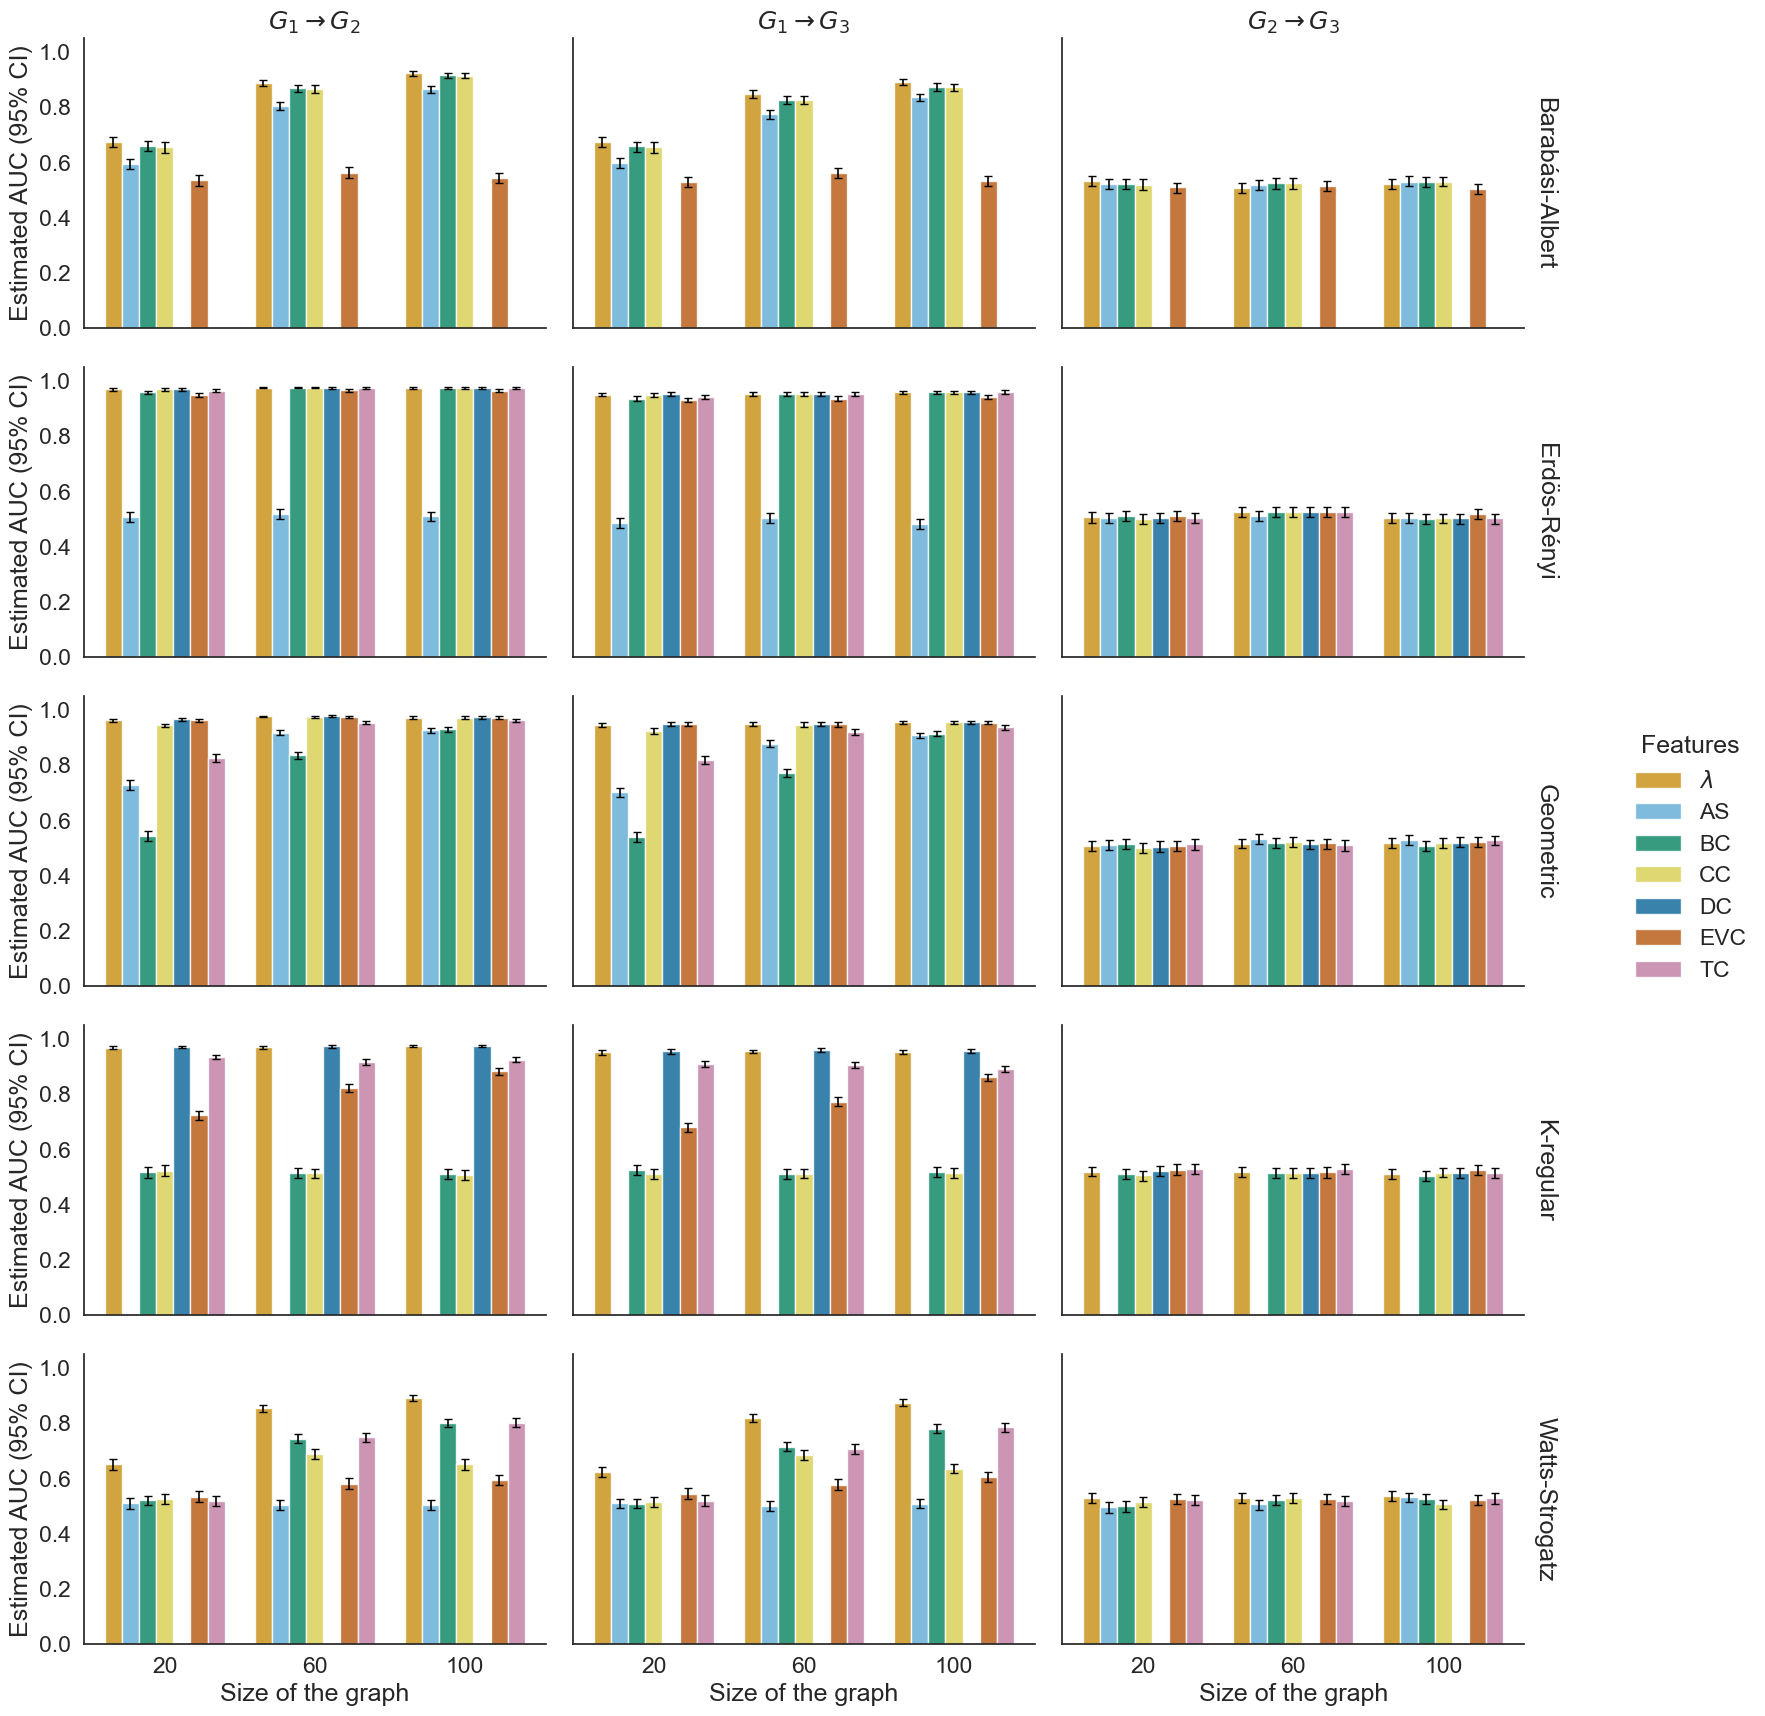

Gráfico salvo com sucesso em: ..\dados\resultados\sim\Caso_3\auc_features_uniform_barras_R50_rank.pdf


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
from cycler import cycler

minha_paleta = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
plt.rcParams['axes.prop_cycle'] = cycler(color=minha_paleta)
sns.set_theme(style="white", font_scale=1.5)
sns.set_palette(minha_paleta)

# ==========================================
# 1. FUNÇÕES DE CÁLCULO E BOOTSTRAP
# ==========================================

def calcular_area_poder(p_valores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    poderes = np.array([np.mean(p_valores <= t) for t in thresholds])
    return auc(thresholds, poderes)

def bootstrap_power_area(p_valores, n_bootstraps=1000, alpha_ic=0.05):
    p_valores = np.array(p_valores)
    n_amostras = len(p_valores)
    
    # Estimativa exata sem bootstrap para a altura da barra
    estimativa_real = calcular_area_poder(p_valores)
    
    areas_bootstrap = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        amostra_p = rng.choice(p_valores, size=n_amostras, replace=True)
        areas_bootstrap.append(calcular_area_poder(amostra_p))
        
    areas_bootstrap = np.array(areas_bootstrap)
    areas_bootstrap.sort()
    
    # Bootstrap utilizado apenas para os limites de confiança
    lower_bound = np.percentile(areas_bootstrap, (alpha_ic / 2) * 100)
    upper_bound = np.percentile(areas_bootstrap, (1 - alpha_ic / 2) * 100)
    
    return estimativa_real, lower_bound, upper_bound

# ==========================================
# 2. LEITURA E MAPEAMENTO DOS DADOS
# ==========================================

caso = "Caso_3"
ruido = "uniform"

# Caminho para o dataframe único
path = os.path.join("..", "dados", "resultados", "sim", caso, "p_valores_rank.csv") 
df_full = pd.read_csv(path)

# Renomeando colunas e filtrando R = 50
df_full = df_full.rename(columns={
    'Modelo': 'Topology',
    'Vertices': 'N',
    'Aresta': 'Direction',
    'p_valor': 'p_value'
})
df_full = df_full[df_full['R'] == 50].copy()

# Como queremos apenas os grafos onde os 3 são iguais, mantemos a lógica de buscar o nome base
modelos_quero = ["barabasi_albert", "erdos_renyi", "geometric", "k_regular", "watts_strogatz"]
df_full = df_full[df_full["Topology"].isin(modelos_quero)].reset_index(drop=True)

mapa_topologia = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_direcao = {
    'A->B': r'$G_1 \rightarrow G_2$',
    'A->C': r'$G_1 \rightarrow G_3$',
    'B->C': r'$G_2 \rightarrow G_3$' 
}

mapa_features = {
    'Lambda': r'$\lambda$', 
    'lambda': r'$\lambda$',
    r'$\lambda$': r'$\lambda$',
    r'$\lambda_1$': r'$\lambda$'
}

df_full['Topology'] = df_full['Topology'].map(mapa_topologia).fillna(df_full['Topology'])
df_full['Direction'] = df_full['Direction'].map(mapa_direcao).fillna(df_full['Direction'])
df_full['Feature'] = df_full['Feature'].replace(mapa_features)
df_full['N'] = df_full['N'].astype(int)

# ==========================================
# 3. PROCESSAMENTO VIA BOOTSTRAP
# ==========================================
final_results = []
print("Calculating Estimations and CI for all scenarios. This might take a few seconds...")

for (topology, n_nodes, feature, direction), group in df_full.groupby(['Topology', 'N', 'Feature', 'Direction']):
    experiment_p_values = pd.to_numeric(group['p_value'], errors='coerce').dropna().values
    
    if len(experiment_p_values) == 0:
        continue
        
    estimativa, lower, upper = bootstrap_power_area(experiment_p_values, n_bootstraps=1000)
    
    final_results.append({
        'Topology': topology,
        'N': n_nodes,
        'Feature': feature,
        'Direction': direction,
        'Area_Estimate': estimativa,
        'Err_Lower': estimativa - lower,
        'Err_Upper': upper - estimativa
    })

df_plot = pd.DataFrame(final_results)

# ==========================================
# 4. ORDENAÇÃO E PLOTAGEM
# ==========================================

# Garantindo a ordem correta das direções
ordem_direcoes = [r'$G_1 \rightarrow G_2$', r'$G_1 \rightarrow G_3$', r'$G_2 \rightarrow G_3$']
ordem_direcoes_presentes = [d for d in ordem_direcoes if d in df_plot['Direction'].values]
df_plot['Direction'] = pd.Categorical(df_plot['Direction'], categories=ordem_direcoes_presentes, ordered=True)

df_plot = df_plot.sort_values(by=['Topology', 'Direction', 'Feature', 'N'])

# Definição estrita de ordenação para as coordenadas X e Hue
global_order_x = sorted(df_plot['N'].unique())
todas_features = [r'$\lambda$', 'AS', 'BC', 'CC', 'DC', 'EVC', 'TC']
global_hue_order = [f for f in todas_features if f in df_plot['Feature'].unique()]

print("Generating FacetGrid plot...")

g = sns.FacetGrid(df_plot, row="Topology", col="Direction", margin_titles=True, height=3.5, aspect=1.4)
g.set_titles(col_template="{col_name}", row_template="{row_name}")

def plot_bars_with_ic(x, y, err_inf, err_sup, hue, **kwargs):
    ax = plt.gca()
    data = kwargs.pop("data")
    
    sns.barplot(
        x=x, y=y, hue=hue, data=data, 
        ax=ax, alpha=0.85, 
        hue_order=global_hue_order, 
        order=global_order_x, 
        **kwargs
    )
    
    x_coords, y_coords, y_errs_inf, y_errs_sup = [], [], [], []
    
    # Cálculo matemático para posicionar a barra de erro perfeitamente
    H = len(global_hue_order)
    w = 0.8 / H
    
    for h_idx, feature in enumerate(global_hue_order):
        offset = -0.4 + (w / 2.0) + (h_idx * w)
        
        for x_idx, x_val in enumerate(global_order_x):
            exact_x = x_idx + offset
            subset = data[(data[hue] == feature) & (data[x] == x_val)]
            
            if not subset.empty:
                y_val = subset[y].values[0]
                if pd.notnull(y_val):
                    x_coords.append(exact_x)
                    y_coords.append(y_val)
                    y_errs_inf.append(subset[err_inf].values[0])
                    y_errs_sup.append(subset[err_sup].values[0])
                    
    if x_coords:
        ax.errorbar(
            x=x_coords, 
            y=y_coords, 
            yerr=[y_errs_inf, y_errs_sup], 
            fmt='none', 
            c='black', 
            capsize=3, 
            linewidth=1.2
        )

# Mapeia os dados usando a Area_Estimate para a altura da barra
g.map_dataframe(plot_bars_with_ic, x="N", y="Area_Estimate", err_inf="Err_Lower", err_sup="Err_Upper", hue="Feature", palette=minha_paleta)

g.set_axis_labels("Size of the graph", "Estimated AUC (95% CI)")
g.add_legend(title="Features", bbox_to_anchor=(1.02, 0.5), loc='center left')

for ax in g.axes.flat:
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ==========================================
# 5. SALVAR ARQUIVO PDF
# ==========================================
nome_arquivo = f"auc_features_{ruido}_barras_R50_rank.pdf"
path_figuras = os.path.join("..", "dados", "resultados", "sim", caso)
os.makedirs(path_figuras, exist_ok=True)
g.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {os.path.join(path_figuras, nome_arquivo)}")

### Plot Bootrstrap AUC -  Ao longo do tamanho da amostra

#### Caso 1

Calculating Estimations and CI for all scenarios. This might take a few seconds...
Generating Matrix Plot with strict numerical positioning...


C:\Users\caios\AppData\Local\Temp\ipykernel_44756\2094846446.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\2094846446.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\2094846446.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\2094846446.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\2094846446.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\2094846446.py:136: UserWarning: The palette list has more va

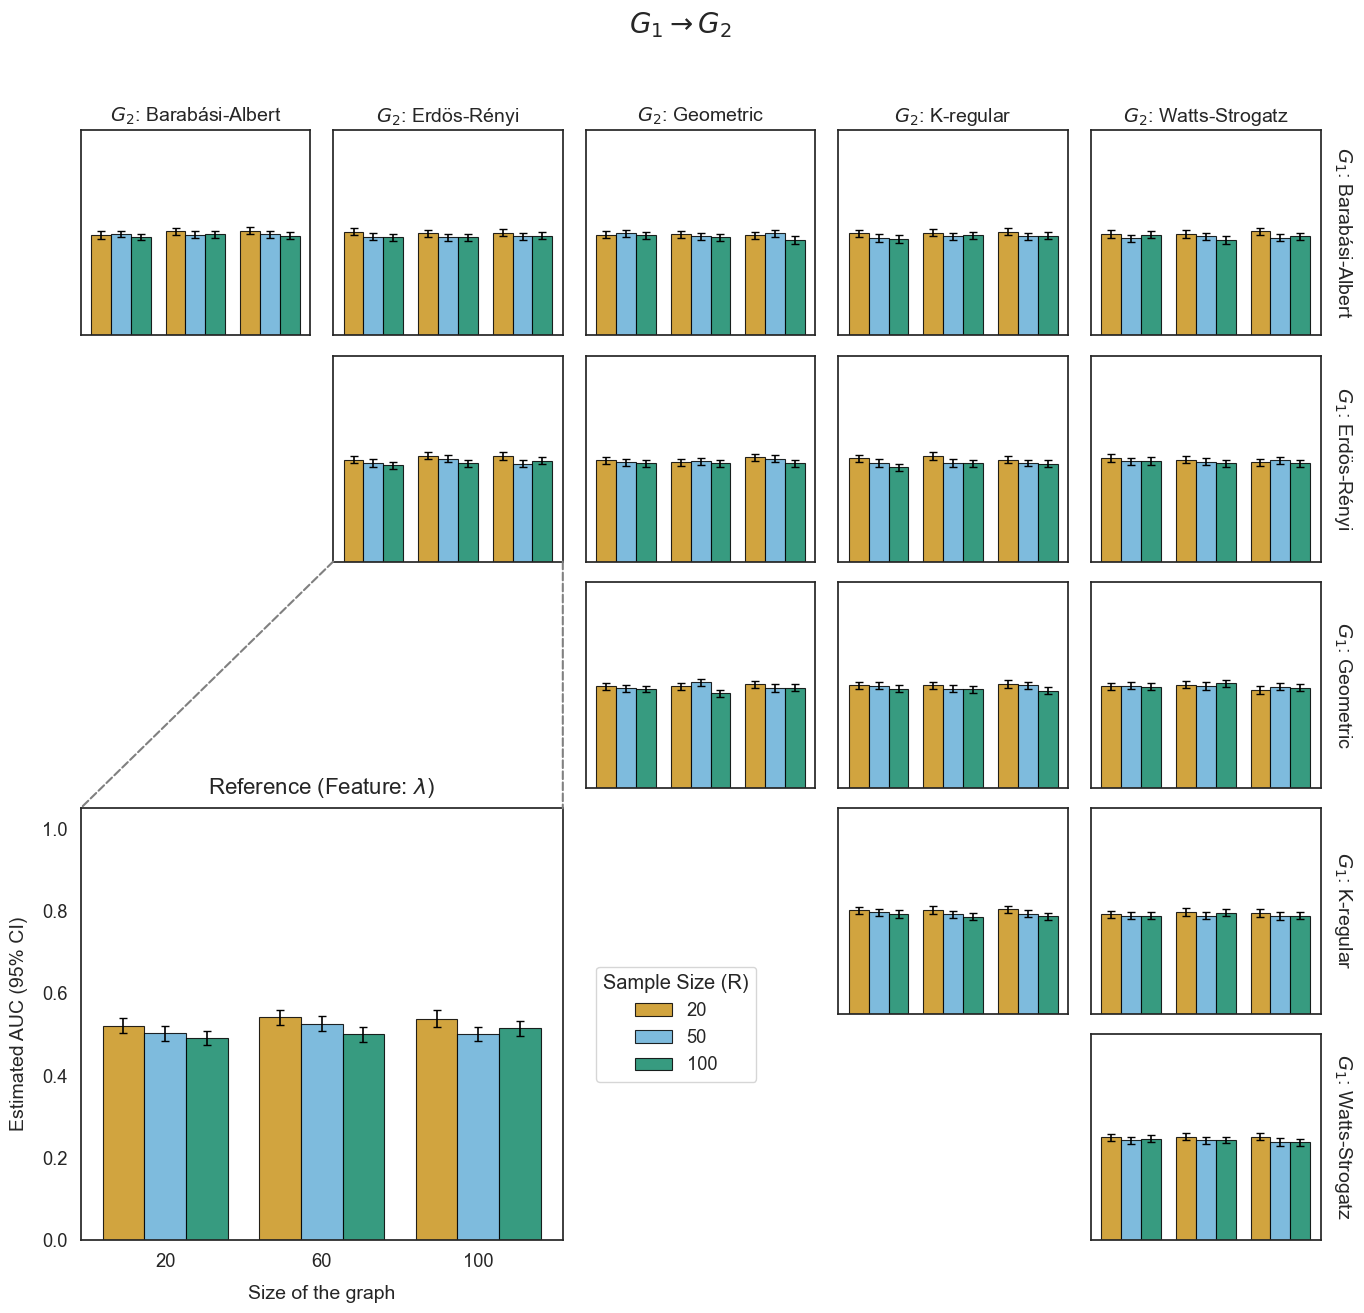

Gráfico salvo com sucesso em: ..\dados\resultados\sim\Caso_1\auc_R_lambda_A_to_B_rank.pdf


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
from cycler import cycler
from matplotlib.patches import ConnectionPatch

minha_paleta = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
plt.rcParams['axes.prop_cycle'] = cycler(color=minha_paleta)
sns.set_theme(style="white", font_scale=1.2)
sns.set_palette(minha_paleta)

def calcular_area_poder(p_valores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    poderes = np.array([np.mean(p_valores <= t) for t in thresholds])
    return auc(thresholds, poderes)

def bootstrap_power_area(p_valores, n_bootstraps=1000, alpha_ic=0.05):
    p_valores = np.array(p_valores)
    n_amostras = len(p_valores)
    
    estimativa_real = calcular_area_poder(p_valores)
    
    areas_bootstrap = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        amostra_p = rng.choice(p_valores, size=n_amostras, replace=True)
        areas_bootstrap.append(calcular_area_poder(amostra_p))
        
    areas_bootstrap = np.array(areas_bootstrap)
    areas_bootstrap.sort()
    
    lower_bound = np.percentile(areas_bootstrap, (alpha_ic / 2) * 100)
    upper_bound = np.percentile(areas_bootstrap, (1 - alpha_ic / 2) * 100)
    
    return estimativa_real, lower_bound, upper_bound

# ==========================================
# 1. TRATAMENTO DO DATAFRAME EM MEMÓRIA
# ==========================================
# Faz uma cópia de segurança renomeando as colunas
caso = "Caso_1"
ruido = "uniform"

# Caminho para o dataframe único
path = os.path.join("..", "dados", "resultados", "sim", caso, "p_valores_rank.csv") 
df_full = pd.read_csv(path)

df_tratado = df_full.rename(columns={
    'Vertices': 'N',
    'Direcao': 'Direction',
    'p_valor': 'p_value'
}).copy()

# Filtra APENAS a feature de raio espectral (lambda)
features_espectrais = ['Lambda', 'lambda', r'$\lambda$', r'$\lambda_1$']
df_tratado = df_tratado[df_tratado['Feature'].isin(features_espectrais)].copy()

# Separa a coluna 'Modelo' em G1 e G2
df_tratado[['Model_G1', 'Model_G2']] = df_tratado['Modelo'].apply(
    lambda x: pd.Series(x.split('-') if '-' in str(x) else [x, x])
)

modelos_quero = ["barabasi_albert", "erdos_renyi", "geometric", "k_regular", "watts_strogatz"]
df_tratado = df_tratado[
    df_tratado["Model_G1"].isin(modelos_quero) & 
    df_tratado["Model_G2"].isin(modelos_quero)
].reset_index(drop=True)

mapa_topologia = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_direcao = {
    'A->B': r'$G_1 \rightarrow G_2$',
    'B->A': r'$G_2 \rightarrow G_1$',
    'A->C': r'$G_1 \rightarrow G_3$',
    'B->C': r'$G_2 \rightarrow G_3$'
}

df_tratado['Model_G1'] = df_tratado['Model_G1'].map(mapa_topologia).fillna(df_tratado['Model_G1'])
df_tratado['Model_G2'] = df_tratado['Model_G2'].map(mapa_topologia).fillna(df_tratado['Model_G2'])
df_tratado['Direction_Raw'] = df_tratado['Direction']
df_tratado['Direction'] = df_tratado['Direction'].map(mapa_direcao).fillna(df_tratado['Direction'])

df_tratado['N'] = df_tratado['N'].astype(int)
df_tratado['R'] = df_tratado['R'].astype(int)

# ==========================================
# 2. PROCESSAMENTO VIA BOOTSTRAP
# ==========================================
final_results = []
print("Calculating Estimations and CI for all scenarios. This might take a few seconds...")

# Agrupando agora por N e R
for (mod1, mod2, n_nodes, r_samples, direction, dir_raw), group in df_tratado.groupby(['Model_G1', 'Model_G2', 'N', 'R', 'Direction', 'Direction_Raw']):
    p_vals = pd.to_numeric(group['p_value'], errors='coerce').dropna().values
    
    if len(p_vals) == 0:
        continue
        
    estimativa, lower, upper = bootstrap_power_area(p_vals, n_bootstraps=1000)
    
    final_results.append({
        'Model_G1': mod1, 'Model_G2': mod2, 'N': n_nodes, 'R': r_samples,
        'Direction': direction, 'Direction_Raw': dir_raw,
        'Area_Estimate': estimativa, 
        'Err_Lower': estimativa - lower, 
        'Err_Upper': upper - estimativa
    })

df_plot = pd.DataFrame(final_results)
df_plot = df_plot.sort_values(by=['Model_G1', 'Model_G2', 'Direction', 'N', 'R'])

# ==========================================
# 3. PLOTAGEM MATRICIAL (R NO EIXO HUE)
# ==========================================
print("Generating Matrix Plot with strict numerical positioning...")
path_figuras = os.path.join("..", "dados", "resultados", "sim", caso)
os.makedirs(path_figuras, exist_ok=True)

global_order_x = sorted(df_plot['N'].unique())
global_order_hue = sorted(df_plot['R'].unique())

def plot_bars_manual(ax, data, x, y, err_inf, err_sup, hue, hue_order, legend=False):
    if data.empty:
        return
        
    sns.barplot(
        x=x, y=y, hue=hue, data=data, 
        ax=ax, alpha=0.85, 
        order=global_order_x, hue_order=hue_order,
        palette=minha_paleta, edgecolor='black', linewidth=0.8
    )
    
    if not legend and ax.legend_ is not None:
        ax.legend_.remove()
    elif legend:
        sns.move_legend(ax, "center left", bbox_to_anchor=(1.05, 0.5), title="Sample Size (R)", frameon=True)
        
    x_coords, y_coords, y_errs_inf, y_errs_sup = [], [], [], []
    
    # Cálculo matemático para encontrar a coordenada exata de cada erro
    H = len(hue_order)
    w = 0.8 / H
    
    for h_idx, r_val in enumerate(hue_order):
        offset = -0.4 + (w / 2.0) + (h_idx * w)
        
        for x_idx, x_val in enumerate(global_order_x):
            exact_x = x_idx + offset
            
            subset = data[(data[hue] == r_val) & (data[x] == x_val)]
            if not subset.empty:
                y_val = subset[y].values[0]
                if pd.notnull(y_val):
                    x_coords.append(exact_x)
                    y_coords.append(y_val)
                    y_errs_inf.append(subset[err_inf].values[0])
                    y_errs_sup.append(subset[err_sup].values[0])

    if x_coords:
        ax.errorbar(
            x=x_coords, 
            y=y_coords, 
            yerr=[y_errs_inf, y_errs_sup], 
            fmt='none', c='black', capsize=3, linewidth=1.2
        )

modelos_labels = [mapa_topologia[m] for m in modelos_quero] 

for dir_raw in df_plot['Direction_Raw'].unique():
    df_dir_plot = df_plot[df_plot['Direction_Raw'] == dir_raw]
    titulo_dir = df_dir_plot['Direction'].iloc[0]
    
    num_modelos = len(modelos_labels)
    fig = plt.figure(figsize=(num_modelos * 3.2, num_modelos * 3))
    gs = fig.add_gridspec(num_modelos, num_modelos)
    axes_matrix = {}
    
    for i, mod1 in enumerate(modelos_labels):
        for j, mod2 in enumerate(modelos_labels):
            
            # Desenha apenas o triângulo superior da matriz
            if i > j:
                continue
                
            ax = fig.add_subplot(gs[i, j])
            axes_matrix[(i, j)] = ax
            
            subset = df_dir_plot[(df_dir_plot['Model_G1'] == mod1) & (df_dir_plot['Model_G2'] == mod2)]
            
            if subset.empty:
                ax.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax.transAxes, color='grey')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
                
            plot_bars_manual(ax, subset, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "R", global_order_hue, legend=False)
            
            ax.set_ylim(0, 1.05)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_xticks([]) # Limpa os números da grade interior
            ax.set_yticks([])
            
            if i == 0:
                ax.set_title(fr"$G_2$: {mod2}", fontsize=14)
            if j == num_modelos - 1:
                ax.text(1.05, 0.5, fr"$G_1$: {mod1}", rotation=270, va='center', ha='left', transform=ax.transAxes, fontsize=14)

    # ==========================================
    # 4. CRIAÇÃO DO ZOOM NO VÃO INFERIOR
    # ==========================================
    # Seleciona preferencialmente a célula (1,1) para a referência
    zoom_i, zoom_j = (1, 1) if num_modelos > 1 else (0, 0)
    mod_zoom_1, mod_zoom_2 = modelos_labels[zoom_i], modelos_labels[zoom_j]
    subset_ref = df_dir_plot[(df_dir_plot['Model_G1'] == mod_zoom_1) & (df_dir_plot['Model_G2'] == mod_zoom_2)]
    
    if num_modelos >= 4:
        ax_ref = fig.add_subplot(gs[num_modelos-2:num_modelos, 0:2])
    else:
        ax_ref = fig.add_subplot(gs[-1, 0])
        
    plot_bars_manual(ax_ref, subset_ref, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "R", global_order_hue, legend=True)
    
    ax_ref.set_ylim(0, 1.05)
    ax_ref.set_xlabel("Size of the graph", fontsize=14, labelpad=10)
    ax_ref.set_ylabel("Estimated AUC (95% CI)", fontsize=14, labelpad=10)
    ax_ref.set_title(fr"Reference (Feature: $\lambda$)", fontsize=16, pad=10)
    
    if (zoom_i, zoom_j) in axes_matrix:
        ax_src = axes_matrix[(zoom_i, zoom_j)]
        
        con1 = ConnectionPatch(xyA=(0, 0), xyB=(0, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con1.set_clip_on(False)
        
        con2 = ConnectionPatch(xyA=(1, 0), xyB=(1, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con2.set_clip_on(False)
        
        fig.add_artist(con1)
        fig.add_artist(con2)
    
    fig.suptitle(titulo_dir, fontsize=20, y=0.93)
        
    plt.subplots_adjust(top=0.85, hspace=0.1, wspace=0.1) 
    plt.show()

    dir_nome_seguro = str(dir_raw).replace('->', '_to_')
    nome_arquivo = f"auc_R_lambda_{dir_nome_seguro}_rank.pdf"
    
    fig.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
    print(f"Gráfico salvo com sucesso em: {os.path.join(path_figuras, nome_arquivo)}")

#### Caso 2

Calculating Estimations and CI for all scenarios. This might take a few seconds...
Generating Matrix Plot with strict numerical positioning...


C:\Users\caios\AppData\Local\Temp\ipykernel_44756\311669245.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\311669245.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\311669245.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\311669245.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\311669245.py:136: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\311669245.py:136: UserWarning: The palette list has more values (

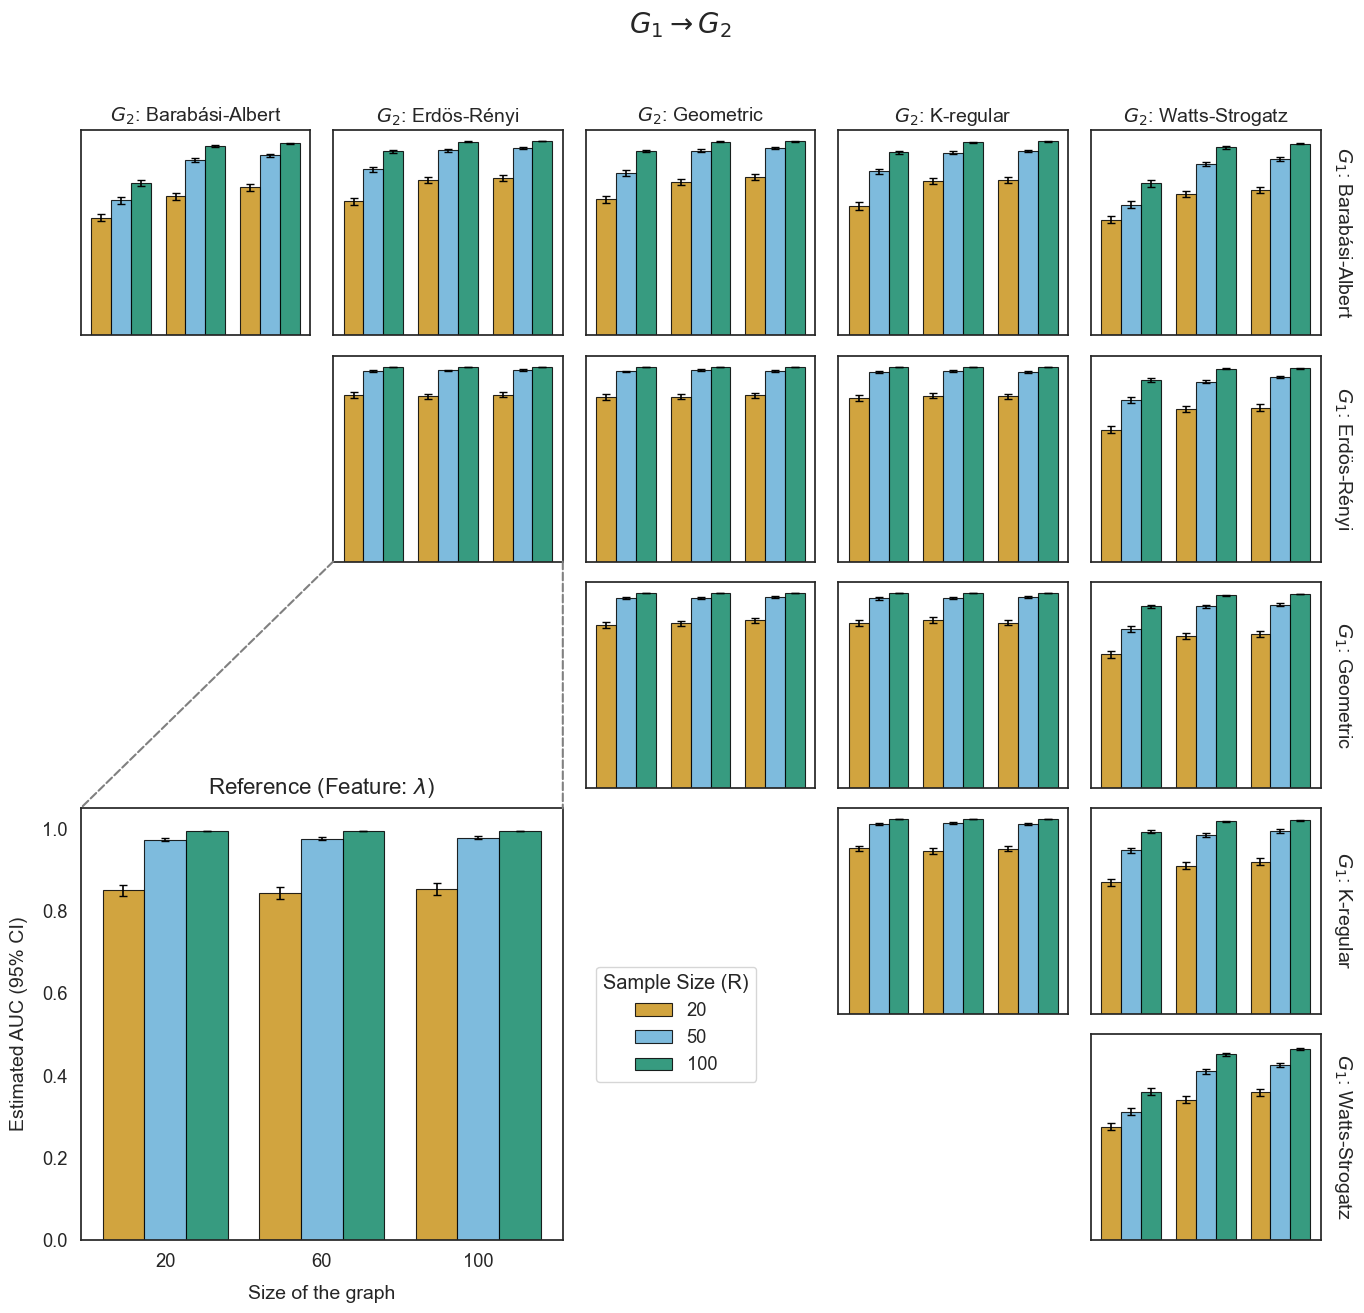

Gráfico salvo com sucesso em: ..\dados\resultados\sim\Caso_2\auc_R_lambda_uniform_rank.pdf


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
from cycler import cycler
from matplotlib.patches import ConnectionPatch

minha_paleta = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
plt.rcParams['axes.prop_cycle'] = cycler(color=minha_paleta)
sns.set_theme(style="white", font_scale=1.2)
sns.set_palette(minha_paleta)

def calcular_area_poder(p_valores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    poderes = np.array([np.mean(p_valores <= t) for t in thresholds])
    return auc(thresholds, poderes)

def bootstrap_power_area(p_valores, n_bootstraps=1000, alpha_ic=0.05):
    p_valores = np.array(p_valores)
    n_amostras = len(p_valores)
    
    estimativa_real = calcular_area_poder(p_valores)
    
    areas_bootstrap = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        amostra_p = rng.choice(p_valores, size=n_amostras, replace=True)
        areas_bootstrap.append(calcular_area_poder(amostra_p))
        
    areas_bootstrap = np.array(areas_bootstrap)
    areas_bootstrap.sort()
    
    lower_bound = np.percentile(areas_bootstrap, (alpha_ic / 2) * 100)
    upper_bound = np.percentile(areas_bootstrap, (1 - alpha_ic / 2) * 100)
    
    return estimativa_real, lower_bound, upper_bound

# ==========================================
# 1. TRATAMENTO DO DATAFRAME EM MEMÓRIA
# ==========================================
# Faz uma cópia de segurança renomeando as colunas
caso = "Caso_2"
ruido = "uniform"

# Caminho para o dataframe único
path = os.path.join("..", "dados", "resultados", "sim", caso, "p_valores_rank.csv") 
df_full = pd.read_csv(path)

df_tratado = df_full.rename(columns={
    'Vertices': 'N',
    'Direcao': 'Direction',
    'p_valor': 'p_value'
}).copy()

# Filtra APENAS a feature de raio espectral (lambda)
features_espectrais = ['Lambda', 'lambda', r'$\lambda$', r'$\lambda_1$']
df_tratado = df_tratado[df_tratado['Feature'].isin(features_espectrais)].copy()

# Separa a coluna 'Modelo' em G1 e G2
df_tratado[['Model_G1', 'Model_G2']] = df_tratado['Modelo'].apply(
    lambda x: pd.Series(x.split('-') if '-' in str(x) else [x, x])
)

modelos_quero = ["barabasi_albert", "erdos_renyi", "geometric", "k_regular", "watts_strogatz"]
df_tratado = df_tratado[
    df_tratado["Model_G1"].isin(modelos_quero) & 
    df_tratado["Model_G2"].isin(modelos_quero)
].reset_index(drop=True)

mapa_topologia = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_direcao = {
    'A->B': r'$G_1 \rightarrow G_2$',
    'B->A': r'$G_2 \rightarrow G_1$',
    'A->C': r'$G_1 \rightarrow G_3$',
    'B->C': r'$G_2 \rightarrow G_3$'
}

df_tratado['Model_G1'] = df_tratado['Model_G1'].map(mapa_topologia).fillna(df_tratado['Model_G1'])
df_tratado['Model_G2'] = df_tratado['Model_G2'].map(mapa_topologia).fillna(df_tratado['Model_G2'])
df_tratado['Direction_Raw'] = df_tratado['Direction']
df_tratado['Direction'] = df_tratado['Direction'].map(mapa_direcao).fillna(df_tratado['Direction'])

df_tratado['N'] = df_tratado['N'].astype(int)
df_tratado['R'] = df_tratado['R'].astype(int)

# ==========================================
# 2. PROCESSAMENTO VIA BOOTSTRAP
# ==========================================
final_results = []
print("Calculating Estimations and CI for all scenarios. This might take a few seconds...")

# Agrupando agora por N e R
for (mod1, mod2, n_nodes, r_samples, direction, dir_raw), group in df_tratado.groupby(['Model_G1', 'Model_G2', 'N', 'R', 'Direction', 'Direction_Raw']):
    p_vals = pd.to_numeric(group['p_value'], errors='coerce').dropna().values
    
    if len(p_vals) == 0:
        continue
        
    estimativa, lower, upper = bootstrap_power_area(p_vals, n_bootstraps=1000)
    
    final_results.append({
        'Model_G1': mod1, 'Model_G2': mod2, 'N': n_nodes, 'R': r_samples,
        'Direction': direction, 'Direction_Raw': dir_raw,
        'Area_Estimate': estimativa, 
        'Err_Lower': estimativa - lower, 
        'Err_Upper': upper - estimativa
    })

df_plot = pd.DataFrame(final_results)
df_plot = df_plot.sort_values(by=['Model_G1', 'Model_G2', 'Direction', 'N', 'R'])

# ==========================================
# 3. PLOTAGEM MATRICIAL (R NO EIXO HUE)
# ==========================================
print("Generating Matrix Plot with strict numerical positioning...")
path_figuras = os.path.join("..", "dados", "resultados", "sim", caso)
os.makedirs(path_figuras, exist_ok=True)

global_order_x = sorted(df_plot['N'].unique())
global_order_hue = sorted(df_plot['R'].unique())

def plot_bars_manual(ax, data, x, y, err_inf, err_sup, hue, hue_order, legend=False):
    if data.empty:
        return
        
    sns.barplot(
        x=x, y=y, hue=hue, data=data, 
        ax=ax, alpha=0.85, 
        order=global_order_x, hue_order=hue_order,
        palette=minha_paleta, edgecolor='black', linewidth=0.8
    )
    
    if not legend and ax.legend_ is not None:
        ax.legend_.remove()
    elif legend:
        sns.move_legend(ax, "center left", bbox_to_anchor=(1.05, 0.5), title="Sample Size (R)", frameon=True)
        
    x_coords, y_coords, y_errs_inf, y_errs_sup = [], [], [], []
    
    # Cálculo matemático para encontrar a coordenada exata de cada erro
    H = len(hue_order)
    w = 0.8 / H
    
    for h_idx, r_val in enumerate(hue_order):
        offset = -0.4 + (w / 2.0) + (h_idx * w)
        
        for x_idx, x_val in enumerate(global_order_x):
            exact_x = x_idx + offset
            
            subset = data[(data[hue] == r_val) & (data[x] == x_val)]
            if not subset.empty:
                y_val = subset[y].values[0]
                if pd.notnull(y_val):
                    x_coords.append(exact_x)
                    y_coords.append(y_val)
                    y_errs_inf.append(subset[err_inf].values[0])
                    y_errs_sup.append(subset[err_sup].values[0])

    if x_coords:
        ax.errorbar(
            x=x_coords, 
            y=y_coords, 
            yerr=[y_errs_inf, y_errs_sup], 
            fmt='none', c='black', capsize=3, linewidth=1.2
        )

modelos_labels = [mapa_topologia[m] for m in modelos_quero] 

for dir_raw in df_plot['Direction_Raw'].unique():
    df_dir_plot = df_plot[df_plot['Direction_Raw'] == dir_raw]
    titulo_dir = df_dir_plot['Direction'].iloc[0]
    
    num_modelos = len(modelos_labels)
    fig = plt.figure(figsize=(num_modelos * 3.2, num_modelos * 3))
    gs = fig.add_gridspec(num_modelos, num_modelos)
    axes_matrix = {}
    
    for i, mod1 in enumerate(modelos_labels):
        for j, mod2 in enumerate(modelos_labels):
            
            # Desenha apenas o triângulo superior da matriz
            if i > j:
                continue
                
            ax = fig.add_subplot(gs[i, j])
            axes_matrix[(i, j)] = ax
            
            subset = df_dir_plot[(df_dir_plot['Model_G1'] == mod1) & (df_dir_plot['Model_G2'] == mod2)]
            
            if subset.empty:
                ax.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax.transAxes, color='grey')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
                
            plot_bars_manual(ax, subset, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "R", global_order_hue, legend=False)
            
            ax.set_ylim(0, 1.05)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_xticks([]) # Limpa os números da grade interior
            ax.set_yticks([])
            
            if i == 0:
                ax.set_title(fr"$G_2$: {mod2}", fontsize=14)
            if j == num_modelos - 1:
                ax.text(1.05, 0.5, fr"$G_1$: {mod1}", rotation=270, va='center', ha='left', transform=ax.transAxes, fontsize=14)

    # ==========================================
    # 4. CRIAÇÃO DO ZOOM NO VÃO INFERIOR
    # ==========================================
    # Seleciona preferencialmente a célula (1,1) para a referência
    zoom_i, zoom_j = (1, 1) if num_modelos > 1 else (0, 0)
    mod_zoom_1, mod_zoom_2 = modelos_labels[zoom_i], modelos_labels[zoom_j]
    subset_ref = df_dir_plot[(df_dir_plot['Model_G1'] == mod_zoom_1) & (df_dir_plot['Model_G2'] == mod_zoom_2)]
    
    if num_modelos >= 4:
        ax_ref = fig.add_subplot(gs[num_modelos-2:num_modelos, 0:2])
    else:
        ax_ref = fig.add_subplot(gs[-1, 0])
        
    plot_bars_manual(ax_ref, subset_ref, "N", "Area_Estimate", "Err_Lower", "Err_Upper", "R", global_order_hue, legend=True)
    
    ax_ref.set_ylim(0, 1.05)
    ax_ref.set_xlabel("Size of the graph", fontsize=14, labelpad=10)
    ax_ref.set_ylabel("Estimated AUC (95% CI)", fontsize=14, labelpad=10)
    ax_ref.set_title(fr"Reference (Feature: $\lambda$)", fontsize=16, pad=10)
    
    if (zoom_i, zoom_j) in axes_matrix:
        ax_src = axes_matrix[(zoom_i, zoom_j)]
        
        con1 = ConnectionPatch(xyA=(0, 0), xyB=(0, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con1.set_clip_on(False)
        
        con2 = ConnectionPatch(xyA=(1, 0), xyB=(1, 1), coordsA="axes fraction", coordsB="axes fraction",
                               axesA=ax_src, axesB=ax_ref, color="gray", linestyle="--", linewidth=1.5, zorder=100)
        con2.set_clip_on(False)
        
        fig.add_artist(con1)
        fig.add_artist(con2)
    
    fig.suptitle(titulo_dir, fontsize=20, y=0.93)
        
    plt.subplots_adjust(top=0.85, hspace=0.1, wspace=0.1) 
    plt.show()

    nome_arquivo = f"auc_R_lambda_{ruido}_rank.pdf"
    fig.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
    print(f"Gráfico salvo com sucesso em: {os.path.join(path_figuras, nome_arquivo)}")

#### Caso 3

Calculating Estimations and CI for all scenarios. This might take a few seconds...
Generating FacetGrid plot...


C:\Users\caios\AppData\Local\Temp\ipykernel_44756\1709639500.py:134: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\1709639500.py:134: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\1709639500.py:134: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\1709639500.py:134: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\1709639500.py:134: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\caios\AppData\Local\Temp\ipykernel_44756\1709639500.py:134: UserWarning: The palette list has more va

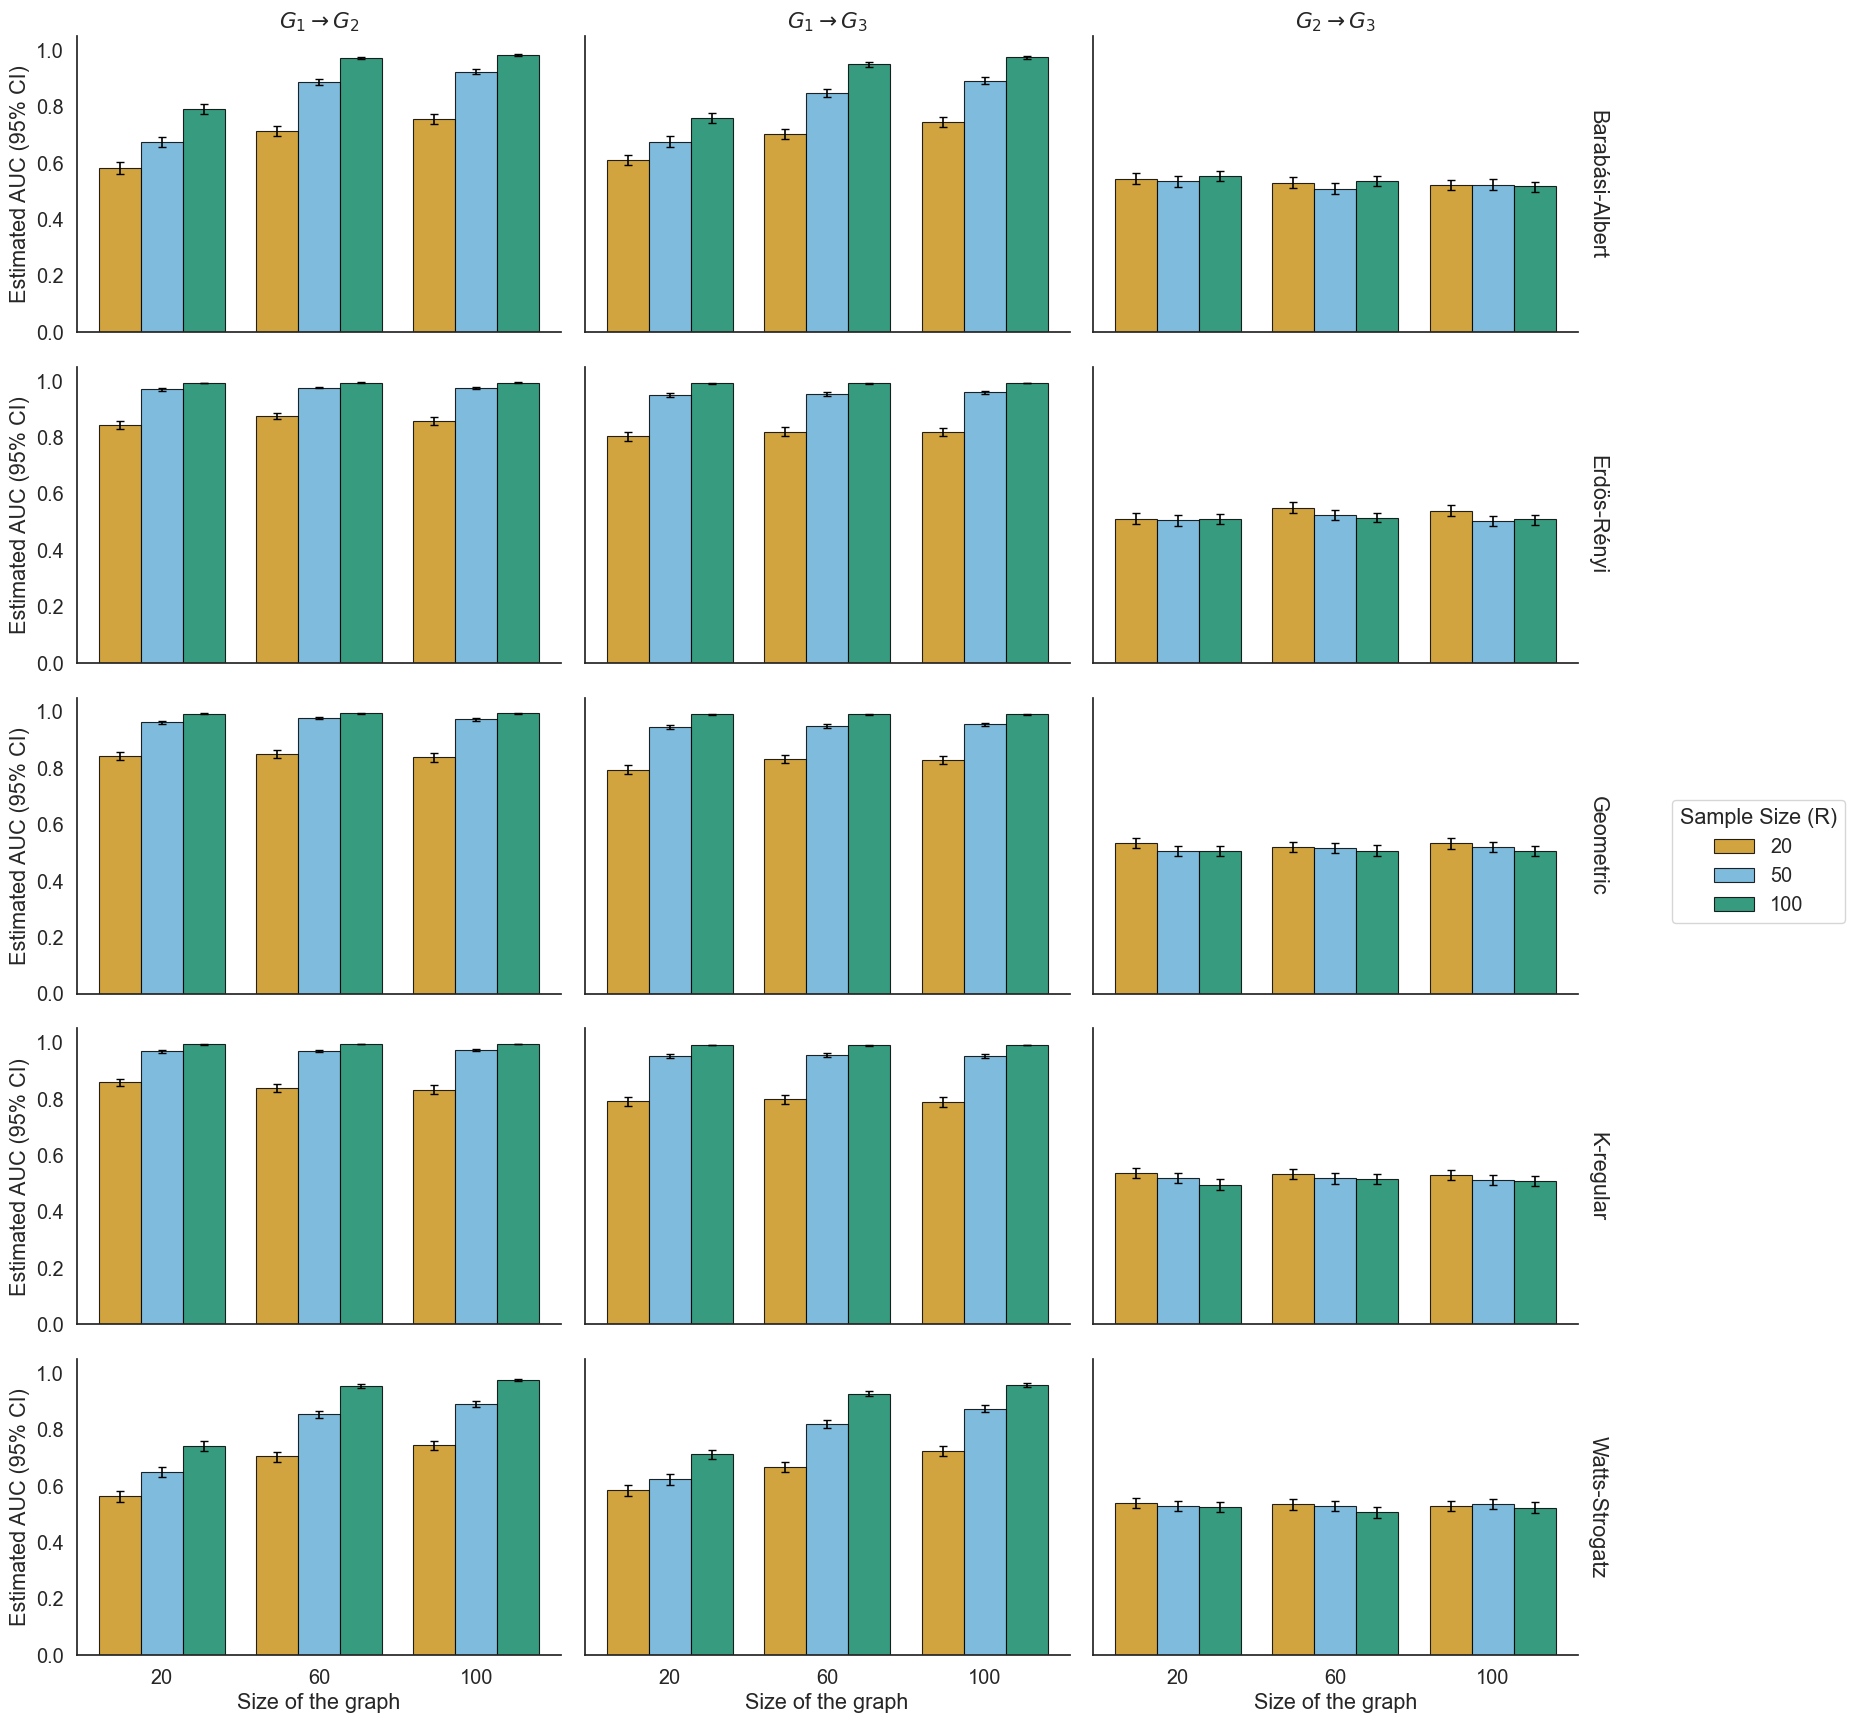

Gráfico salvo com sucesso em: ..\dados\resultados\sim\Caso_3\auc_R_lambda_uniform_rank.pdf


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
from cycler import cycler

minha_paleta = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
plt.rcParams['axes.prop_cycle'] = cycler(color=minha_paleta)
sns.set_theme(style="white", font_scale=1.3)
sns.set_palette(minha_paleta)

def calcular_area_poder(p_valores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    poderes = np.array([np.mean(p_valores <= t) for t in thresholds])
    return auc(thresholds, poderes)

def bootstrap_power_area(p_valores, n_bootstraps=1000, alpha_ic=0.05):
    p_valores = np.array(p_valores)
    n_amostras = len(p_valores)
    
    estimativa_real = calcular_area_poder(p_valores)
    
    areas_bootstrap = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        amostra_p = rng.choice(p_valores, size=n_amostras, replace=True)
        areas_bootstrap.append(calcular_area_poder(amostra_p))
        
    areas_bootstrap = np.array(areas_bootstrap)
    areas_bootstrap.sort()
    
    lower_bound = np.percentile(areas_bootstrap, (alpha_ic / 2) * 100)
    upper_bound = np.percentile(areas_bootstrap, (1 - alpha_ic / 2) * 100)
    
    return estimativa_real, lower_bound, upper_bound

# ==========================================
# 1. TRATAMENTO DO DATAFRAME EM MEMÓRIA
# ==========================================
# Faz uma cópia de segurança renomeando as colunas
caso = "Caso_3"
ruido = "uniform"

# Caminho para o dataframe único
path = os.path.join("..", "dados", "resultados", "sim", caso, "p_valores_rank.csv") 
df_full = pd.read_csv(path)

df_tratado = df_full.rename(columns={
    'Modelo': 'Topology',
    'Vertices': 'N',
    'Aresta': 'Direction',
    'p_valor': 'p_value'
}).copy()

# Filtra APENAS a feature de raio espectral (lambda)
features_espectrais = ['Lambda', 'lambda', r'$\lambda$', r'$\lambda_1$']
df_tratado = df_tratado[df_tratado['Feature'].isin(features_espectrais)].copy()

modelos_quero = ["barabasi_albert", "erdos_renyi", "geometric", "k_regular", "watts_strogatz"]
df_tratado = df_tratado[df_tratado["Topology"].isin(modelos_quero)].reset_index(drop=True)

mapa_topologia = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_direcao = {
    'A->B': r'$G_1 \rightarrow G_2$',
    'A->C': r'$G_1 \rightarrow G_3$',
    'B->C': r'$G_2 \rightarrow G_3$'
}

df_tratado['Topology'] = df_tratado['Topology'].map(mapa_topologia).fillna(df_tratado['Topology'])
df_tratado['Direction_Raw'] = df_tratado['Direction']
df_tratado['Direction'] = df_tratado['Direction'].map(mapa_direcao).fillna(df_tratado['Direction'])

df_tratado['N'] = df_tratado['N'].astype(int)
df_tratado['R'] = df_tratado['R'].astype(int)

# ==========================================
# 2. PROCESSAMENTO VIA BOOTSTRAP
# ==========================================
final_results = []
print("Calculating Estimations and CI for all scenarios. This might take a few seconds...")

# Agrupando por Topologia, N, R e Direção
for (topology, n_nodes, r_samples, direction, dir_raw), group in df_tratado.groupby(['Topology', 'N', 'R', 'Direction', 'Direction_Raw']):
    p_vals = pd.to_numeric(group['p_value'], errors='coerce').dropna().values
    
    if len(p_vals) == 0:
        continue
        
    estimativa, lower, upper = bootstrap_power_area(p_vals, n_bootstraps=1000)
    
    final_results.append({
        'Topology': topology, 'N': n_nodes, 'R': r_samples,
        'Direction': direction, 'Direction_Raw': dir_raw,
        'Area_Estimate': estimativa, 
        'Err_Lower': estimativa - lower, 
        'Err_Upper': upper - estimativa
    })

df_plot = pd.DataFrame(final_results)

# ==========================================
# 3. ORDENAÇÃO E PLOTAGEM
# ==========================================
# Garantindo que as direções apareçam na ordem lógica da cadeia causal
ordem_direcoes = [r'$G_1 \rightarrow G_2$', r'$G_1 \rightarrow G_3$', r'$G_2 \rightarrow G_3$']
ordem_direcoes_presentes = [d for d in ordem_direcoes if d in df_plot['Direction'].values]

df_plot['Direction'] = pd.Categorical(df_plot['Direction'], categories=ordem_direcoes_presentes, ordered=True)
df_plot = df_plot.sort_values(by=['Topology', 'Direction', 'N', 'R'])

# Definição estrita das categorias globais
global_order_x = sorted(df_plot['N'].unique())
global_order_hue = sorted(df_plot['R'].unique())

print("Generating FacetGrid plot...")

g = sns.FacetGrid(df_plot, row="Topology", col="Direction", margin_titles=True, height=3.5, aspect=1.4)
g.set_titles(col_template="{col_name}", row_template="{row_name}")

def plot_bars_with_ic(x, y, err_inf, err_sup, hue, **kwargs):
    ax = plt.gca()
    data = kwargs.pop("data")
    
    sns.barplot(
        x=x, y=y, hue=hue, data=data, 
        ax=ax, alpha=0.85, 
        hue_order=global_order_hue, 
        order=global_order_x, 
        edgecolor='black', linewidth=0.8,
        **kwargs
    )
    
    x_coords, y_coords, y_errs_inf, y_errs_sup = [], [], [], []
    
    # Cálculo matemático para posicionar a barra de erro
    H = len(global_order_hue)
    w = 0.8 / H
    
    for h_idx, r_val in enumerate(global_order_hue):
        offset = -0.4 + (w / 2.0) + (h_idx * w)
        
        for x_idx, x_val in enumerate(global_order_x):
            exact_x = x_idx + offset
            subset = data[(data[hue] == r_val) & (data[x] == x_val)]
            
            if not subset.empty:
                y_val = subset[y].values[0]
                if pd.notnull(y_val):
                    x_coords.append(exact_x)
                    y_coords.append(y_val)
                    y_errs_inf.append(subset[err_inf].values[0])
                    y_errs_sup.append(subset[err_sup].values[0])
                    
    if x_coords:
        ax.errorbar(
            x=x_coords, 
            y=y_coords, 
            yerr=[y_errs_inf, y_errs_sup], 
            fmt='none', 
            c='black', 
            capsize=3, 
            linewidth=1.2
        )

# Mapeia os dados usando o R como hue
g.map_dataframe(plot_bars_with_ic, x="N", y="Area_Estimate", err_inf="Err_Lower", err_sup="Err_Upper", hue="R", palette=minha_paleta)

g.set_axis_labels("Size of the graph", "Estimated AUC (95% CI)")

# Legenda fora do grid principal
g.add_legend(title="Sample Size (R)", bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=True)

for ax in g.axes.flat:
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ==========================================
# 4. SALVAR ARQUIVO PDF
# ==========================================
nome_arquivo = f"auc_R_lambda_{ruido}_rank.pdf"
path_figuras = os.path.join("..", "dados", "resultados", "sim", caso)
os.makedirs(path_figuras, exist_ok=True)
g.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')

print(f"Gráfico salvo com sucesso em: {os.path.join(path_figuras, nome_arquivo)}")